# Example notebook for optimize module

In the following we exemplify how to utilize the optimize module of pyMOE which uses gradient descent methods for inverse design of masks. Some metrics are introduced which can be used for loss function constructions. 

Documentation will be updated in future release 

In [1]:
# Notebook display options, change as your preference/system
%matplotlib inline
%config InlineBackend.print_figure_kwargs={'facecolor' : "w",'bbox_inches':None}

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 120


import sys
sys.path.insert(0,'..')
sys.path.insert(0,'../..')

from matplotlib import pyplot as plt 
import numpy as np 

from scipy.constants import micro, nano, milli

import pyMOE as moe 
from pyMOE.generate import *  
from pyMOE.propagate import * 
from pyMOE.metrics import * 
from pyMOE.optimizer import * 
from pyMOE.ensemble import * 

In [2]:
# Notebook display options, change as your preference/system
%matplotlib inline
%config InlineBackend.print_figure_kwargs={'facecolor' : "w",'bbox_inches':None}

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 120

In [3]:
import sys
sys.path.insert(0,'..')
sys.path.insert(0,'../..')

from matplotlib import pyplot as plt 
import numpy as np 

from scipy.constants import micro, nano, milli

import pyMOE as moe 
from pyMOE.generate import *  
from pyMOE.propagate import * 
from pyMOE.metrics import * 
from pyMOE.optimizer import * 


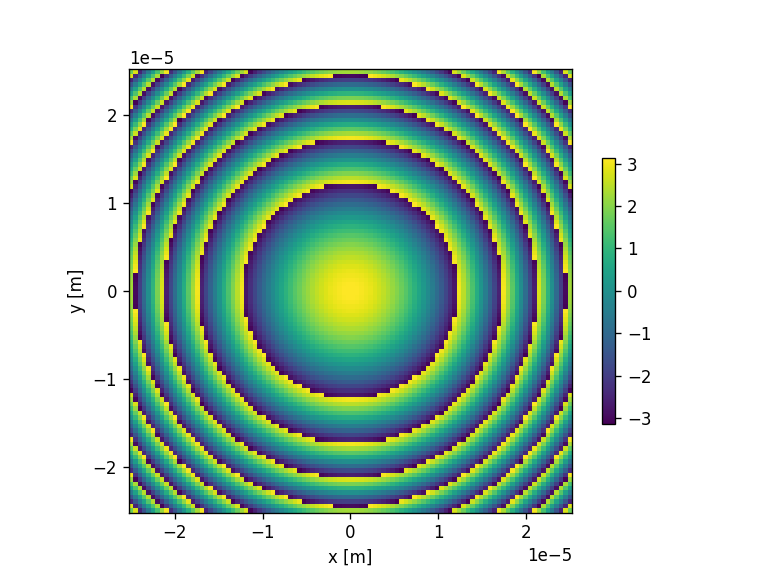

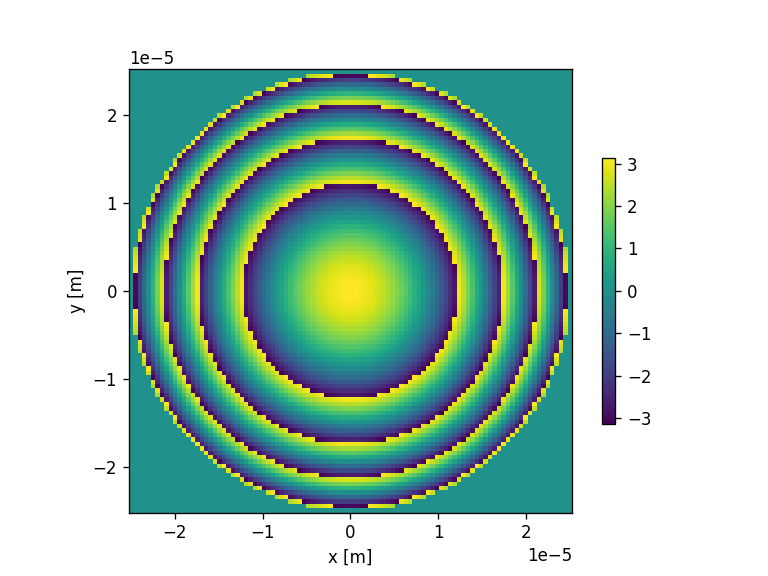

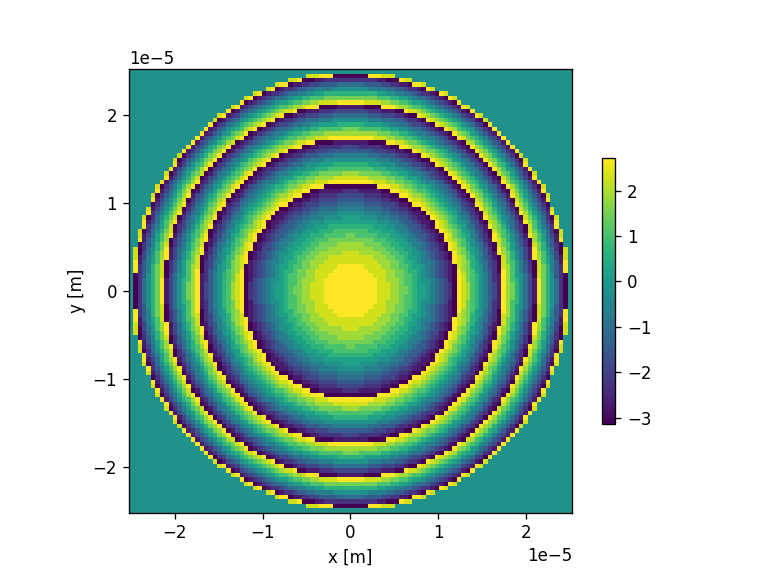

In [4]:
#number of pixels 
x_pixel = 100
y_pixel = 100

#size of the rectangular mask 
aperture_width  = 50e-6 #m
aperture_height = 50e-6

pixsize = 1e-6 #m

wavelength = 500e-9 #m
focal_length = 150e-6

zmin = wavelength
zmax = 1.2* focal_length
nzs = 500

radius = aperture_width/2 

# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask1 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

moe.plotting.plot_aperture(mask1)


##############
###Fresnel mask with a truncated circular aperture 

# Create empty mask
aperture2 = moe.generate.create_empty_aperture_from_aperture(aperture1)

# and truncate around radius
mask2 = moe.generate.fresnel_phase(aperture2, focal_length, wavelength, radius=radius)
moe.plotting.plot_aperture(mask2)

# Discretize mask in number of levels
# Select exact position of contours  in phase
phase_vals = np.linspace(-np.pi, np.pi, 16)

mask2.discretize(np.array( phase_vals)[:] ) 
moe.plotting.plot_aperture(mask2)

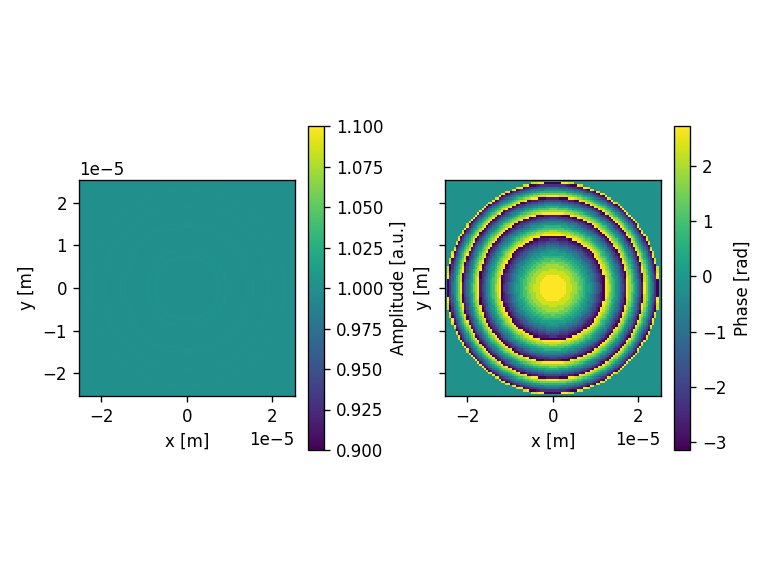

In [5]:
# Generate a uniform field
field = moe.field.create_empty_field_from_aperture(mask2)

field = moe.field.generate_uniform_field(field, E0=1)

# Modulates the field 
field = moe.field.modulate_field(field, amplitude_mask=None, phase_mask=mask2 )

# Plots the field (amplitude and phase)
moe.plotting.plot_field(field)

plt.tight_layout()
plt.show()


In [6]:
#Initial guess
x_pixel, y_pixel = 100, 100


x0 = np.random.rand(x_pixel, y_pixel) 
x0_flatten = x0.flatten()


xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
 

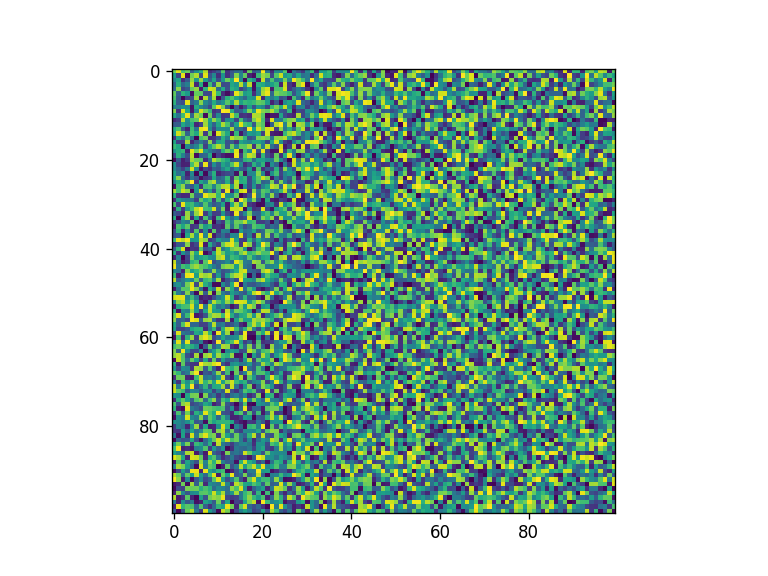

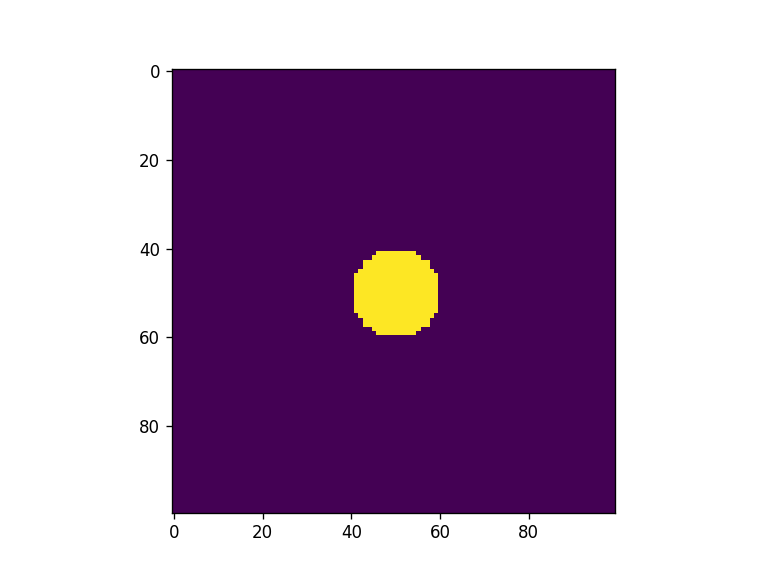

In [7]:
#create target     
matrix = np.zeros((x_pixel, y_pixel))
matrix[np.where(((XX-x_pixel/2)**2 + (YY-y_pixel/2)**2) < 10**2)] = 1 

matrix_flat = matrix.flatten()

fig = plt.figure() 
plt.imshow(x0)


fig = plt.figure() 
plt.imshow(matrix)

In [8]:
#Define Screen 

# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)

Elapsed: 0:00:01.784772


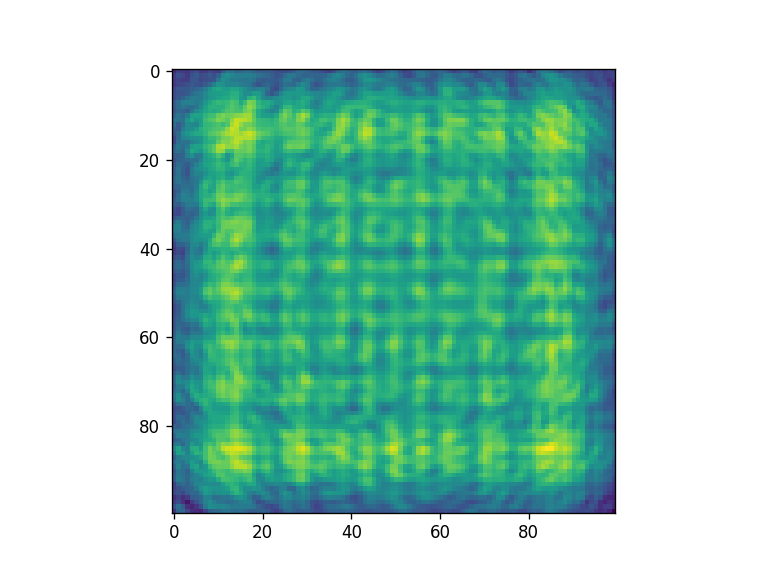

In [9]:
##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength ))

fig = plt.figure() 
plt.imshow(np.abs(prop))

In [10]:
#Define loss functions 

def FOM(x, mask, screen, wavelength, mat=matrix_flat):
    import jax.numpy as np 
    
    prop_x = np.abs(moe.optimizer.propagate(np.reshape(x, (x_pixel, y_pixel)), mask, screen, wavelength).flatten())
    res = np.log(np.sum(((prop_x/np.max(prop_x)-mat/np.max(mat))**2)))
    #print(res)
    return res



def FOM2(x, mask, screen, wavelength, mat=matrix_flat): 
    import jax.numpy as np 
    
    prop_x = np.abs(moe.optimizer.propagate(np.reshape(x, (x_pixel, y_pixel)), mask, screen, wavelength).flatten())
    prop_x = np.reshape(prop_x, (x_pixel, y_pixel))
    midx, midy = int(x_pixel/2), int(y_pixel/2)
    mat = np.reshape(mat, (x_pixel, y_pixel))
    
    res = np.log(np.sum(((prop_x/np.max(prop_x)/(prop_x[(midx,midy)]/np.max(prop_x)) - mat/np.max(mat))**2)))
    
    #print(res, prop_x[(midx,midy)])#(prop_x[midx]/np.max(prop_x)-mat[midy]/np.max(mat))**2)
    return res



def FOM3(x, mask, screen, wavelength, mat): 
    import jax.numpy as np 
    
    prop_x =  np.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength))
    
    diff = np.abs(prop_x/np.max(prop_x) - mat/np.max(mat))**2
     
    print(diff.shape)
    res = np.sum(diff)
    #print(res)
    
    return res

def FOM_strehl(x, mask, screen, wavelength, mat): 

    import jax.numpy as np 
    
    diff = 1 - moe.metrics.strehl_ratio(np.abs(np.reshape(x, (len(screen.x), len(screen.y))))**2, screen, \
                                        np.max(screen.x) - np.min(screen.x), wavelength, z = screen.z[-1])

    return diff

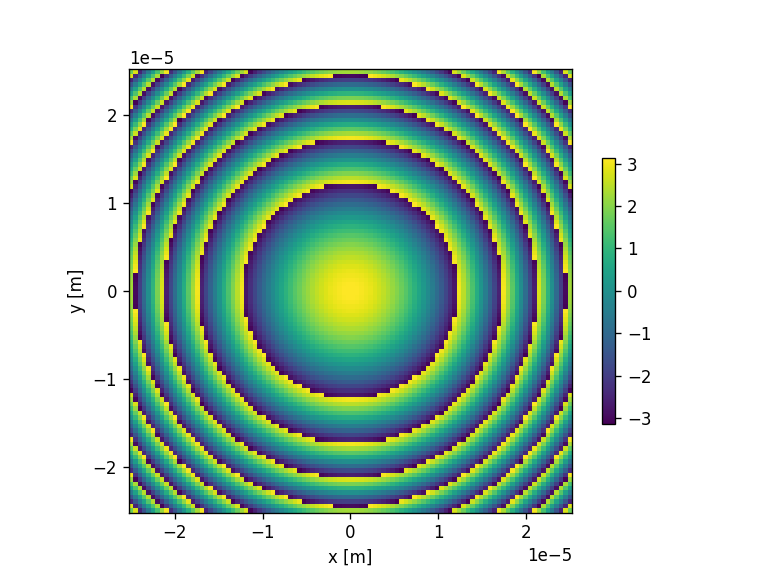

In [11]:
# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask2 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

moe.plotting.plot_aperture(mask2)

Elapsed: 0:00:00.026997


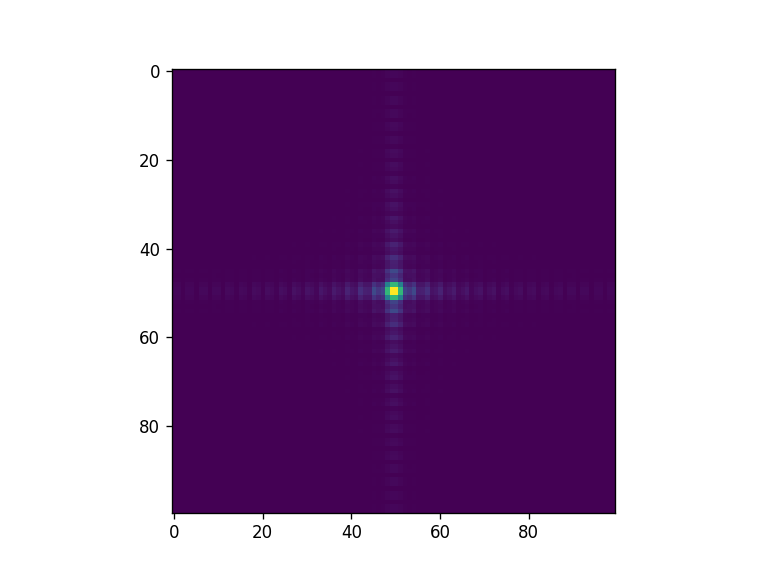

In [12]:
fig = plt.figure() 
plt.imshow(np.abs(np.array(propagate(mask2.aperture, mask2, screen, wavelength) ) ))

Elapsed: 0:00:00.020999
Elapsed: 0:00:00.577025
Elapsed: 0:00:00.025003
Elapsed: 0:00:00.046008
Elapsed: 0:00:00.013998
Elapsed: 0:00:00.085001
Elapsed: 0:00:00.018989
Elapsed: 0:00:00.058051
Elapsed: 0:00:00.015983
Elapsed: 0:00:00.055995
Elapsed: 0:00:00.017000
Elapsed: 0:00:00.042986
Elapsed: 0:00:00.015999
Elapsed: 0:00:00.019004
Elapsed: 0:00:00.052007
Elapsed: 0:00:00.031989
Elapsed: 0:00:00.046005
Elapsed: 0:00:00.033550
Elapsed: 0:00:00.029871
Elapsed: 0:00:00.080016
Elapsed: 0:00:00.027003
Elapsed: 0:00:00.056005
Elapsed: 0:00:00.025987
Elapsed: 0:00:00.065000
Elapsed: 0:00:00.020005
Elapsed: 0:00:00.055999
Elapsed: 0:00:00.022013
Elapsed: 0:00:00.057011
Elapsed: 0:00:00.027992
Elapsed: 0:00:00.053000
Elapsed: 0:00:00.019009
Elapsed: 0:00:00.071999
Elapsed: 0:00:00.020005
Elapsed: 0:00:00.017996
Elapsed: 0:00:00.077996
Elapsed: 0:00:00.019000
Elapsed: 0:00:00.044995
Elapsed: 0:00:00.029340
Elapsed: 0:00:00.059004
Elapsed: 0:00:00.018000
Elapsed: 0:00:00.063580
Elapsed: 0:00:00

Elapsed: 0:00:00.025022
Elapsed: 0:00:00.055001
Elapsed: 0:00:00.017997
Elapsed: 0:00:00.057008
Elapsed: 0:00:00.022000
Elapsed: 0:00:00.051007
Elapsed: 0:00:00.018523
Elapsed: 0:00:00.052997
Elapsed: 0:00:00.018000
Elapsed: 0:00:00.060005
Elapsed: 0:00:00.020995
Elapsed: 0:00:00.053000
Elapsed: 0:00:00.033077
Elapsed: 0:00:00.051004
Elapsed: 0:00:00.016000
Elapsed: 0:00:00.060005
Elapsed: 0:00:00.021999
Elapsed: 0:00:00.059997
Elapsed: 0:00:00.017006
Elapsed: 0:00:00.078999
Elapsed: 0:00:00.016989
Elapsed: 0:00:00.065010
Elapsed: 0:00:00.020001
Elapsed: 0:00:00.052006
Elapsed: 0:00:00.018989
Elapsed: 0:00:00.080540
Elapsed: 0:00:00.022990
Elapsed: 0:00:00.074999
Elapsed: 0:00:00.034004
Elapsed: 0:00:00.057821
Elapsed: 0:00:00.021285
Elapsed: 0:00:00.055980
Elapsed: 0:00:00.021007
Elapsed: 0:00:00.062006
Elapsed: 0:00:00.023970
Elapsed: 0:00:00.055990
Elapsed: 0:00:00.022005
Elapsed: 0:00:00.054749
Elapsed: 0:00:00.022011
Elapsed: 0:00:00.056017
Elapsed: 0:00:00.021999
Elapsed: 0:00:00

Elapsed: 0:00:00.033057
Elapsed: 0:00:00.091000
Elapsed: 0:00:00.031996
Elapsed: 0:00:00.082968
Elapsed: 0:00:00.029006
Elapsed: 0:00:00.064996
Elapsed: 0:00:00.018994
Elapsed: 0:00:00.066554
Elapsed: 0:00:00.023995
Elapsed: 0:00:00.065996
Elapsed: 0:00:00.019001
Elapsed: 0:00:00.052002
Elapsed: 0:00:00.019235
Elapsed: 0:00:00.074859
Elapsed: 0:00:00.026815
Elapsed: 0:00:00.065003
Elapsed: 0:00:00.026557
Elapsed: 0:00:00.078536
Elapsed: 0:00:00.027024
Elapsed: 0:00:00.059027
Elapsed: 0:00:00.030004
Elapsed: 0:00:00.080911
Elapsed: 0:00:00.026996
Elapsed: 0:00:00.073994
Elapsed: 0:00:00.026000
Elapsed: 0:00:00.063014
Elapsed: 0:00:00.024005
Elapsed: 0:00:00.074001
Elapsed: 0:00:00.024004
Elapsed: 0:00:00.062000
Elapsed: 0:00:00.030001
Elapsed: 0:00:00.078006
Elapsed: 0:00:00.025005
Elapsed: 0:00:00.051993
Elapsed: 0:00:00.024009
Elapsed: 0:00:00.054897
Elapsed: 0:00:00.031001
Elapsed: 0:00:00.046993
Elapsed: 0:00:00.030583
Elapsed: 0:00:00.067997
Elapsed: 0:00:00.025003
Elapsed: 0:00:00

Elapsed: 0:00:00.068008
Elapsed: 0:00:00.023992
Elapsed: 0:00:00.061004
Elapsed: 0:00:00.021997
Elapsed: 0:00:00.061000
Elapsed: 0:00:00.023999
Elapsed: 0:00:00.068159
Elapsed: 0:00:00.015558
Elapsed: 0:00:00.067004
Elapsed: 0:00:00.024988
Elapsed: 0:00:00.067545
Elapsed: 0:00:00.013997
Elapsed: 0:00:00.087090
Elapsed: 0:00:00.020010
Elapsed: 0:00:00.066993
Elapsed: 0:00:00.022815
Elapsed: 0:00:00.054008
Elapsed: 0:00:00.021015
Elapsed: 0:00:00.095014
Elapsed: 0:00:00.022987
Elapsed: 0:00:00.072531
Elapsed: 0:00:00.022999
Elapsed: 0:00:00.060007
Elapsed: 0:00:00.025004
Elapsed: 0:00:00.074794
Elapsed: 0:00:00.022994
Elapsed: 0:00:00.047011
Elapsed: 0:00:00.026003
Elapsed: 0:00:00.065533
Elapsed: 0:00:00.022992
Elapsed: 0:00:00.071002
Elapsed: 0:00:00.025008
Elapsed: 0:00:00.083111
Elapsed: 0:00:00.030994
Elapsed: 0:00:00.053001
Elapsed: 0:00:00.015012
Elapsed: 0:00:00.087006
Elapsed: 0:00:00.016999
Elapsed: 0:00:00.061000
Elapsed: 0:00:00.023561
Elapsed: 0:00:00.048998
Elapsed: 0:00:00

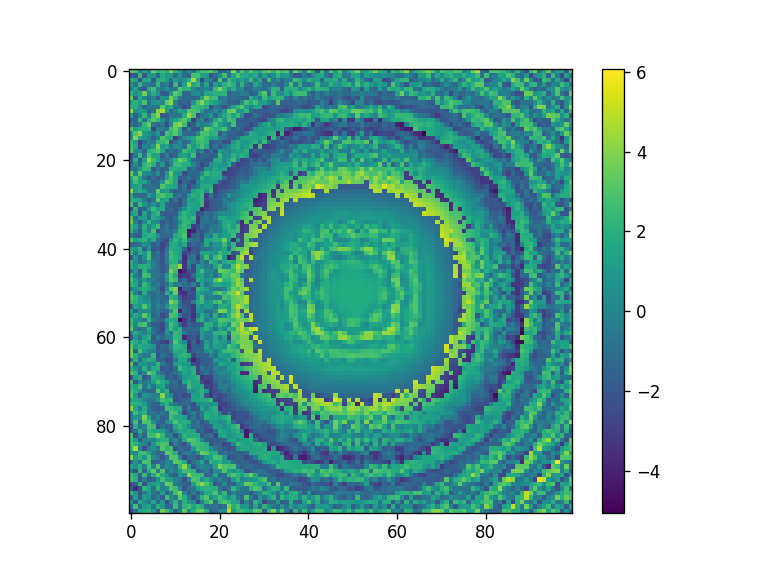

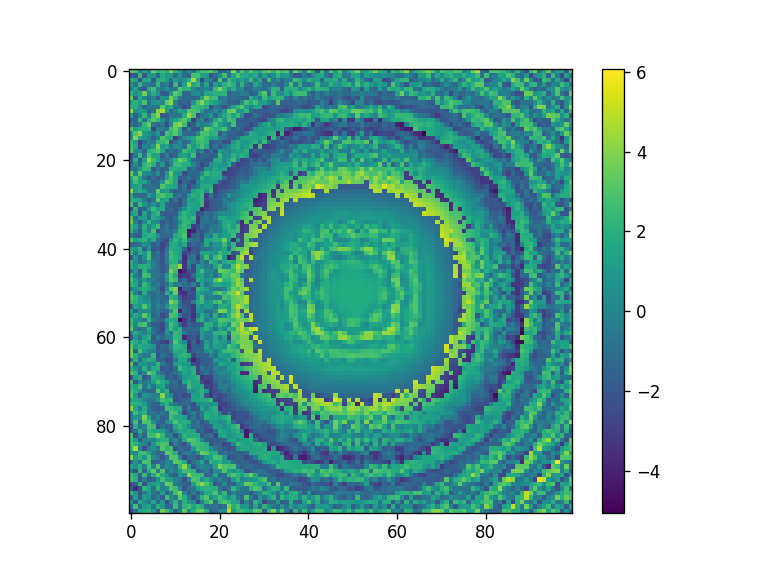

In [13]:
#optimize using the optimizer module 

solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=[mask2, screen, wavelength, matrix], verbose = 1, ftol=1e-4)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.024007
Elapsed: 0:00:00.021992


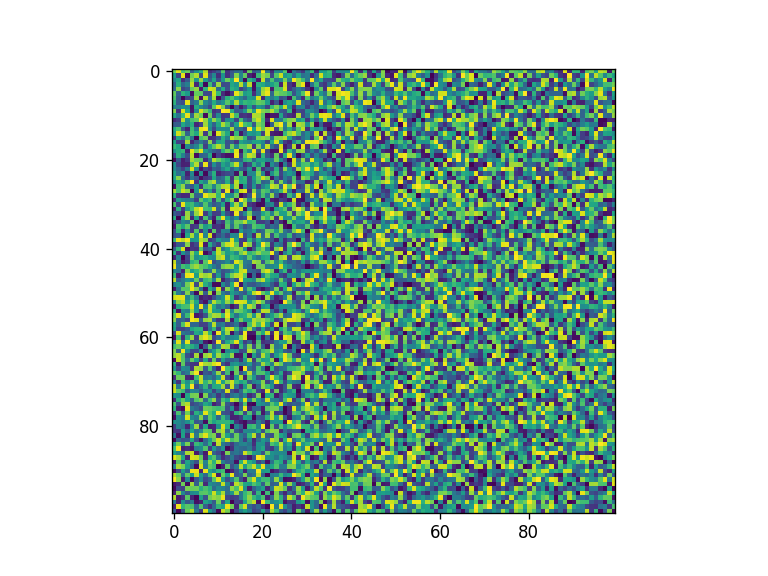

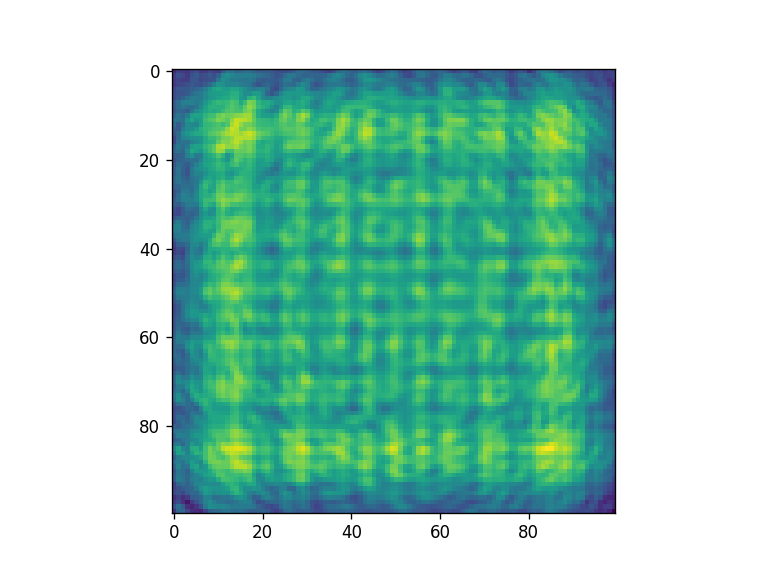

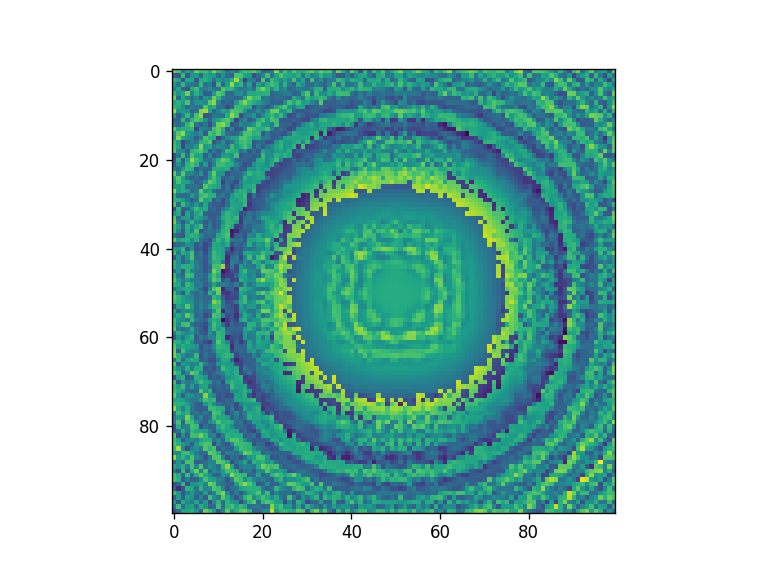

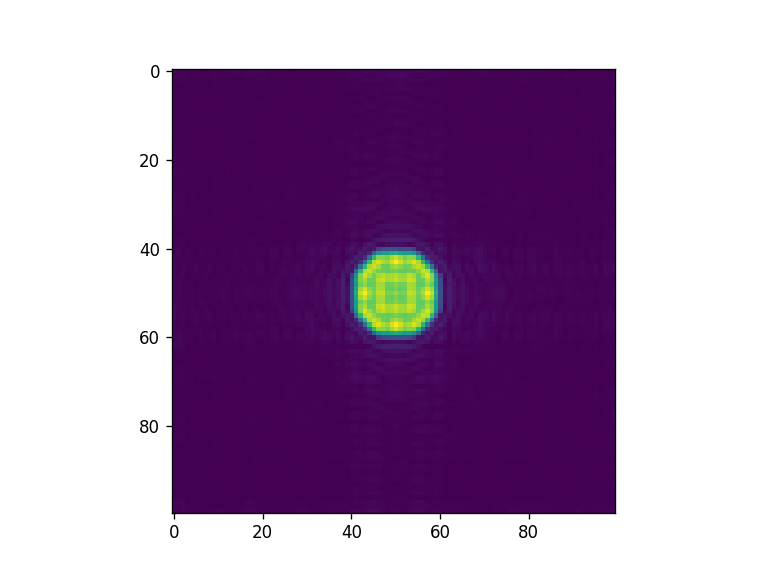

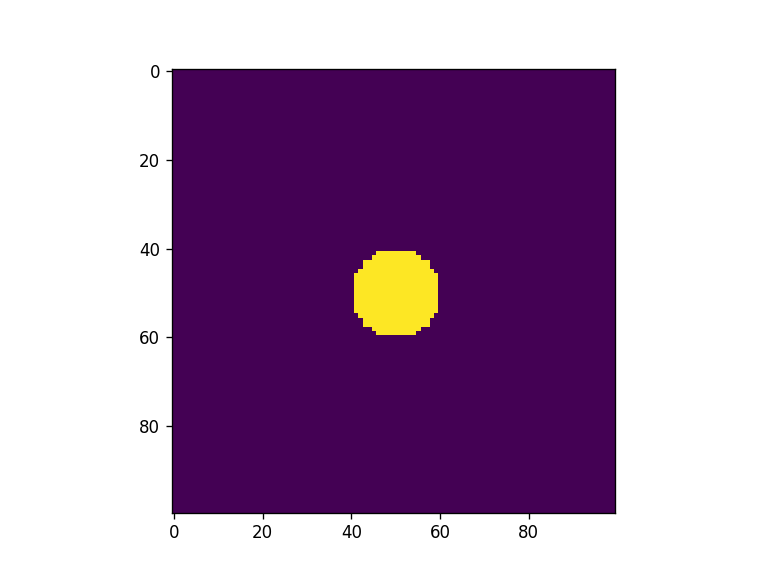

In [14]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength) ) )


fig = plt.figure() 
plt.imshow(np.reshape(matrix, (x_pixel, y_pixel)) )


In [15]:
def FOM3(x, mask, screen, wavelength, mat): 
    import jax.numpy as np 
    
    prop_x =  np.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength))
    
    diff = np.abs(prop_x/prop_x[int(len(screen.x)/2), int(len(screen.y)/2)] - mat/np.max(mat))**2
     
    print(diff.shape)
    res = np.log(np.sum(diff))
    #print(res)
    
    return res

solution = moe.optimizer.optimize(FOM, x0_flatten, args1=[mask2, screen, wavelength, matrix_flat], verbose = 1, ftol=1e-6)

Elapsed: 0:00:00.026996
Elapsed: 0:00:00.252182
Elapsed: 0:00:00.030019
Elapsed: 0:00:00.074001
Elapsed: 0:00:00.029992
Elapsed: 0:00:00.061736
Elapsed: 0:00:00.021996
Elapsed: 0:00:00.057650
Elapsed: 0:00:00.021695
Elapsed: 0:00:00.064992
Elapsed: 0:00:00.015000
Elapsed: 0:00:00.059139
Elapsed: 0:00:00.019011
Elapsed: 0:00:00.018996
Elapsed: 0:00:00.047986
Elapsed: 0:00:00.031004
Elapsed: 0:00:00.058006
Elapsed: 0:00:00.017002
Elapsed: 0:00:00.071993
Elapsed: 0:00:00.028219
Elapsed: 0:00:00.050008
Elapsed: 0:00:00.035005
Elapsed: 0:00:00.053672
Elapsed: 0:00:00.023762
Elapsed: 0:00:00.055020
Elapsed: 0:00:00.021002
Elapsed: 0:00:00.068572
Elapsed: 0:00:00.017042
Elapsed: 0:00:00.064809
Elapsed: 0:00:00.016002
Elapsed: 0:00:00.090079
Elapsed: 0:00:00.027261
Elapsed: 0:00:00.094018
Elapsed: 0:00:00.022639
Elapsed: 0:00:00.082140
Elapsed: 0:00:00.022000
Elapsed: 0:00:00.058722
Elapsed: 0:00:00.025998
Elapsed: 0:00:00.051692
Elapsed: 0:00:00.015000
Elapsed: 0:00:00.065263
Elapsed: 0:00:00

Elapsed: 0:00:00.087112
`ftol` termination condition is satisfied.
Function evaluations 172, initial cost 3.3874e+01, final cost 7.7298e+00, first-order optimality 4.98e-03.


Elapsed: 0:00:00.024994
Elapsed: 0:00:00.033992


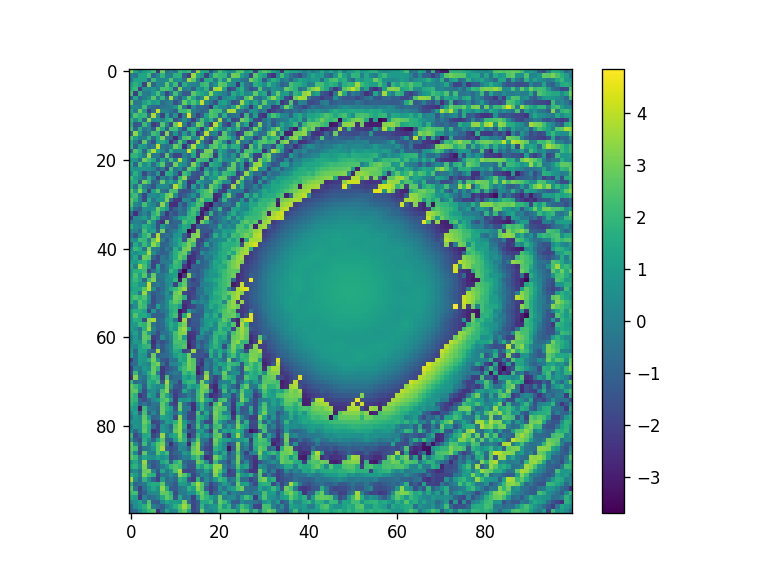

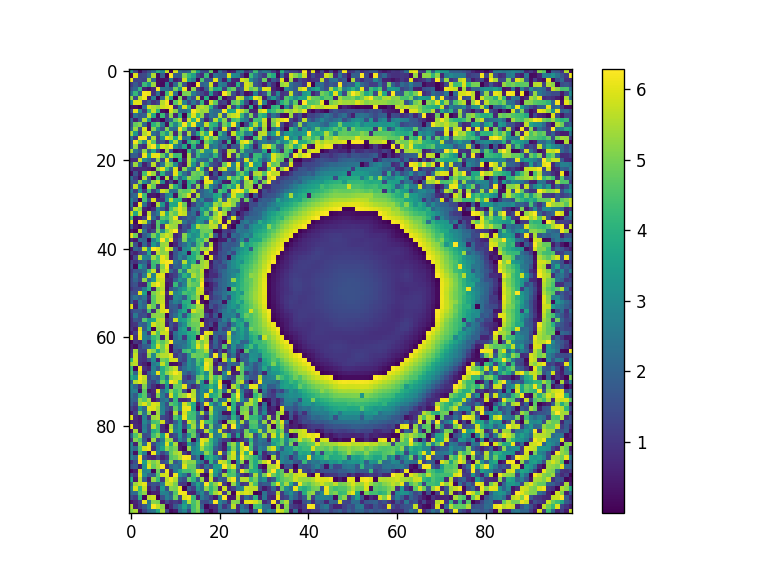

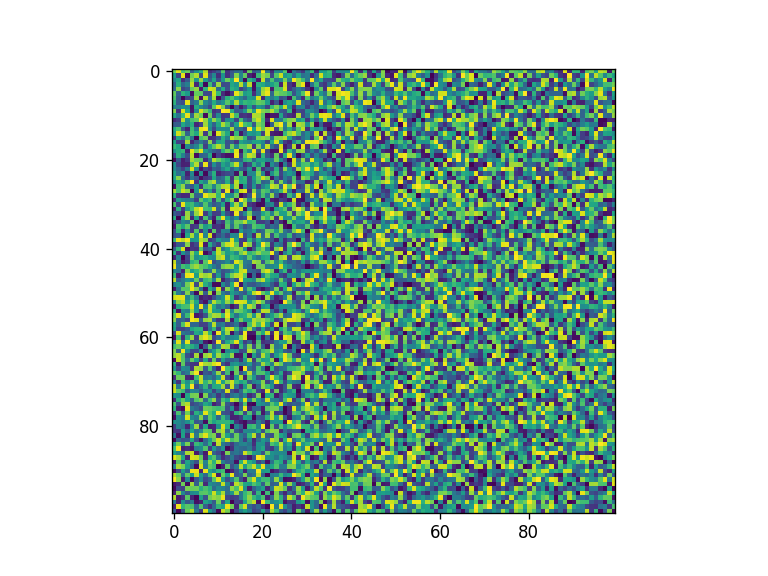

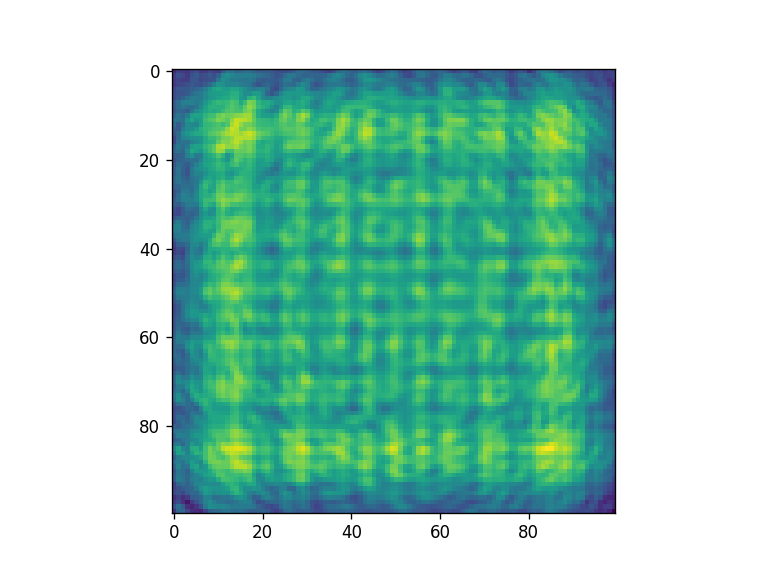

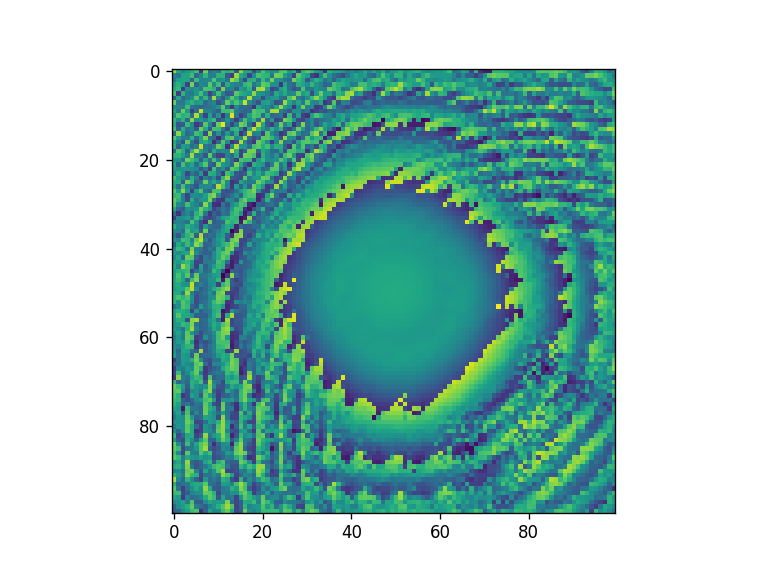

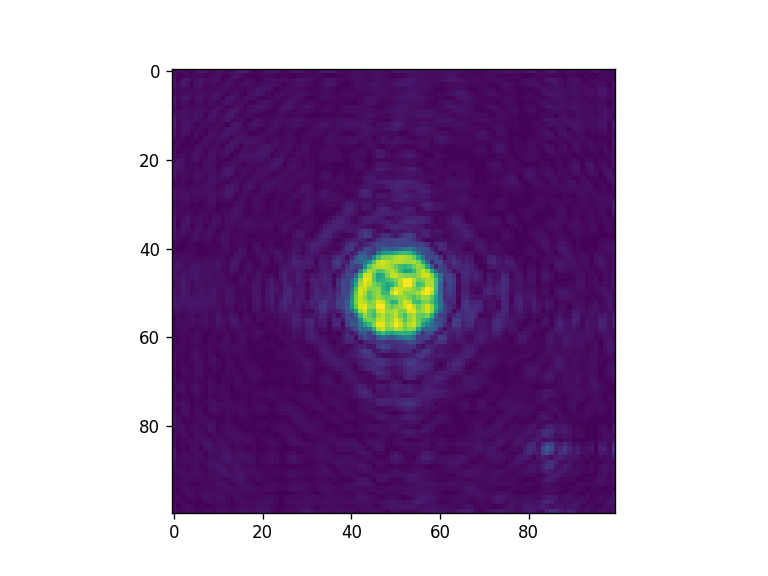

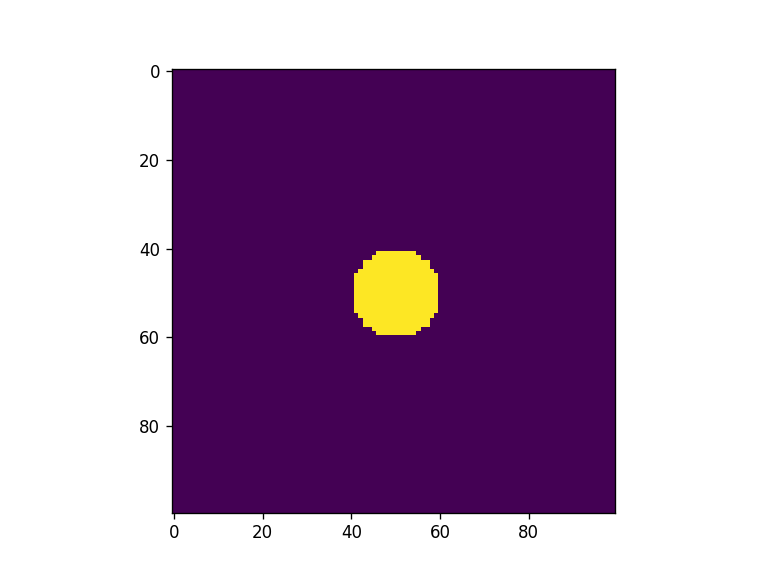

In [16]:
x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar%(2*np.pi)) 
plt.colorbar()

fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength) ) )


fig = plt.figure() 
plt.imshow(np.reshape(matrix, (x_pixel, y_pixel)) )


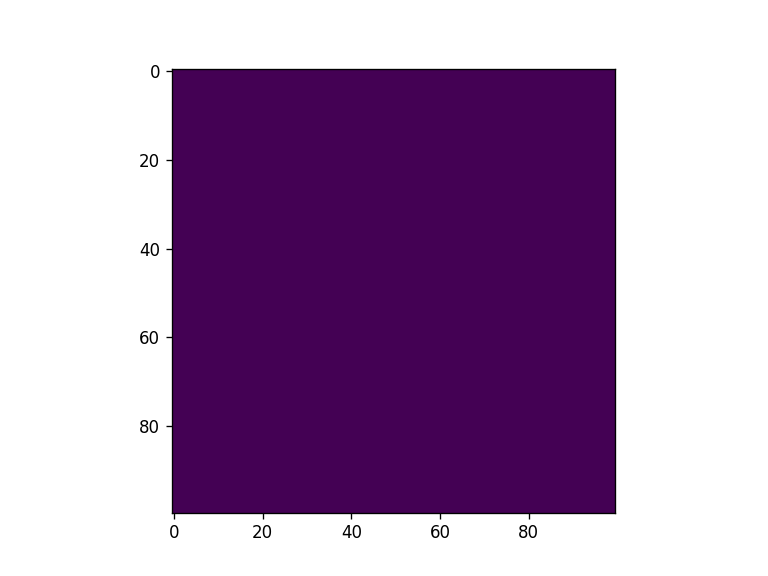

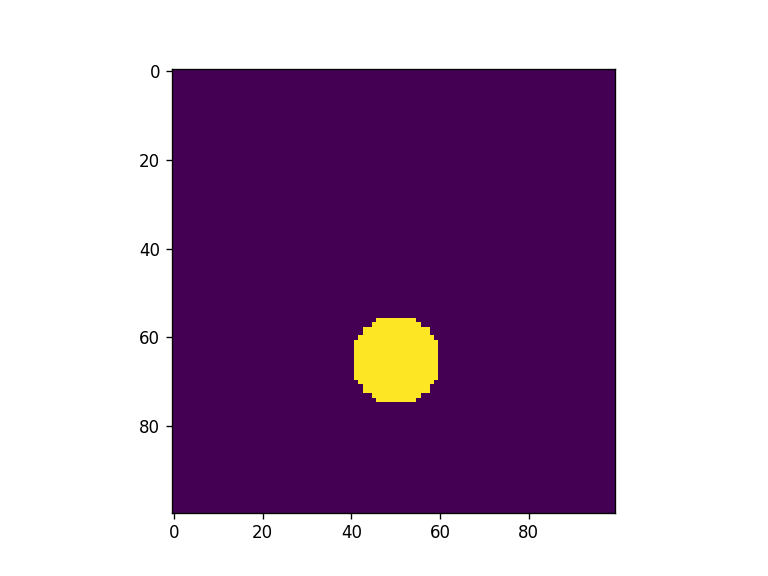

In [17]:
#Initial guess
x_pixel, y_pixel = 100, 100


x0 = np.random.rand(x_pixel, y_pixel)
x0 = np.ones((x_pixel, y_pixel))
x0_flatten = x0.flatten()


xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
    
matrix = np.zeros((x_pixel, y_pixel))
matrix[np.where(((XX-x_pixel/2- 0)**2 + (YY-y_pixel/2-15)**2) < 10**2)] = 1 

matrix_flat = matrix.flatten()

fig = plt.figure() 
plt.imshow(x0)


fig = plt.figure() 
plt.imshow(matrix)


Elapsed: 0:00:00.035388
(100, 100)
Elapsed: 0:00:00.057662
(100, 100)
Elapsed: 0:00:00.024001
(100, 100)
Elapsed: 0:00:00.072412
(100, 100)
Elapsed: 0:00:00.017996
(100, 100)
Elapsed: 0:00:00.072189
(100, 100)
Elapsed: 0:00:00.024993
(100, 100)
Elapsed: 0:00:00.062682
(100, 100)
Elapsed: 0:00:00.028003
(100, 100)
Elapsed: 0:00:00.062351
(100, 100)
Elapsed: 0:00:00.029987
(100, 100)
Elapsed: 0:00:00.016193
(100, 100)
Elapsed: 0:00:00.044983
(100, 100)
Elapsed: 0:00:00.015008
(100, 100)
Elapsed: 0:00:00.022999
(100, 100)
Elapsed: 0:00:00.062995
(100, 100)
Elapsed: 0:00:00.037024
(100, 100)
Elapsed: 0:00:00.063997
(100, 100)
Elapsed: 0:00:00.015992
(100, 100)
Elapsed: 0:00:00.067673
(100, 100)
Elapsed: 0:00:00.035995
(100, 100)
Elapsed: 0:00:00.064190
(100, 100)
Elapsed: 0:00:00.022654
(100, 100)
Elapsed: 0:00:00.083299
(100, 100)
Elapsed: 0:00:00.017583
(100, 100)
Elapsed: 0:00:00.039012
(100, 100)
Elapsed: 0:00:00.019015
(100, 100)
Elapsed: 0:00:00.037005
(100, 100)
Elapsed: 0:00:00.050

Elapsed: 0:00:00.073999
(100, 100)
Elapsed: 0:00:00.028996
(100, 100)
Elapsed: 0:00:00.061999
(100, 100)
Elapsed: 0:00:00.026533
(100, 100)
Elapsed: 0:00:00.062005
(100, 100)
Elapsed: 0:00:00.017894
(100, 100)
Elapsed: 0:00:00.071001
(100, 100)
Elapsed: 0:00:00.034583
(100, 100)
Elapsed: 0:00:00.023008
(100, 100)
Elapsed: 0:00:00.054567
(100, 100)
Elapsed: 0:00:00.015978
(100, 100)
Elapsed: 0:00:00.039529
(100, 100)
Elapsed: 0:00:00.014994
(100, 100)
Elapsed: 0:00:00.070010
(100, 100)
Elapsed: 0:00:00.027001
(100, 100)
Elapsed: 0:00:00.029002
(100, 100)
Elapsed: 0:00:00.055990
(100, 100)
Elapsed: 0:00:00.014996
(100, 100)
Elapsed: 0:00:00.080938
(100, 100)
Elapsed: 0:00:00.018034
(100, 100)
Elapsed: 0:00:00.056993
(100, 100)
Elapsed: 0:00:00.023006
(100, 100)
Elapsed: 0:00:00.014993
(100, 100)
Elapsed: 0:00:00.063030
(100, 100)
Elapsed: 0:00:00.016002
(100, 100)
Elapsed: 0:00:00.068988
(100, 100)
Elapsed: 0:00:00.034019
(100, 100)
Elapsed: 0:00:00.067562
(100, 100)
Elapsed: 0:00:00.015

Elapsed: 0:00:00.020994
(100, 100)
Elapsed: 0:00:00.063007
(100, 100)
Elapsed: 0:00:00.020994
(100, 100)
Elapsed: 0:00:00.061689
(100, 100)
Elapsed: 0:00:00.027234
(100, 100)
Elapsed: 0:00:00.056001
(100, 100)
Elapsed: 0:00:00.024000
(100, 100)
Elapsed: 0:00:00.069144
(100, 100)
Elapsed: 0:00:00.021205
(100, 100)
Elapsed: 0:00:00.071002
(100, 100)
Elapsed: 0:00:00.025005
(100, 100)
Elapsed: 0:00:00.066612
(100, 100)
Elapsed: 0:00:00.022682
(100, 100)
Elapsed: 0:00:00.061377
(100, 100)
Elapsed: 0:00:00.025004
(100, 100)
Elapsed: 0:00:00.055663
(100, 100)
Elapsed: 0:00:00.020004
(100, 100)
Elapsed: 0:00:00.044683
(100, 100)
Elapsed: 0:00:00.023988
(100, 100)
Elapsed: 0:00:00.071681
(100, 100)
Elapsed: 0:00:00.021619
(100, 100)
Elapsed: 0:00:00.054998
(100, 100)
Elapsed: 0:00:00.026990
(100, 100)
Elapsed: 0:00:00.062139
(100, 100)
Elapsed: 0:00:00.020005
(100, 100)
Elapsed: 0:00:00.052020
(100, 100)
Elapsed: 0:00:00.022995
(100, 100)
Elapsed: 0:00:00.067898
(100, 100)
Elapsed: 0:00:00.020

Elapsed: 0:00:00.076012
(100, 100)
Elapsed: 0:00:00.020842
(100, 100)
Elapsed: 0:00:00.051004
(100, 100)
Elapsed: 0:00:00.014988
(100, 100)
Elapsed: 0:00:00.063009
(100, 100)
Elapsed: 0:00:00.025007
(100, 100)
Elapsed: 0:00:00.041007
(100, 100)
Elapsed: 0:00:00.030002
(100, 100)
Elapsed: 0:00:00.051996
(100, 100)
Elapsed: 0:00:00.023001
(100, 100)
Elapsed: 0:00:00.090991
(100, 100)
Elapsed: 0:00:00.033017
(100, 100)
Elapsed: 0:00:00.069997
(100, 100)
Elapsed: 0:00:00.024004
(100, 100)
Elapsed: 0:00:00.083995
(100, 100)
Elapsed: 0:00:00.027999
(100, 100)
Elapsed: 0:00:00.074007
(100, 100)
Elapsed: 0:00:00.027000
(100, 100)
Elapsed: 0:00:00.068006
(100, 100)
Elapsed: 0:00:00.023998
(100, 100)
Elapsed: 0:00:00.047779
(100, 100)
Elapsed: 0:00:00.016004
(100, 100)
Elapsed: 0:00:00.070002
(100, 100)
Elapsed: 0:00:00.024007
(100, 100)
Elapsed: 0:00:00.054026
(100, 100)
Elapsed: 0:00:00.028997
(100, 100)
Elapsed: 0:00:00.072002
(100, 100)
Elapsed: 0:00:00.018167
(100, 100)
Elapsed: 0:00:00.058

Elapsed: 0:00:00.034002
(100, 100)
Elapsed: 0:00:00.076005
(100, 100)
Elapsed: 0:00:00.016000
(100, 100)
Elapsed: 0:00:00.074997
(100, 100)
Elapsed: 0:00:00.025000
(100, 100)
Elapsed: 0:00:00.078998
(100, 100)
Elapsed: 0:00:00.018008
(100, 100)
Elapsed: 0:00:00.045987
(100, 100)
Elapsed: 0:00:00.023008
(100, 100)
Elapsed: 0:00:00.052998
(100, 100)
Elapsed: 0:00:00.025008
(100, 100)
Elapsed: 0:00:00.058019
(100, 100)
Elapsed: 0:00:00.024567
(100, 100)
Elapsed: 0:00:00.046006
(100, 100)
Elapsed: 0:00:00.017995
(100, 100)
Elapsed: 0:00:00.055995
(100, 100)
Elapsed: 0:00:00.020000
(100, 100)
Elapsed: 0:00:00.054071
(100, 100)
Elapsed: 0:00:00.029007
(100, 100)
Elapsed: 0:00:00.072005
(100, 100)
Elapsed: 0:00:00.029011
(100, 100)
Elapsed: 0:00:00.049005
(100, 100)
Elapsed: 0:00:00.032997
(100, 100)
Elapsed: 0:00:00.056000
(100, 100)
Elapsed: 0:00:00.040989
(100, 100)
Elapsed: 0:00:00.078350
(100, 100)
Elapsed: 0:00:00.020985
(100, 100)
Elapsed: 0:00:00.078005
(100, 100)
Elapsed: 0:00:00.020

...

Elapsed: 0:00:00.026006
(100, 100)
Elapsed: 0:00:00.074016
(100, 100)
Elapsed: 0:00:00.029026
(100, 100)
Elapsed: 0:00:00.094956
(100, 100)
Elapsed: 0:00:00.027998
(100, 100)
Elapsed: 0:00:00.092999
(100, 100)
Elapsed: 0:00:00.029993
(100, 100)
Elapsed: 0:00:00.118001
(100, 100)
Elapsed: 0:00:00.051014
(100, 100)
Elapsed: 0:00:00.085002
(100, 100)
Elapsed: 0:00:00.030005
(100, 100)
Elapsed: 0:00:00.099003
(100, 100)
Elapsed: 0:00:00.032998
(100, 100)
Elapsed: 0:00:00.075993
(100, 100)
Elapsed: 0:00:00.027565
(100, 100)
Elapsed: 0:00:00.085001
(100, 100)
Elapsed: 0:00:00.023007
(100, 100)
Elapsed: 0:00:00.073994
(100, 100)
Elapsed: 0:00:00.028998
(100, 100)
Elapsed: 0:00:00.173513
(100, 100)
Elapsed: 0:00:00.042006
(100, 100)
Elapsed: 0:00:00.126006
(100, 100)
Elapsed: 0:00:00.033529
(100, 100)
Elapsed: 0:00:00.105999
(100, 100)
Elapsed: 0:00:00.031997
(100, 100)
Elapsed: 0:00:00.131211
(100, 100)
Elapsed: 0:00:00.051205
(100, 100)
Elapsed: 0:00:00.077007
(100, 100)
Elapsed: 0:00:00.044

Elapsed: 0:00:00.024001
(100, 100)
Elapsed: 0:00:00.062998
(100, 100)
Elapsed: 0:00:00.024997
(100, 100)
Elapsed: 0:00:00.067002
(100, 100)
Elapsed: 0:00:00.024994
(100, 100)
Elapsed: 0:00:00.086657
(100, 100)
Elapsed: 0:00:00.028010
(100, 100)
Elapsed: 0:00:00.071998
(100, 100)
Elapsed: 0:00:00.029984
(100, 100)
Elapsed: 0:00:00.062008
(100, 100)
Elapsed: 0:00:00.026001
(100, 100)
Elapsed: 0:00:00.078264
(100, 100)
Elapsed: 0:00:00.023992
(100, 100)
Elapsed: 0:00:00.075531
(100, 100)
Elapsed: 0:00:00.023997
(100, 100)
Elapsed: 0:00:00.071223
(100, 100)
Elapsed: 0:00:00.041087
(100, 100)
Elapsed: 0:00:00.084558
(100, 100)
Elapsed: 0:00:00.025024
(100, 100)
Elapsed: 0:00:00.076010
(100, 100)
Elapsed: 0:00:00.025008
(100, 100)
Elapsed: 0:00:00.066007
(100, 100)
Elapsed: 0:00:00.030988
(100, 100)
Elapsed: 0:00:00.061033
(100, 100)
Elapsed: 0:00:00.028110
(100, 100)
Elapsed: 0:00:00.070288
(100, 100)
Elapsed: 0:00:00.024005
(100, 100)
Elapsed: 0:00:00.080995
(100, 100)
Elapsed: 0:00:00.029

Elapsed: 0:00:00.090228
(100, 100)
Elapsed: 0:00:00.021982
(100, 100)
Elapsed: 0:00:00.070701
(100, 100)
Elapsed: 0:00:00.016995
(100, 100)
Elapsed: 0:00:00.061014
(100, 100)
Elapsed: 0:00:00.020027
(100, 100)
Elapsed: 0:00:00.061006
(100, 100)
Elapsed: 0:00:00.020016
(100, 100)
Elapsed: 0:00:00.076980
(100, 100)
Elapsed: 0:00:00.027009
(100, 100)
Elapsed: 0:00:00.073036
(100, 100)
Elapsed: 0:00:00.024004
(100, 100)
Elapsed: 0:00:00.069538
(100, 100)
Elapsed: 0:00:00.021007
(100, 100)
Elapsed: 0:00:00.075577
(100, 100)
Elapsed: 0:00:00.025008
(100, 100)
Elapsed: 0:00:00.067059
(100, 100)
Elapsed: 0:00:00.040006
(100, 100)
Elapsed: 0:00:00.054799
(100, 100)
Elapsed: 0:00:00.022016
(100, 100)
Elapsed: 0:00:00.074191
(100, 100)
Elapsed: 0:00:00.024992
(100, 100)
Elapsed: 0:00:00.077138
(100, 100)
Elapsed: 0:00:00.021989
(100, 100)
Elapsed: 0:00:00.069038
(100, 100)
Elapsed: 0:00:00.018000
(100, 100)
Elapsed: 0:00:00.087013
(100, 100)
Elapsed: 0:00:00.044506
(100, 100)
Elapsed: 0:00:00.059

Elapsed: 0:00:00.054997
(100, 100)
Elapsed: 0:00:00.162001
(100, 100)
Elapsed: 0:00:00.025984
(100, 100)
Elapsed: 0:00:00.135547
(100, 100)
Elapsed: 0:00:00.032010
(100, 100)
Elapsed: 0:00:00.063996
(100, 100)
Elapsed: 0:00:00.152099
(100, 100)
Elapsed: 0:00:00.035012
(100, 100)
Elapsed: 0:00:00.119002
(100, 100)
Elapsed: 0:00:00.037009
(100, 100)
Elapsed: 0:00:00.068001
(100, 100)
Elapsed: 0:00:00.026992
(100, 100)
Elapsed: 0:00:00.022022
(100, 100)
Elapsed: 0:00:00.063008
(100, 100)
Elapsed: 0:00:00.027990
(100, 100)
Elapsed: 0:00:00.084161
(100, 100)
Elapsed: 0:00:00.038001
(100, 100)
Elapsed: 0:00:00.083886
(100, 100)
Elapsed: 0:00:00.023009
(100, 100)
Elapsed: 0:00:00.023836
(100, 100)
Elapsed: 0:00:00.060024
(100, 100)
Elapsed: 0:00:00.025006
(100, 100)
Elapsed: 0:00:00.056005
(100, 100)
Elapsed: 0:00:00.026991
(100, 100)
Elapsed: 0:00:00.057991
(100, 100)
Elapsed: 0:00:00.021001
(100, 100)
Elapsed: 0:00:00.024018
(100, 100)
Elapsed: 0:00:00.137814
(100, 100)
Elapsed: 0:00:00.037

Elapsed: 0:00:00.085835
(100, 100)
Elapsed: 0:00:00.032998
(100, 100)
Elapsed: 0:00:00.062000
(100, 100)
Elapsed: 0:00:00.025002
(100, 100)
Elapsed: 0:00:00.086554
(100, 100)
Elapsed: 0:00:00.022019
(100, 100)
Elapsed: 0:00:00.072012
(100, 100)
Elapsed: 0:00:00.017992
(100, 100)
Elapsed: 0:00:00.062001
(100, 100)
Elapsed: 0:00:00.028011
(100, 100)
Elapsed: 0:00:00.063006
(100, 100)
Elapsed: 0:00:00.025004
(100, 100)
Elapsed: 0:00:00.073019
(100, 100)
Elapsed: 0:00:00.023000
(100, 100)
Elapsed: 0:00:00.073013
(100, 100)
Elapsed: 0:00:00.032003
(100, 100)
Elapsed: 0:00:00.092996
(100, 100)
Elapsed: 0:00:00.021036
(100, 100)
Elapsed: 0:00:00.072559
(100, 100)
Elapsed: 0:00:00.018004
(100, 100)
Elapsed: 0:00:00.105057
(100, 100)
Elapsed: 0:00:00.034996
(100, 100)
Elapsed: 0:00:00.095379
(100, 100)
Elapsed: 0:00:00.032992
(100, 100)
Elapsed: 0:00:00.088005
(100, 100)
Elapsed: 0:00:00.035010
(100, 100)
Elapsed: 0:00:00.116001
(100, 100)
Elapsed: 0:00:00.028018
(100, 100)
Elapsed: 0:00:00.096

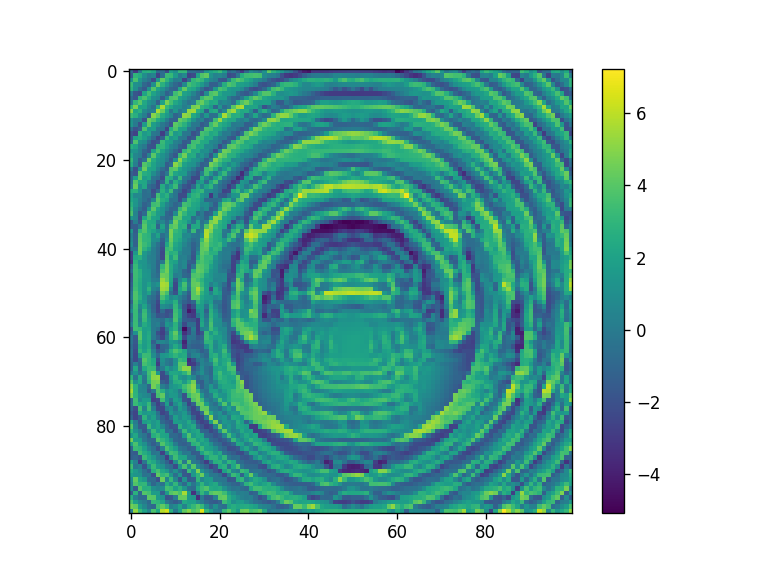

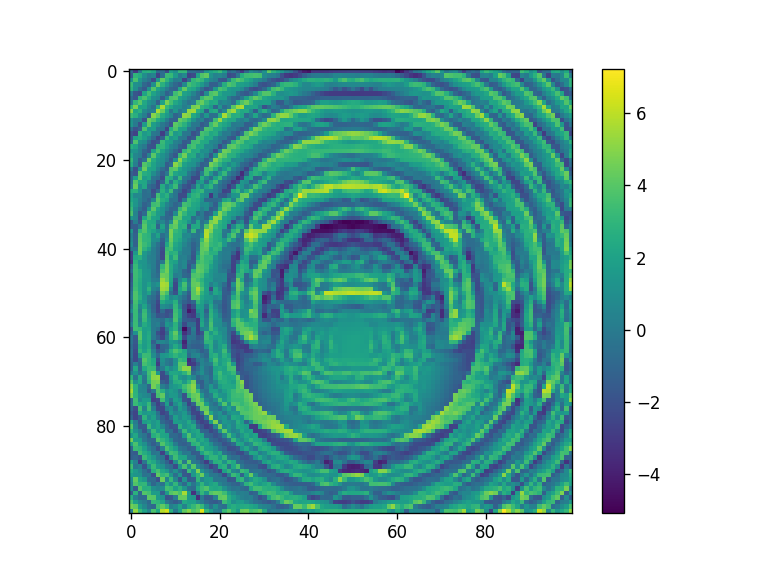

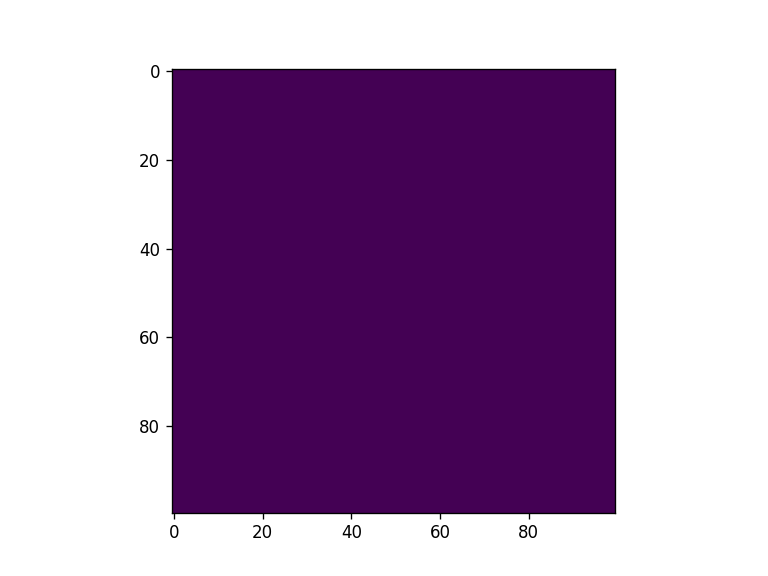

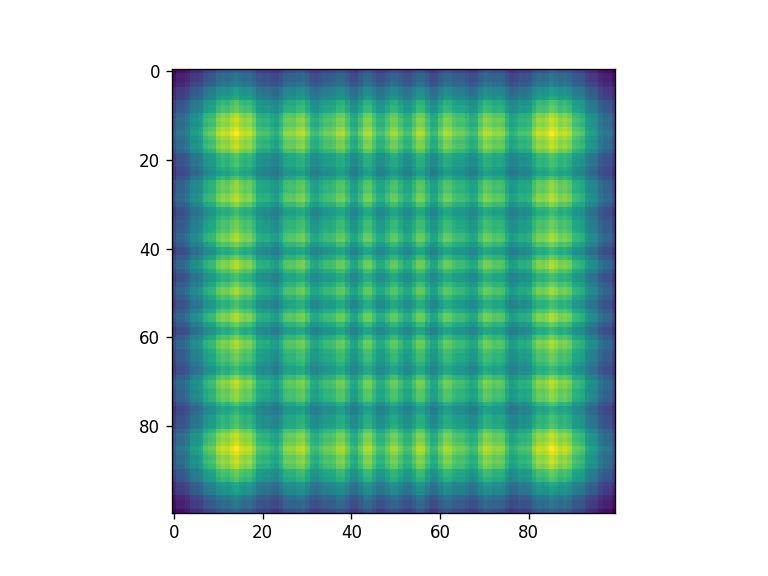

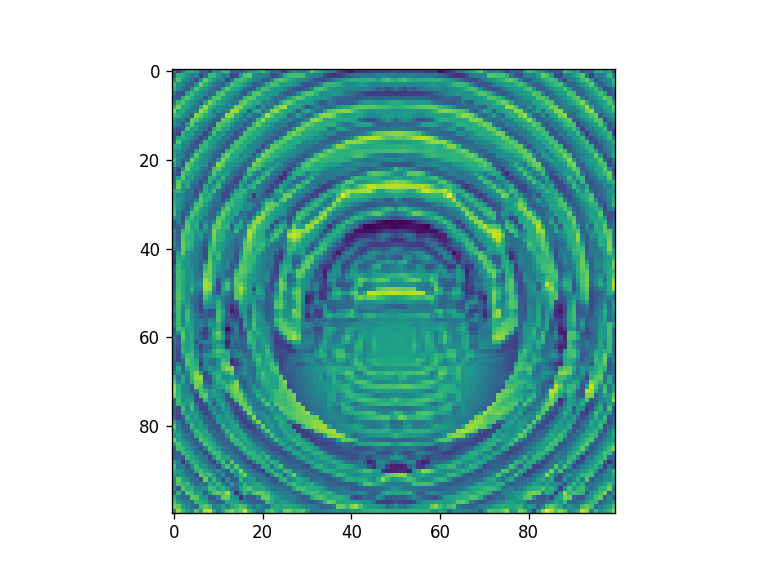

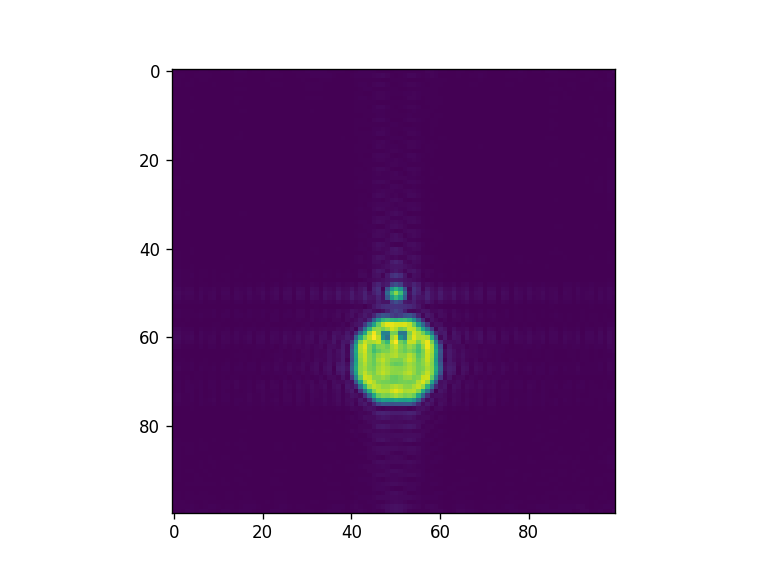

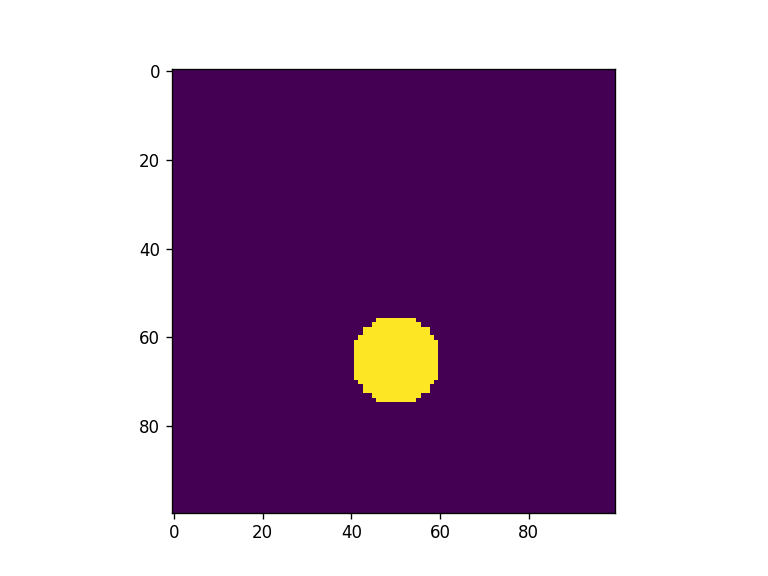

In [18]:
solution = moe.optimizer.optimize(FOM3, x0_flatten, args1=[mask2, screen, wavelength, matrix], verbose = 1, ftol=1e-5)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength) ) )


fig = plt.figure() 
plt.imshow(np.reshape(matrix, (x_pixel, y_pixel)) )


Elapsed: 0:00:00.026994
Elapsed: 0:00:00.144992
Elapsed: 0:00:00.035001
Elapsed: 0:00:00.085998
Elapsed: 0:00:00.036007
Elapsed: 0:00:00.079007
Elapsed: 0:00:00.031998
Elapsed: 0:00:00.069999
Elapsed: 0:00:00.035997
Elapsed: 0:00:00.084993
Elapsed: 0:00:00.069007
Elapsed: 0:00:00.039995
Elapsed: 0:00:00.038986
Elapsed: 0:00:00.100007
Elapsed: 0:00:00.029001
Elapsed: 0:00:00.091015
Elapsed: 0:00:00.025542
Elapsed: 0:00:00.068988
Elapsed: 0:00:00.025004
Elapsed: 0:00:00.061994
Elapsed: 0:00:00.020995
Elapsed: 0:00:00.044999
Elapsed: 0:00:00.095998
Elapsed: 0:00:00.034006
Elapsed: 0:00:00.072993
Elapsed: 0:00:00.033985
Elapsed: 0:00:00.093847
Elapsed: 0:00:00.038010
Elapsed: 0:00:00.079998
Elapsed: 0:00:00.024004
Elapsed: 0:00:00.099025
Elapsed: 0:00:00.028996
Elapsed: 0:00:00.081997
Elapsed: 0:00:00.040000
Elapsed: 0:00:00.040256
Elapsed: 0:00:00.094005
Elapsed: 0:00:00.021998
Elapsed: 0:00:00.081668
Elapsed: 0:00:00.080009
Elapsed: 0:00:00.056004
Elapsed: 0:00:00.030999
Elapsed: 0:00:00

Elapsed: 0:00:00.024985
Elapsed: 0:00:00.077460
Elapsed: 0:00:00.033593
Elapsed: 0:00:00.074352
Elapsed: 0:00:00.030970
Elapsed: 0:00:00.092309
Elapsed: 0:00:00.034541
Elapsed: 0:00:00.067285
Elapsed: 0:00:00.028958
Elapsed: 0:00:00.079247
Elapsed: 0:00:00.021164
Elapsed: 0:00:00.056008
Elapsed: 0:00:00.019023
Elapsed: 0:00:00.070374
Elapsed: 0:00:00.021004
Elapsed: 0:00:00.081008
Elapsed: 0:00:00.026990
Elapsed: 0:00:00.060458
Elapsed: 0:00:00.025560
Elapsed: 0:00:00.061010
Elapsed: 0:00:00.019999
Elapsed: 0:00:00.068032
Elapsed: 0:00:00.029005
Elapsed: 0:00:00.058002
Elapsed: 0:00:00.023999
Elapsed: 0:00:00.054994
Elapsed: 0:00:00.025007
Elapsed: 0:00:00.065038
Elapsed: 0:00:00.021008
Elapsed: 0:00:00.083969
Elapsed: 0:00:00.024017
Elapsed: 0:00:00.070553
Elapsed: 0:00:00.023994
Elapsed: 0:00:00.068842
Elapsed: 0:00:00.023007
Elapsed: 0:00:00.056000
Elapsed: 0:00:00.018997
Elapsed: 0:00:00.074771
Elapsed: 0:00:00.028545
Elapsed: 0:00:00.059001
Elapsed: 0:00:00.021011
Elapsed: 0:00:00

Elapsed: 0:00:00.069976
Elapsed: 0:00:00.032993
Elapsed: 0:00:00.083999
Elapsed: 0:00:00.018998
Elapsed: 0:00:00.077822
Elapsed: 0:00:00.022986
Elapsed: 0:00:00.081723
Elapsed: 0:00:00.031001
Elapsed: 0:00:00.068610
Elapsed: 0:00:00.021299
Elapsed: 0:00:00.071999
Elapsed: 0:00:00.026011
Elapsed: 0:00:00.068234
Elapsed: 0:00:00.029745
Elapsed: 0:00:00.115877
Elapsed: 0:00:00.067000
Elapsed: 0:00:00.104995
Elapsed: 0:00:00.043070
Elapsed: 0:00:00.100506
Elapsed: 0:00:00.033998
Elapsed: 0:00:00.101896
Elapsed: 0:00:00.031002
Elapsed: 0:00:00.076528
Elapsed: 0:00:00.042782
Elapsed: 0:00:00.072002
Elapsed: 0:00:00.031008
Elapsed: 0:00:00.054793
Elapsed: 0:00:00.021007
Elapsed: 0:00:00.072672
Elapsed: 0:00:00.018255
Elapsed: 0:00:00.069001
Elapsed: 0:00:00.022996
Elapsed: 0:00:00.072988
Elapsed: 0:00:00.023007
Elapsed: 0:00:00.072655
Elapsed: 0:00:00.034528
Elapsed: 0:00:00.066878
Elapsed: 0:00:00.028282
Elapsed: 0:00:00.077999
Elapsed: 0:00:00.025990
Elapsed: 0:00:00.069019
Elapsed: 0:00:00

Elapsed: 0:00:00.071992
Elapsed: 0:00:00.025992
Elapsed: 0:00:00.062284
Elapsed: 0:00:00.023987
Elapsed: 0:00:00.068170
Elapsed: 0:00:00.015999
Elapsed: 0:00:00.057056
Elapsed: 0:00:00.016296
Elapsed: 0:00:00.077993
Elapsed: 0:00:00.020005
Elapsed: 0:00:00.056002
Elapsed: 0:00:00.017992
Elapsed: 0:00:00.072012
Elapsed: 0:00:00.014996
Elapsed: 0:00:00.064732
Elapsed: 0:00:00.025703
Elapsed: 0:00:00.061136
Elapsed: 0:00:00.025005
Elapsed: 0:00:00.080001
Elapsed: 0:00:00.024006
Elapsed: 0:00:00.083102
Elapsed: 0:00:00.019999
Elapsed: 0:00:00.067663
Elapsed: 0:00:00.029001
Elapsed: 0:00:00.103999
Elapsed: 0:00:00.025981
Elapsed: 0:00:00.057742
Elapsed: 0:00:00.022008
Elapsed: 0:00:00.071988
Elapsed: 0:00:00.024994
Elapsed: 0:00:00.077739
Elapsed: 0:00:00.027006
Elapsed: 0:00:00.074994
Elapsed: 0:00:00.023465
Elapsed: 0:00:00.081996
Elapsed: 0:00:00.029024
Elapsed: 0:00:00.070985
Elapsed: 0:00:00.020003
Elapsed: 0:00:00.067832
Elapsed: 0:00:00.027005
Elapsed: 0:00:00.082289
Elapsed: 0:00:00

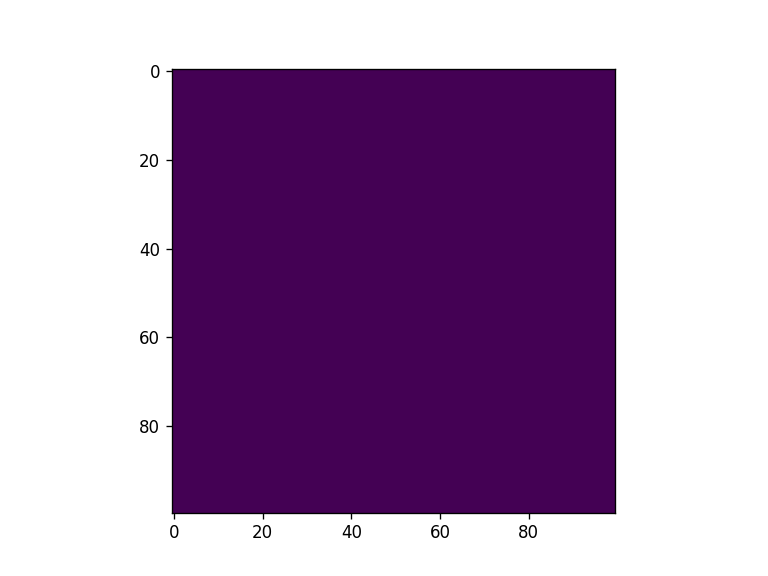

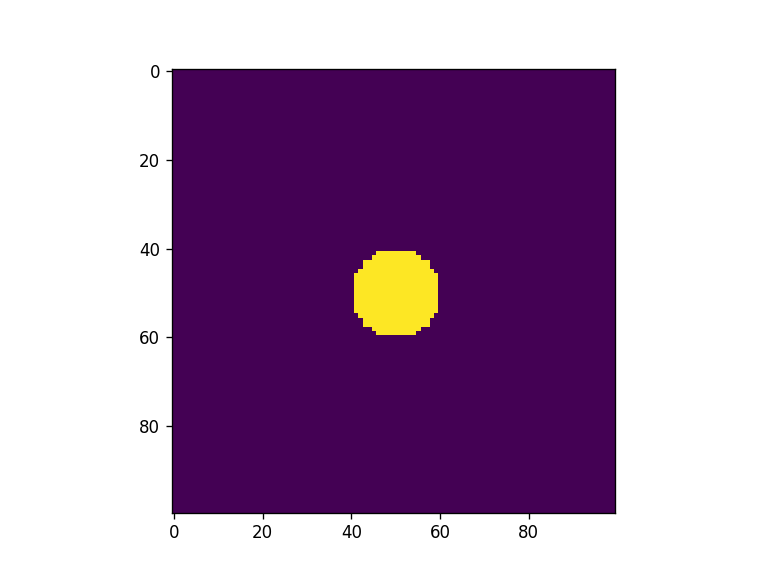

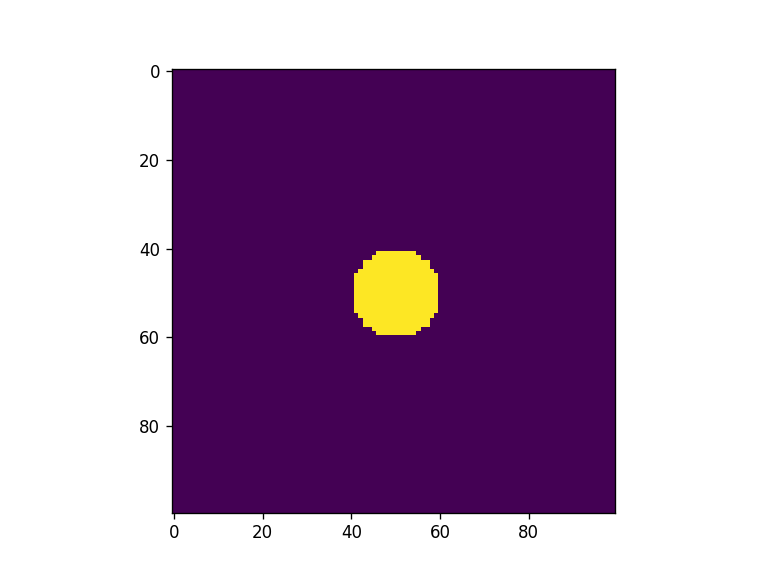

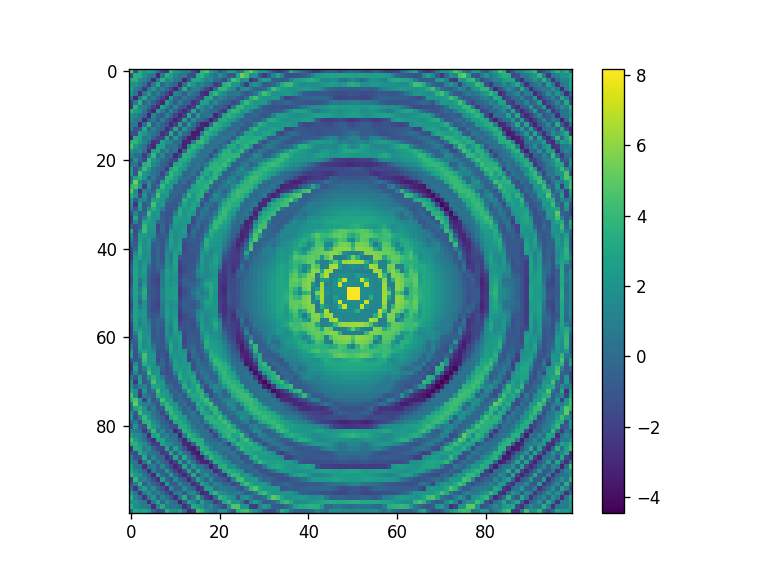

In [19]:
#Initial guess
x_pixel, y_pixel = 100, 100


x0 = np.random.rand(x_pixel, y_pixel)
x0 = np.ones((x_pixel,y_pixel))
x0_flatten = x0.flatten()


xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
    
matrix = np.zeros((x_pixel, y_pixel))
matrix[np.where(((XX-x_pixel/2)**2 + (YY-y_pixel/2)**2) < 10**2)] = 1 

matrix_flat = matrix.flatten()

fig = plt.figure() 
plt.imshow(x0)


fig = plt.figure() 
plt.imshow(matrix)

fig = plt.figure() 
plt.imshow(np.reshape(matrix_flat, (x_pixel, y_pixel)))


solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen, wavelength, matrix), verbose=1, ftol=1e-4)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.059011
Elapsed: 0:00:00.043577


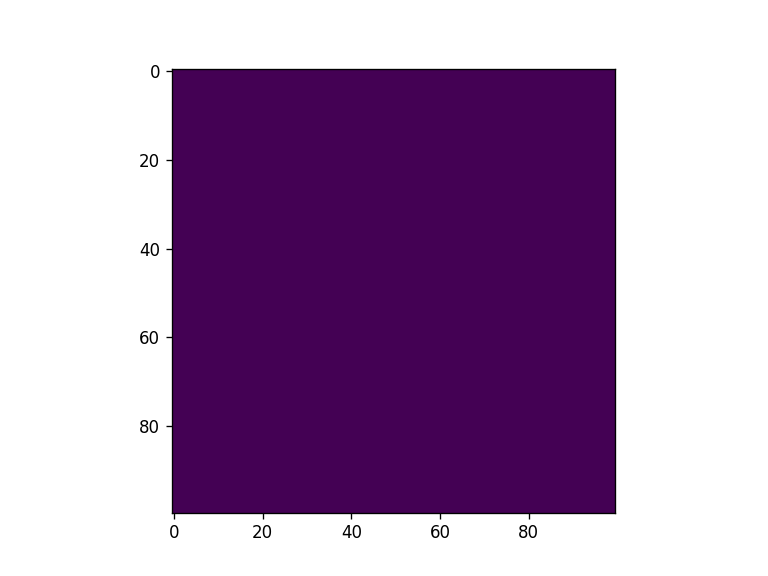

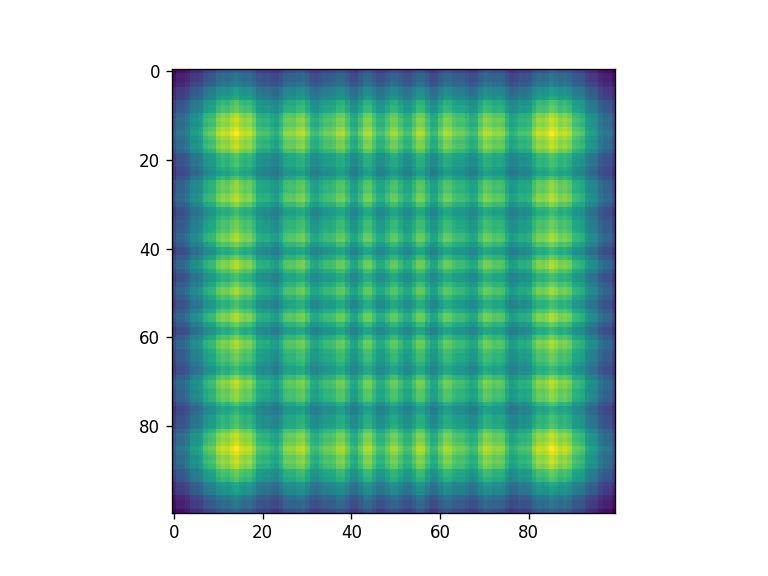

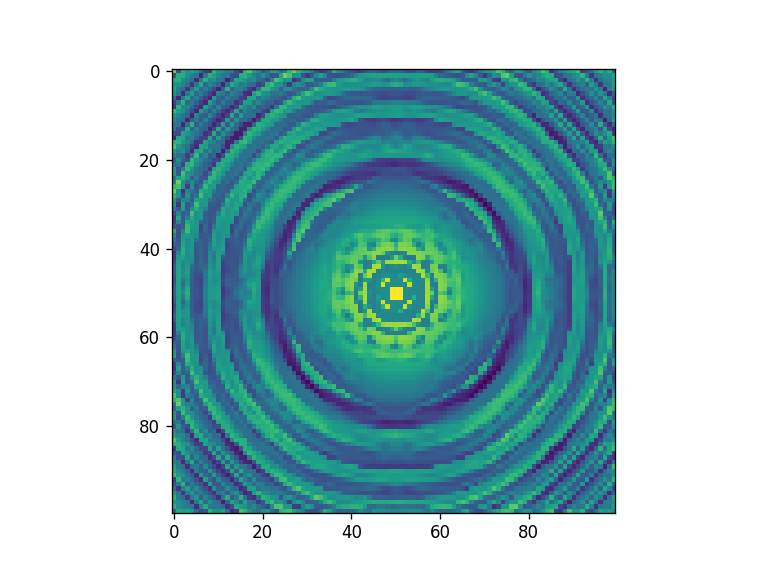

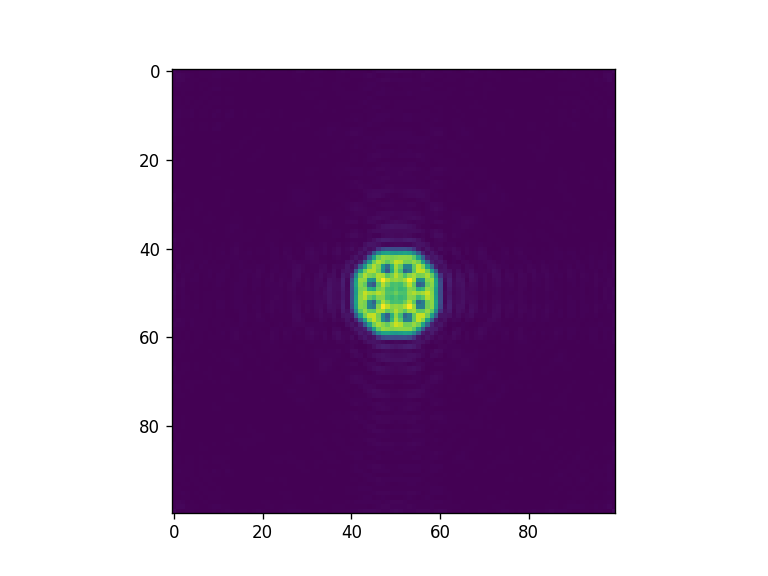

In [20]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar2 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar, mask2, screen, wavelength) ) )


Elapsed: 0:00:00.034994
Elapsed: 0:00:00.068004
Elapsed: 0:00:00.027997
Elapsed: 0:00:00.080001
Elapsed: 0:00:00.025001
Elapsed: 0:00:00.111353
Elapsed: 0:00:00.022002
Elapsed: 0:00:00.074015
Elapsed: 0:00:00.032006
Elapsed: 0:00:00.077815
Elapsed: 0:00:00.030019
Elapsed: 0:00:00.033535
Elapsed: 0:00:00.066996
Elapsed: 0:00:00.027992
Elapsed: 0:00:00.071992
Elapsed: 0:00:00.024000
Elapsed: 0:00:00.027998
Elapsed: 0:00:00.021001
Elapsed: 0:00:00.059004
Elapsed: 0:00:00.020000
Elapsed: 0:00:00.060992
Elapsed: 0:00:00.023579
Elapsed: 0:00:00.059974
Elapsed: 0:00:00.023989
Elapsed: 0:00:00.074996
Elapsed: 0:00:00.023524
Elapsed: 0:00:00.069999
Elapsed: 0:00:00.028583
Elapsed: 0:00:00.045567
Elapsed: 0:00:00.074998
Elapsed: 0:00:00.015997
Elapsed: 0:00:00.054824
Elapsed: 0:00:00.032995
Elapsed: 0:00:00.072327
Elapsed: 0:00:00.042845
Elapsed: 0:00:00.132560
Elapsed: 0:00:00.023009
Elapsed: 0:00:00.066991
Elapsed: 0:00:00.023010
Elapsed: 0:00:00.066010
Elapsed: 0:00:00.016990
Elapsed: 0:00:00

Elapsed: 0:00:00.064994
Elapsed: 0:00:00.020995
Elapsed: 0:00:00.052186
Elapsed: 0:00:00.027731
Elapsed: 0:00:00.024005
Elapsed: 0:00:00.057992
Elapsed: 0:00:00.034983
Elapsed: 0:00:00.048006
Elapsed: 0:00:00.021003
Elapsed: 0:00:00.062991
Elapsed: 0:00:00.028003
Elapsed: 0:00:00.070003
Elapsed: 0:00:00.032000
Elapsed: 0:00:00.075998
Elapsed: 0:00:00.027996
Elapsed: 0:00:00.047744
Elapsed: 0:00:00.018995
Elapsed: 0:00:00.064003
Elapsed: 0:00:00.016997
Elapsed: 0:00:00.069019
Elapsed: 0:00:00.028008
Elapsed: 0:00:00.076055
Elapsed: 0:00:00.045009
Elapsed: 0:00:00.109986
Elapsed: 0:00:00.027012
Elapsed: 0:00:00.059558
Elapsed: 0:00:00.037008
Elapsed: 0:00:00.080782
Elapsed: 0:00:00.029997
Elapsed: 0:00:00.086016
Elapsed: 0:00:00.028005
Elapsed: 0:00:00.098002
Elapsed: 0:00:00.034988
Elapsed: 0:00:00.042996
Elapsed: 0:00:00.112010
Elapsed: 0:00:00.040984
Elapsed: 0:00:00.158005
Elapsed: 0:00:00.036002
Elapsed: 0:00:00.090005
Elapsed: 0:00:00.024993
Elapsed: 0:00:00.071999
Elapsed: 0:00:00

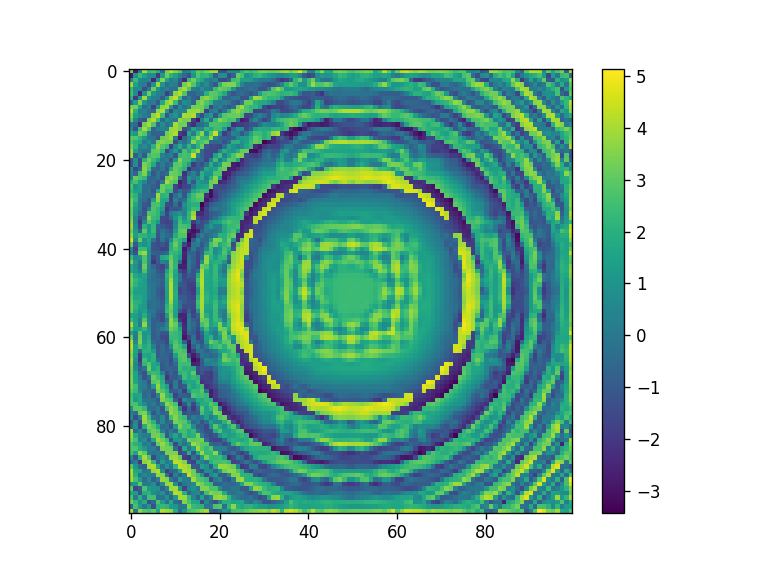

In [21]:
solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen, wavelength,matrix), optimizer_method="dogbox", verbose=0, ftol=1e-4)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()




Elapsed: 0:00:00.024998
Elapsed: 0:00:00.034991


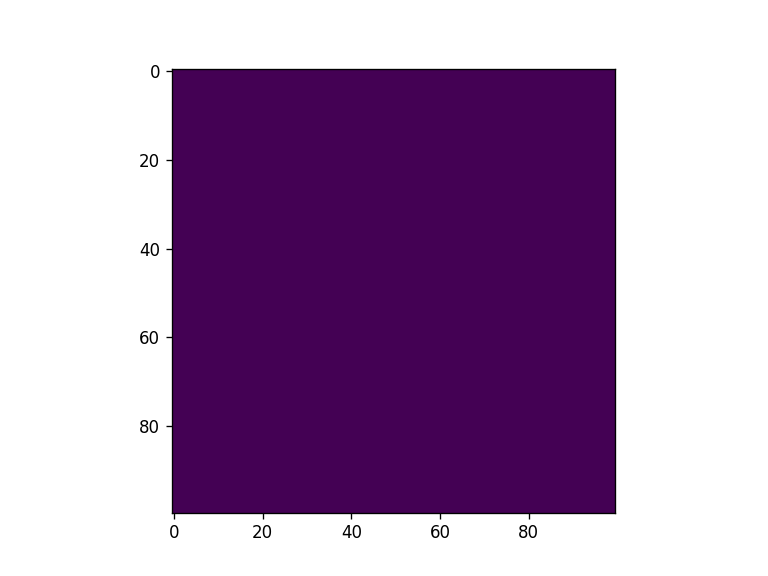

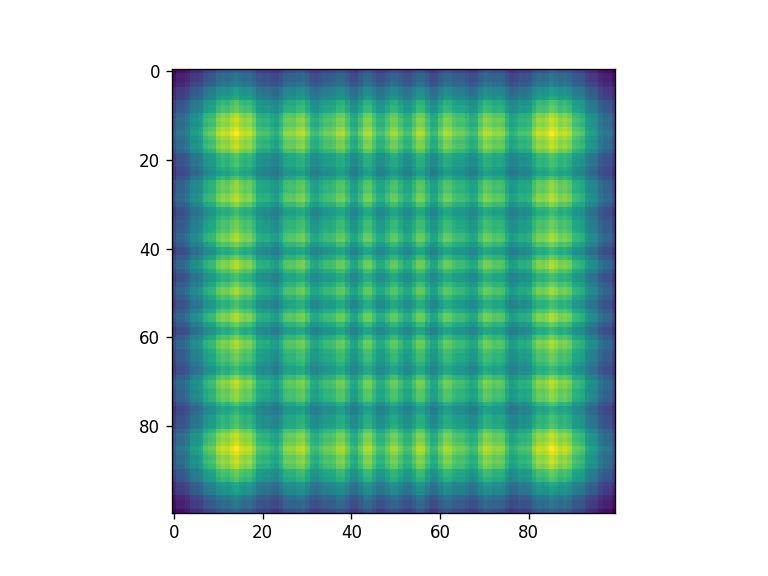

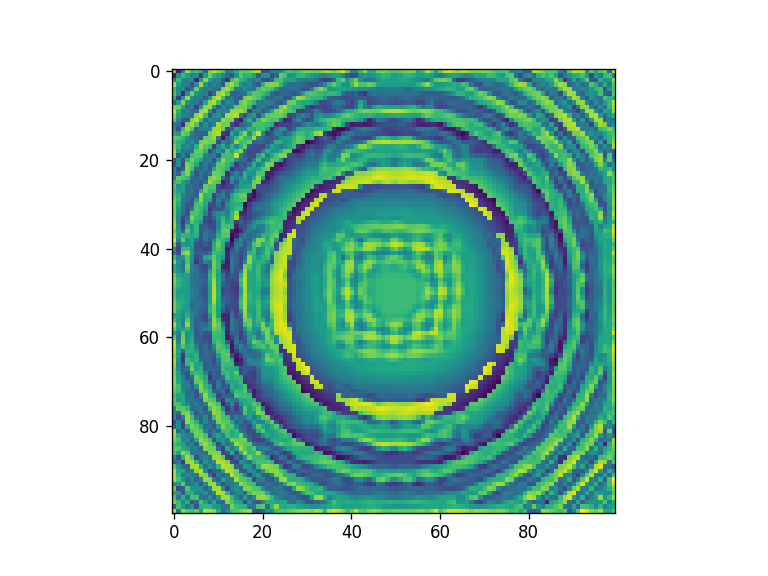

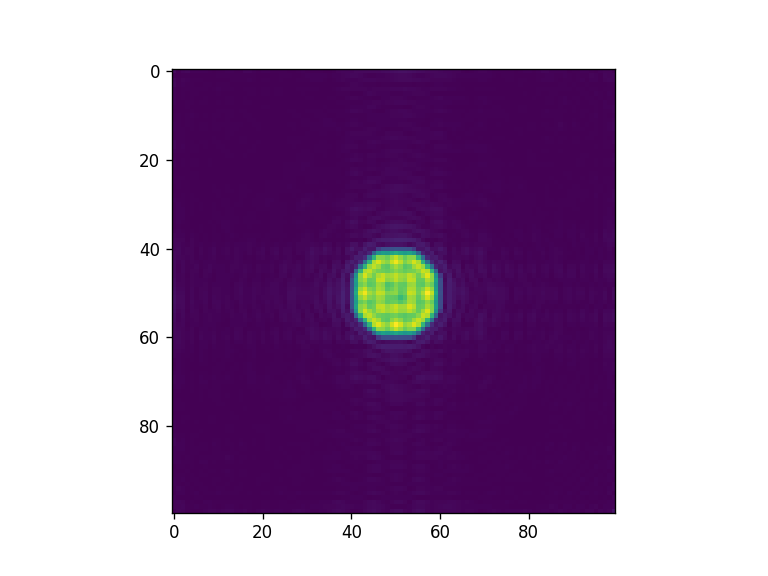

In [22]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar2 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar, mask2, screen, wavelength) ) )


Elapsed: 0:00:00.023010
Elapsed: 0:00:00.067004
Elapsed: 0:00:00.018003
Elapsed: 0:00:00.052006
Elapsed: 0:00:00.026998
Elapsed: 0:00:00.052990
Elapsed: 0:00:00.024010
Elapsed: 0:00:00.062547
Elapsed: 0:00:00.015005
Elapsed: 0:00:00.079567
Elapsed: 0:00:00.021009
Elapsed: 0:00:00.062006
Elapsed: 0:00:00.025996
Elapsed: 0:00:00.021012
Elapsed: 0:00:00.023994
`xtol` termination condition is satisfied.
Function evaluations 9, initial cost 3.9044e+01, final cost 1.3392e+01, first-order optimality 1.53e-03.


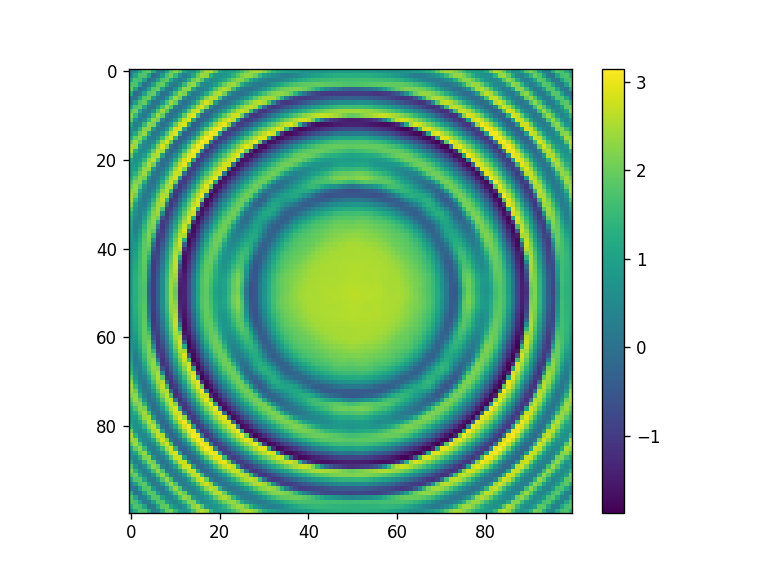

In [23]:
solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen, wavelength, matrix), optimizer_method="dogbox", bounds =(-np.pi, np.pi), ftol = 1e-4 )

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()




Elapsed: 0:00:00.025987
Elapsed: 0:00:00.033011


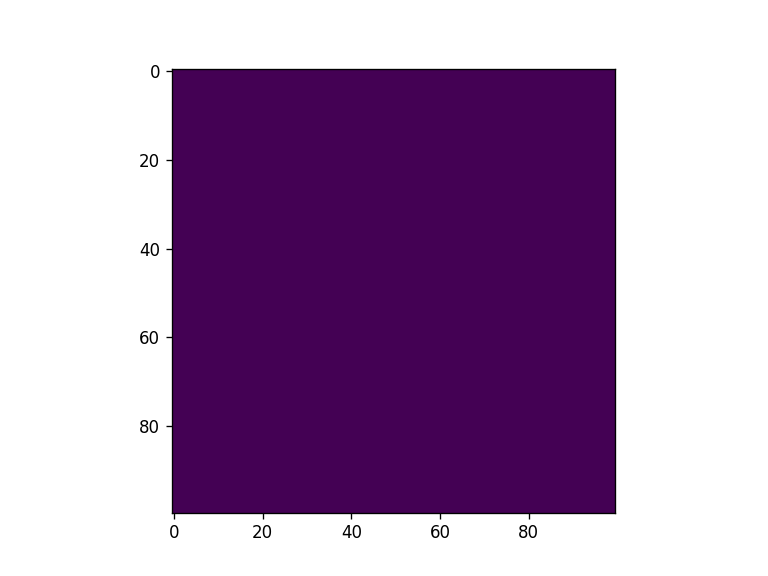

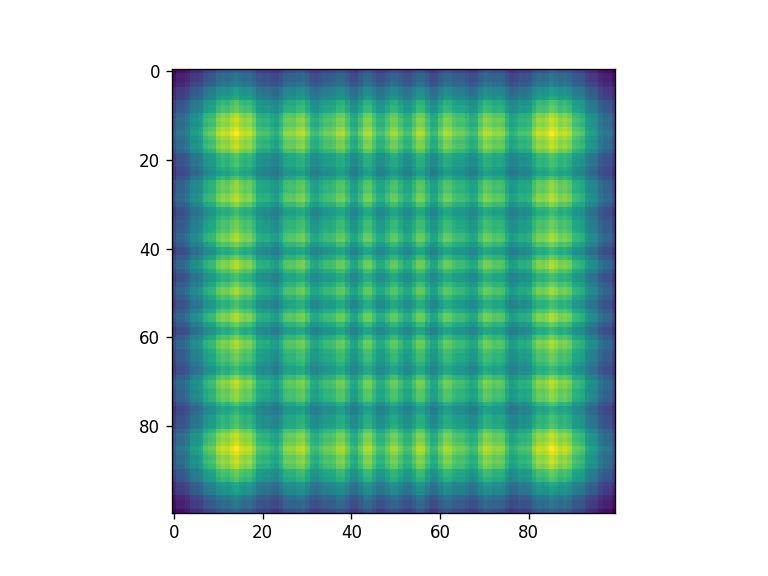

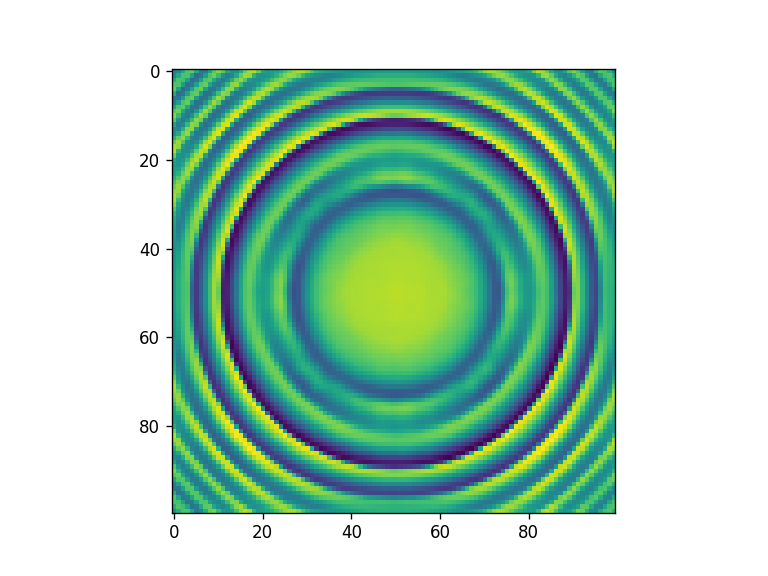

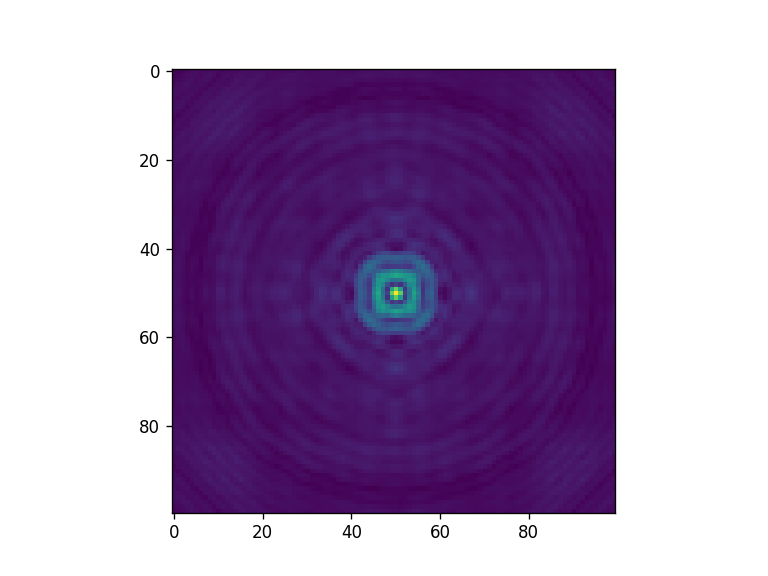

In [24]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar2 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar, mask2, screen, wavelength) ) )


Elapsed: 0:00:00.021005
Elapsed: 0:00:00.081985
Elapsed: 0:00:00.018991
Elapsed: 0:00:00.074024
Elapsed: 0:00:00.023001
Elapsed: 0:00:00.061028
Elapsed: 0:00:00.032050
Elapsed: 0:00:00.050812
Elapsed: 0:00:00.029992
Elapsed: 0:00:00.059996
Elapsed: 0:00:00.017994
Elapsed: 0:00:00.022990
Elapsed: 0:00:00.017998
Elapsed: 0:00:00.065992
Elapsed: 0:00:00.019956
Elapsed: 0:00:00.063000
Elapsed: 0:00:00.021011
Elapsed: 0:00:00.062006
Elapsed: 0:00:00.016995
Elapsed: 0:00:00.054015
Elapsed: 0:00:00.022996
Elapsed: 0:00:00.015990
Elapsed: 0:00:00.050022
Elapsed: 0:00:00.031998
Elapsed: 0:00:00.080017
Elapsed: 0:00:00.022001
Elapsed: 0:00:00.067076
Elapsed: 0:00:00.023001
Elapsed: 0:00:00.051003
Elapsed: 0:00:00.016988
Elapsed: 0:00:00.070007
Elapsed: 0:00:00.023999
Elapsed: 0:00:00.056515
Elapsed: 0:00:00.025003
Elapsed: 0:00:00.015996
Elapsed: 0:00:00.071570
Elapsed: 0:00:00.015995
Elapsed: 0:00:00.043007
Elapsed: 0:00:00.017999
Elapsed: 0:00:00.055012
Elapsed: 0:00:00.020992
Elapsed: 0:00:00

Elapsed: 0:00:00.072009
Elapsed: 0:00:00.020312
Elapsed: 0:00:00.063014
Elapsed: 0:00:00.018999
Elapsed: 0:00:00.052369
Elapsed: 0:00:00.026003
Elapsed: 0:00:00.049986
Elapsed: 0:00:00.024001
Elapsed: 0:00:00.050219
Elapsed: 0:00:00.033995
Elapsed: 0:00:00.085002
Elapsed: 0:00:00.017001
Elapsed: 0:00:00.076995
Elapsed: 0:00:00.024001
Elapsed: 0:00:00.058004
Elapsed: 0:00:00.030998
Elapsed: 0:00:00.052998
Elapsed: 0:00:00.016999
Elapsed: 0:00:00.219410
Elapsed: 0:00:00.033015
Elapsed: 0:00:00.062072
Elapsed: 0:00:00.021985
Elapsed: 0:00:00.067994
Elapsed: 0:00:00.017592
Elapsed: 0:00:00.058985
Elapsed: 0:00:00.018996
Elapsed: 0:00:00.062550
Elapsed: 0:00:00.022002
Elapsed: 0:00:00.053980
Elapsed: 0:00:00.027849
Elapsed: 0:00:00.066157
Elapsed: 0:00:00.016997
Elapsed: 0:00:00.051990
Elapsed: 0:00:00.021999
Elapsed: 0:00:00.066051
Elapsed: 0:00:00.024003
Elapsed: 0:00:00.071520
Elapsed: 0:00:00.021998
Elapsed: 0:00:00.077013
Elapsed: 0:00:00.020001
Elapsed: 0:00:00.070828
Elapsed: 0:00:00

Elapsed: 0:00:00.105001
Elapsed: 0:00:00.044006
Elapsed: 0:00:00.077000
Elapsed: 0:00:00.032006
Elapsed: 0:00:00.156963
Elapsed: 0:00:00.041991
Elapsed: 0:00:00.160996
Elapsed: 0:00:00.050002
Elapsed: 0:00:00.160238
Elapsed: 0:00:00.032995
Elapsed: 0:00:00.095011
Elapsed: 0:00:00.046004
Elapsed: 0:00:00.134013
Elapsed: 0:00:00.032993
Elapsed: 0:00:00.075002
Elapsed: 0:00:00.051999
Elapsed: 0:00:00.087000
Elapsed: 0:00:00.046583
Elapsed: 0:00:00.110559
Elapsed: 0:00:00.025990
Elapsed: 0:00:00.062005
Elapsed: 0:00:00.021002
Elapsed: 0:00:00.075018
Elapsed: 0:00:00.019007
Elapsed: 0:00:00.070811
Elapsed: 0:00:00.024005
Elapsed: 0:00:00.084996
Elapsed: 0:00:00.018003
Elapsed: 0:00:00.086000
Elapsed: 0:00:00.026988
Elapsed: 0:00:00.068573
Elapsed: 0:00:00.032001
Elapsed: 0:00:00.076005
Elapsed: 0:00:00.028993
Elapsed: 0:00:00.067007
Elapsed: 0:00:00.023993
Elapsed: 0:00:00.050992
Elapsed: 0:00:00.021994
Elapsed: 0:00:00.056025
Elapsed: 0:00:00.026006
Elapsed: 0:00:00.074011
Elapsed: 0:00:00

Elapsed: 0:00:00.025996
Elapsed: 0:00:00.051027
Elapsed: 0:00:00.015994
Elapsed: 0:00:00.067996
Elapsed: 0:00:00.021008
Elapsed: 0:00:00.055659
Elapsed: 0:00:00.029995
Elapsed: 0:00:00.052011
Elapsed: 0:00:00.020000
Elapsed: 0:00:00.124825
Elapsed: 0:00:00.016003
Elapsed: 0:00:00.042009
Elapsed: 0:00:00.027013
Elapsed: 0:00:00.059007
Elapsed: 0:00:00.022006
Elapsed: 0:00:00.056998
Elapsed: 0:00:00.022814
Elapsed: 0:00:00.061828
Elapsed: 0:00:00.021662
Elapsed: 0:00:00.055996
Elapsed: 0:00:00.025007
Elapsed: 0:00:00.060577
Elapsed: 0:00:00.018996
Elapsed: 0:00:00.068009
Elapsed: 0:00:00.025977
Elapsed: 0:00:00.057218
Elapsed: 0:00:00.020991
Elapsed: 0:00:00.064699
Elapsed: 0:00:00.016008
Elapsed: 0:00:00.047696
Elapsed: 0:00:00.028562
Elapsed: 0:00:00.051949
Elapsed: 0:00:00.013995
Elapsed: 0:00:00.061001
Elapsed: 0:00:00.015000
Elapsed: 0:00:00.054000
Elapsed: 0:00:00.017010
Elapsed: 0:00:00.055047
Elapsed: 0:00:00.022768
Elapsed: 0:00:00.067007
Elapsed: 0:00:00.017809
Elapsed: 0:00:00

Elapsed: 0:00:00.126850
Elapsed: 0:00:00.020006
Elapsed: 0:00:00.073004
Elapsed: 0:00:00.026000
Elapsed: 0:00:00.066997
Elapsed: 0:00:00.016999
Elapsed: 0:00:00.061990
Elapsed: 0:00:00.020988
Elapsed: 0:00:00.069002
Elapsed: 0:00:00.015999
Elapsed: 0:00:00.029001
Elapsed: 0:00:00.050992
Elapsed: 0:00:00.021001
Elapsed: 0:00:00.070532
Elapsed: 0:00:00.017994
Elapsed: 0:00:00.059000
Elapsed: 0:00:00.027010
Elapsed: 0:00:00.023026
Elapsed: 0:00:00.066008
Elapsed: 0:00:00.019012
Elapsed: 0:00:00.050004
Elapsed: 0:00:00.019992
Elapsed: 0:00:00.056002
Elapsed: 0:00:00.014992
Elapsed: 0:00:00.020000
Elapsed: 0:00:00.079995
Elapsed: 0:00:00.038009
Elapsed: 0:00:00.052997
Elapsed: 0:00:00.020998
Elapsed: 0:00:00.054998
Elapsed: 0:00:00.017996
Elapsed: 0:00:00.036001
Elapsed: 0:00:00.054015
Elapsed: 0:00:00.016994
Elapsed: 0:00:00.070857
Elapsed: 0:00:00.027999
Elapsed: 0:00:00.077002
Elapsed: 0:00:00.028009
Elapsed: 0:00:00.055996
Elapsed: 0:00:00.024004
Elapsed: 0:00:00.057011
Elapsed: 0:00:00

...

Elapsed: 0:00:00.231652
Elapsed: 0:00:00.022036
Elapsed: 0:00:00.070652
Elapsed: 0:00:00.032801
Elapsed: 0:00:00.067543
Elapsed: 0:00:00.018986
Elapsed: 0:00:00.053913
Elapsed: 0:00:00.021994
Elapsed: 0:00:00.056997
Elapsed: 0:00:00.021002
Elapsed: 0:00:00.060633
Elapsed: 0:00:00.024918
Elapsed: 0:00:00.064009
Elapsed: 0:00:00.026154
Elapsed: 0:00:00.060894
Elapsed: 0:00:00.017994
Elapsed: 0:00:00.059002
Elapsed: 0:00:00.022461
Elapsed: 0:00:00.061767
Elapsed: 0:00:00.029988
Elapsed: 0:00:00.066989
Elapsed: 0:00:00.023000
Elapsed: 0:00:00.048264
Elapsed: 0:00:00.018997
Elapsed: 0:00:00.069003
Elapsed: 0:00:00.014998
Elapsed: 0:00:00.058003
Elapsed: 0:00:00.019001
Elapsed: 0:00:00.055007
Elapsed: 0:00:00.032549
Elapsed: 0:00:00.058005
Elapsed: 0:00:00.022987
Elapsed: 0:00:00.064003
Elapsed: 0:00:00.023993
Elapsed: 0:00:00.064011
Elapsed: 0:00:00.022006
Elapsed: 0:00:00.054998
Elapsed: 0:00:00.022001
Elapsed: 0:00:00.054001
Elapsed: 0:00:00.018999
Elapsed: 0:00:00.066002
Elapsed: 0:00:00

Elapsed: 0:00:00.059612
Elapsed: 0:00:00.016011
Elapsed: 0:00:00.060997
Elapsed: 0:00:00.026006
Elapsed: 0:00:00.042040
Elapsed: 0:00:00.028748
Elapsed: 0:00:00.057194
Elapsed: 0:00:00.026993
Elapsed: 0:00:00.056680
Elapsed: 0:00:00.025995
Elapsed: 0:00:00.057747
Elapsed: 0:00:00.026007
Elapsed: 0:00:00.065264
Elapsed: 0:00:00.026994
Elapsed: 0:00:00.081994
Elapsed: 0:00:00.023984
Elapsed: 0:00:00.066074
Elapsed: 0:00:00.016996
Elapsed: 0:00:00.059648
Elapsed: 0:00:00.024994
Elapsed: 0:00:00.077655
Elapsed: 0:00:00.028661
Elapsed: 0:00:00.248948
Elapsed: 0:00:00.031994
Elapsed: 0:00:00.062999
Elapsed: 0:00:00.022007
Elapsed: 0:00:00.066018
Elapsed: 0:00:00.030991
Elapsed: 0:00:00.082669
Elapsed: 0:00:00.029998
Elapsed: 0:00:00.085674
Elapsed: 0:00:00.016010
Elapsed: 0:00:00.066626
Elapsed: 0:00:00.022997
Elapsed: 0:00:00.068041
Elapsed: 0:00:00.030993
Elapsed: 0:00:00.070046
Elapsed: 0:00:00.022069
Elapsed: 0:00:00.064000
Elapsed: 0:00:00.025999
Elapsed: 0:00:00.067760
Elapsed: 0:00:00

Elapsed: 0:00:00.098199
Elapsed: 0:00:00.022993
Elapsed: 0:00:00.069208
Elapsed: 0:00:00.019722
Elapsed: 0:00:00.069009
Elapsed: 0:00:00.017002
Elapsed: 0:00:00.029998
Elapsed: 0:00:00.092103
Elapsed: 0:00:00.030144
Elapsed: 0:00:00.064003
Elapsed: 0:00:00.022005
Elapsed: 0:00:00.053262
Elapsed: 0:00:00.023004
Elapsed: 0:00:00.020000
Elapsed: 0:00:00.074988
Elapsed: 0:00:00.022683
Elapsed: 0:00:00.064535
Elapsed: 0:00:00.022005
Elapsed: 0:00:00.058727
Elapsed: 0:00:00.019994
Elapsed: 0:00:00.019008
Elapsed: 0:00:00.053046
Elapsed: 0:00:00.015997
Elapsed: 0:00:00.058007
Elapsed: 0:00:00.022004
Elapsed: 0:00:00.057693
Elapsed: 0:00:00.016991
Elapsed: 0:00:00.023003
Elapsed: 0:00:00.056938
Elapsed: 0:00:00.021837
Elapsed: 0:00:00.062415
Elapsed: 0:00:00.038000
Elapsed: 0:00:00.064156
Elapsed: 0:00:00.026088
Elapsed: 0:00:00.025015
Elapsed: 0:00:00.053994
Elapsed: 0:00:00.021008
Elapsed: 0:00:00.057991
Elapsed: 0:00:00.019009
Elapsed: 0:00:00.048004
Elapsed: 0:00:00.016000
Elapsed: 0:00:00

Elapsed: 0:00:00.020003
Elapsed: 0:00:00.023999
Elapsed: 0:00:00.076772
Elapsed: 0:00:00.030998
Elapsed: 0:00:00.072572
Elapsed: 0:00:00.027995
Elapsed: 0:00:00.063171
Elapsed: 0:00:00.027013
Elapsed: 0:00:00.092016
Elapsed: 0:00:00.026001
Elapsed: 0:00:00.075921
Elapsed: 0:00:00.026735
Elapsed: 0:00:00.063812
Elapsed: 0:00:00.019006
Elapsed: 0:00:00.065780
Elapsed: 0:00:00.014003
Elapsed: 0:00:00.064005
Elapsed: 0:00:00.025012
Elapsed: 0:00:00.033911
Elapsed: 0:00:00.058004
Elapsed: 0:00:00.032989
Elapsed: 0:00:00.081572
Elapsed: 0:00:00.021997
Elapsed: 0:00:00.078658
Elapsed: 0:00:00.034004
Elapsed: 0:00:00.079731
Elapsed: 0:00:00.019989
Elapsed: 0:00:00.078708
Elapsed: 0:00:00.025027
Elapsed: 0:00:00.052904
Elapsed: 0:00:00.020000
Elapsed: 0:00:00.067666
Elapsed: 0:00:00.022989
Elapsed: 0:00:00.063992
Elapsed: 0:00:00.021000
Elapsed: 0:00:00.072812
Elapsed: 0:00:00.018010
Elapsed: 0:00:00.054689
Elapsed: 0:00:00.016692
Elapsed: 0:00:00.048992
Elapsed: 0:00:00.018998
Elapsed: 0:00:00

Elapsed: 0:00:00.070989
Elapsed: 0:00:00.024002
Elapsed: 0:00:00.171635
Elapsed: 0:00:00.024002
Elapsed: 0:00:00.078013
Elapsed: 0:00:00.037998
Elapsed: 0:00:00.155998
Elapsed: 0:00:00.037016
Elapsed: 0:00:00.087998
Elapsed: 0:00:00.038000
Elapsed: 0:00:00.085010
Elapsed: 0:00:00.033012
Elapsed: 0:00:00.059005
Elapsed: 0:00:00.023002
Elapsed: 0:00:00.066999
`ftol` termination condition is satisfied.
Function evaluations 3149, initial cost 3.9044e+01, final cost 4.7193e+00, first-order optimality 1.28e-04.


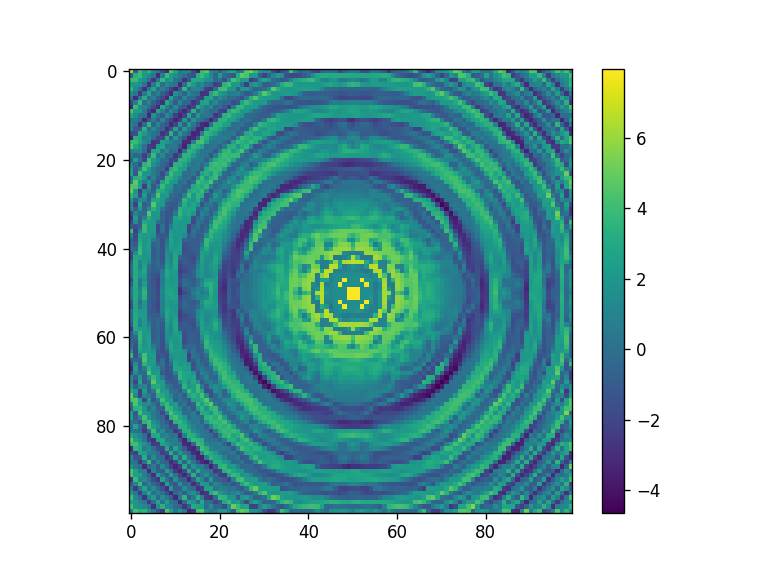

In [25]:
solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen, wavelength, matrix), ftol=1e-6)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()




Elapsed: 0:00:00.040002
Elapsed: 0:00:00.046007


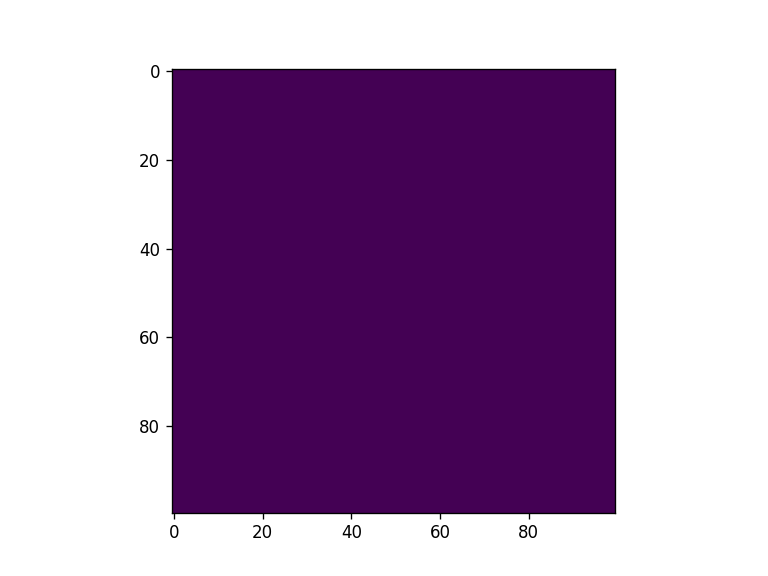

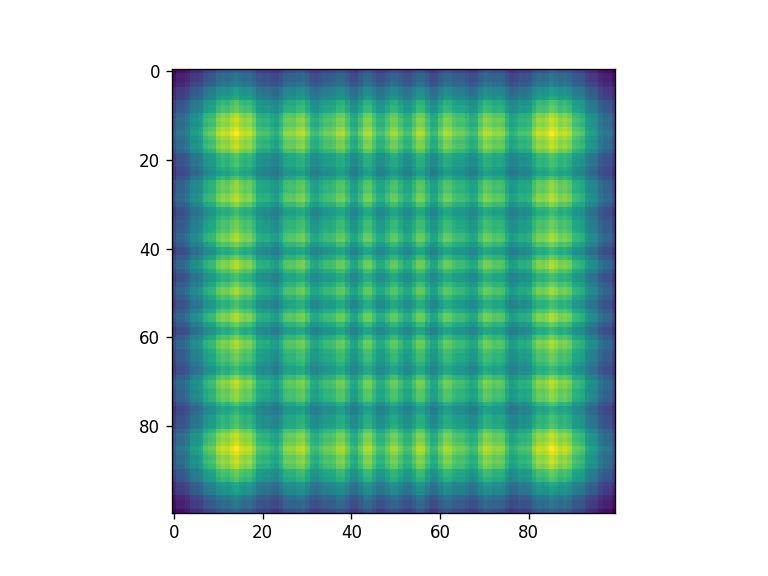

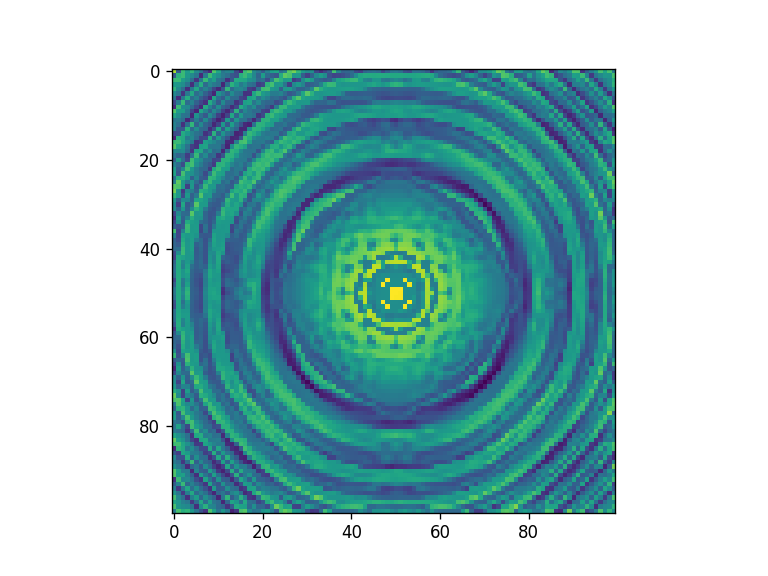

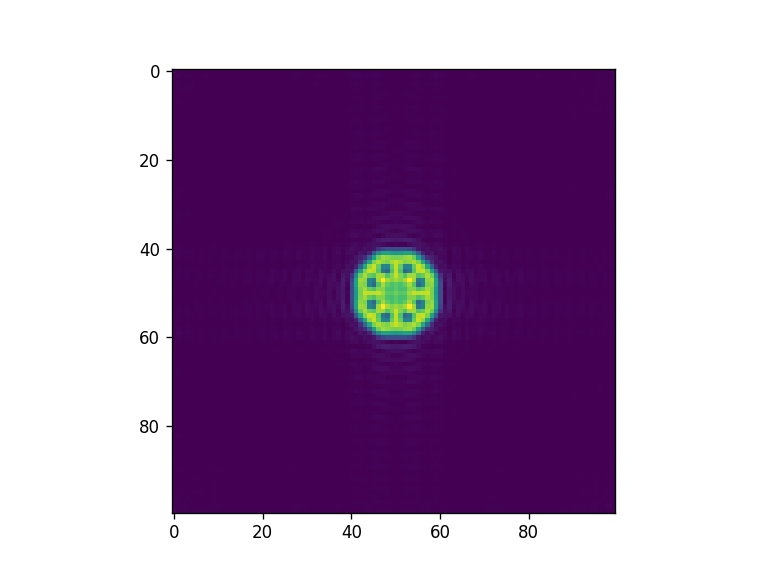

In [26]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar2 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar, mask2, screen, wavelength) ) )


In [27]:
#Uncomment to try any of these global optimization methods 

##bounds = [(-np.pi, np.pi)]*len(x0_flatten)

##solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen,wavelength),  optimizer_method="dual_annealing", tol=1 , minimizer_kwargs={"args":(mask2, screen, wavelength), "tol": 1 },  bounds = bounds)

##solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen),  optimizer_method="basinhopping", tol=1 ,minimizer_kwargs={"args":(mask2, screen), "tol": 1 },  bounds = bounds)

##solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen),  optimizer_method="differential_evolution", tol=1 ,minimizer_kwargs={"args":(mask2, screen), "tol": 1 },  bounds = bounds)



## Hologram creation via inverse design

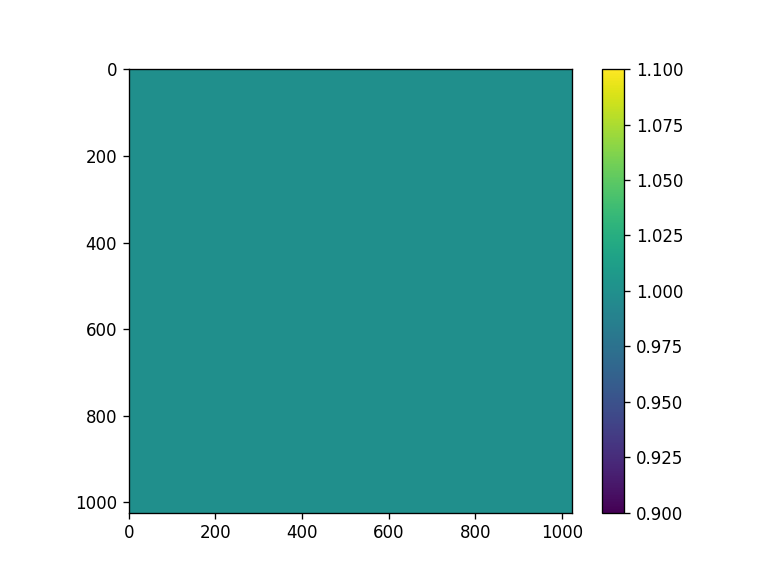

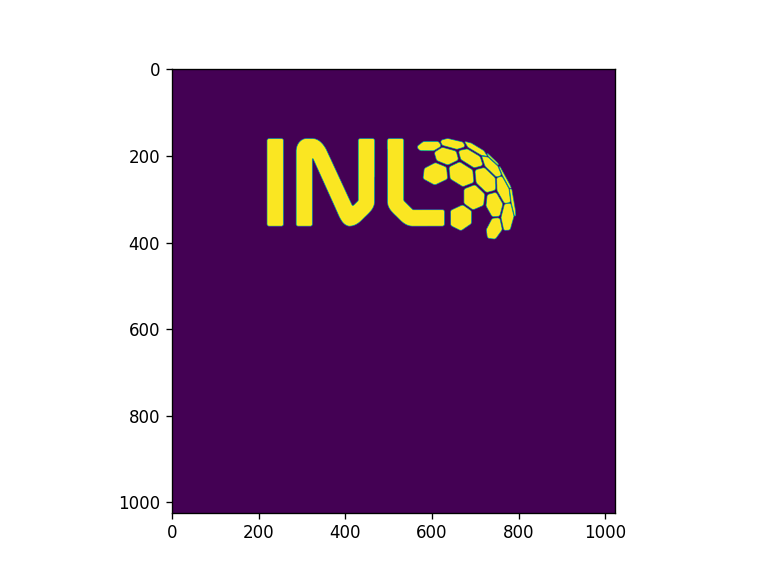

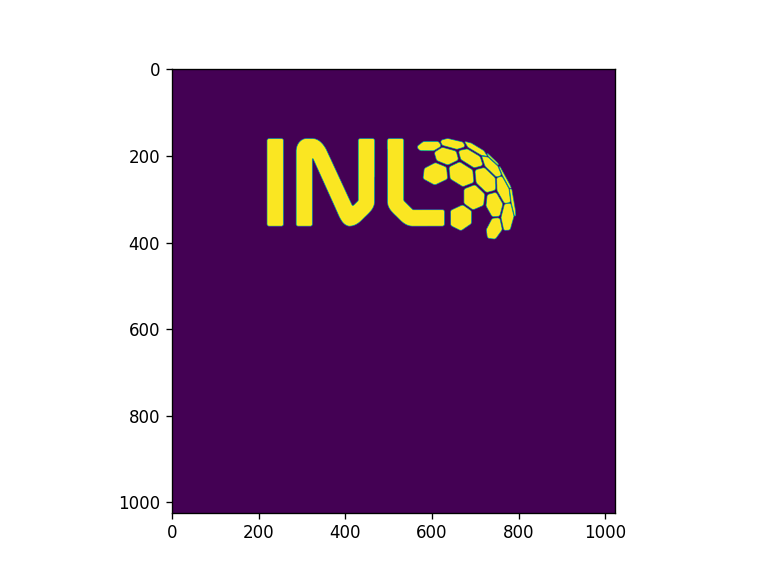

In [4]:
#Using GS first 

#Initial guess
x_pixel, y_pixel = 100, 100
matrix = plt.imread("target.png")

x_pixel, y_pixel = np.shape(matrix)
matrix_flat = matrix.flatten()

x0 = np.random.rand(x_pixel, y_pixel) 
x0 = np.ones((x_pixel,y_pixel))
#x0 = 
x0_flatten = x0.flatten()


xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
    

fig = plt.figure() 
plt.imshow(x0)
plt.colorbar()


fig = plt.figure() 
plt.imshow(matrix)

fig = plt.figure() 
plt.imshow(np.reshape(matrix_flat, (x_pixel, y_pixel)))

Progress: [####################] 100.0%
[Gerchberg Saxton Algorithm]
Elapsed: 0:01:09.629131


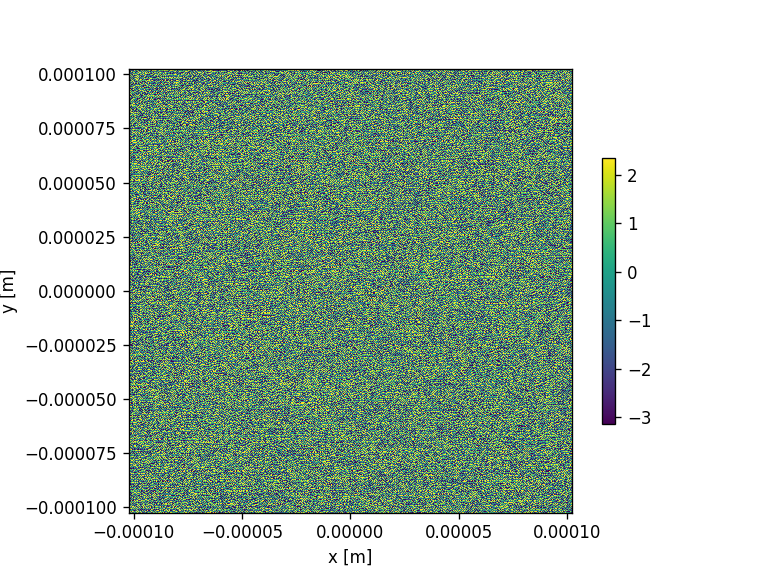

In [5]:
# Multilevel phase hologram
levels = 8

iterations = 100

levels = moe.utils.create_levels(-np.pi, np.pi, levels,)
phase_mask, errors = moe.holograms.algorithm_Gerchberg_Saxton(matrix, iterations=iterations, levels=levels)

phase_mask = moe.holograms.correct_mask_shift(phase_mask)
mask = moe.generate.create_aperture_from_array(phase_mask, pixel_size=(0.2*micro, 0.2*micro), center=True, )


# Discretize to same levels as original
mask.discretize(levels)
moe.plotting.plot_aperture(mask)



Text(0.5, 1.0, 'Calculated far field intensity')

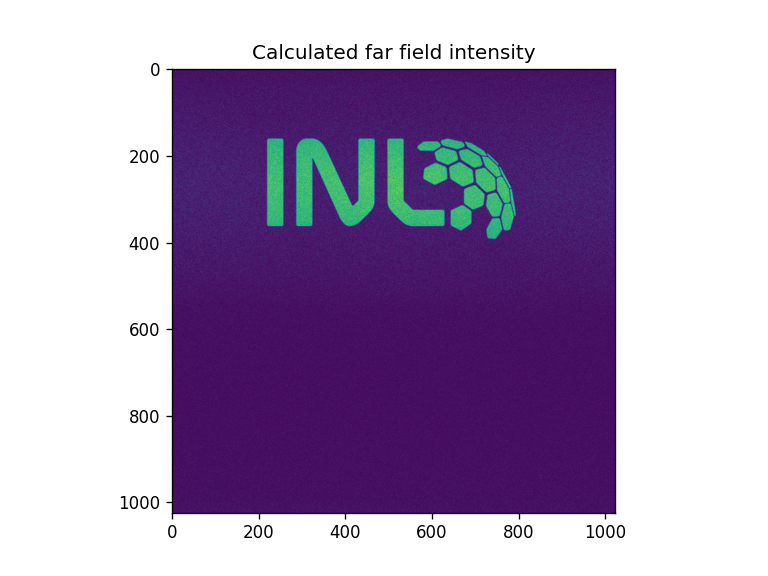

In [6]:

far_field = moe.holograms.calculate_phase_farfield(phase_mask)

plt.figure()
plt.imshow(far_field)
plt.title("Calculated far field intensity")


In [7]:
#Place holders for apertures 

#size of the rectangular mask 
aperture_width  = 50e-6 #m
aperture_height = 50e-6

pixsize = 1e-6 #m

wavelength = 500e-9 #m
focal_length = 200e-6

zmin = wavelength
zmax = 1.2* focal_length
nzs = 500

radius = aperture_width/2 

# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask1 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

#moe.plotting.plot_aperture(mask1)


##############
###Fresnel mask with a truncated circular aperture 

# Create empty mask
aperture2 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)


# and truncate around radius
mask2 = moe.generate.fresnel_phase(aperture2, focal_length, wavelength, radius=radius)
#moe.plotting.plot_aperture(mask2)

# Discretize mask in number of levels
# Select exact position of contours  in phase
phase_vals = np.linspace(-np.pi, np.pi, 16)

mask2.discretize(np.array( phase_vals)[:] ) 
#moe.plotting.plot_aperture(mask2)

# Generate a uniform field
field = moe.field.create_empty_field_from_aperture(mask2)

field = moe.field.generate_uniform_field(field, E0=1)

# Modulates the field 
field = moe.field.modulate_field(field, amplitude_mask=None, phase_mask=mask2 )


# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask2 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

#moe.plotting.plot_aperture(mask2)

In [8]:
#Define Screen 

# define the wavelength used in the propagation
wavelength = 532*nano

# Define the screen size and create it

screen_width = 2.5
screen_height = 2.5
x_pixel = 1024
y_pixel = 1024


# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -screen_height/2, screen_height/2
xmin, xmax = -screen_width/2, screen_width/2 

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([2])


screen = moe.field.Screen(x,y,z)

In [9]:


def FOM3(x, mask, screen, wavelength, mat): 
    #print("Type of x:", type(x), "First element:", x[0])
    #print("Type of x:", type(mask))
    #print("Type of x:", type(screen), "First element:", x[0])
    #print("Type of x:", type(wavelength), "First element:", x[0])
    import jax.numpy as np 
    
    prop_x =  np.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength))**2
    
    diff = np.abs(prop_x/np.max(prop_x) - mat/np.max(mat))**2
     
    #print(diff.shape)
    res = (np.sqrt(np.sum(diff)) )
    #print(res)
    
    return res


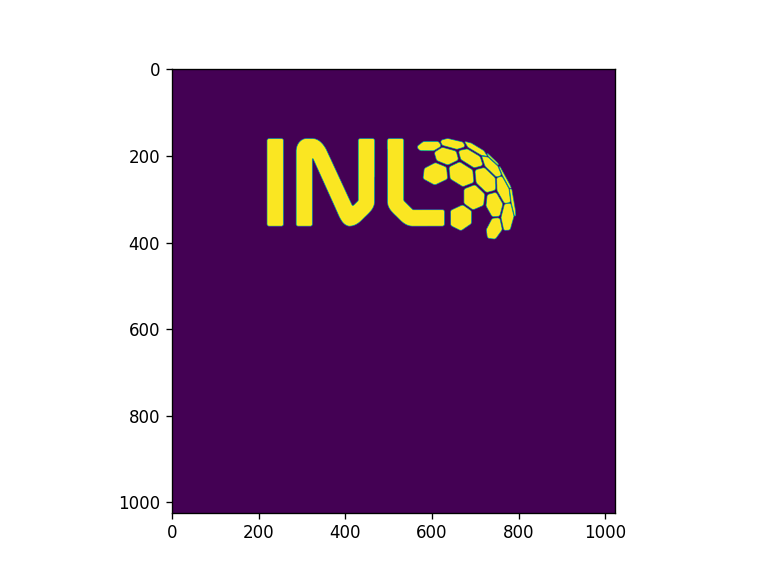

In [10]:

fig = plt.figure() 
plt.imshow(matrix)


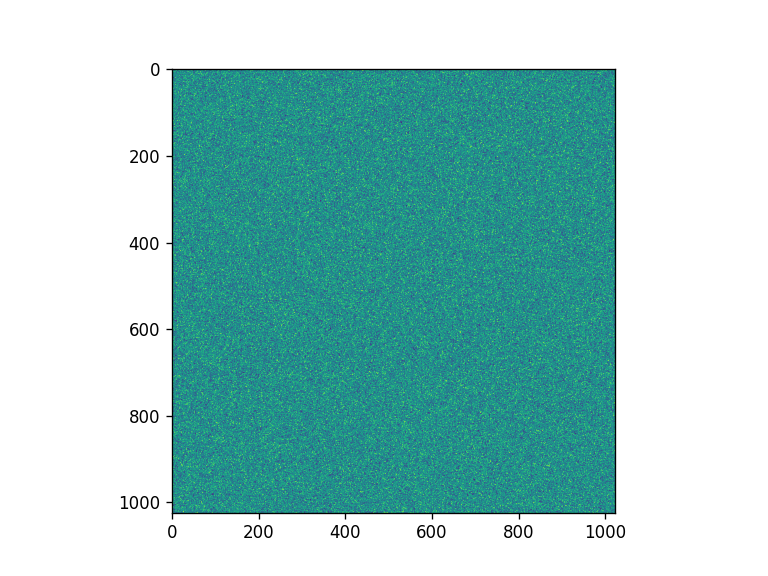

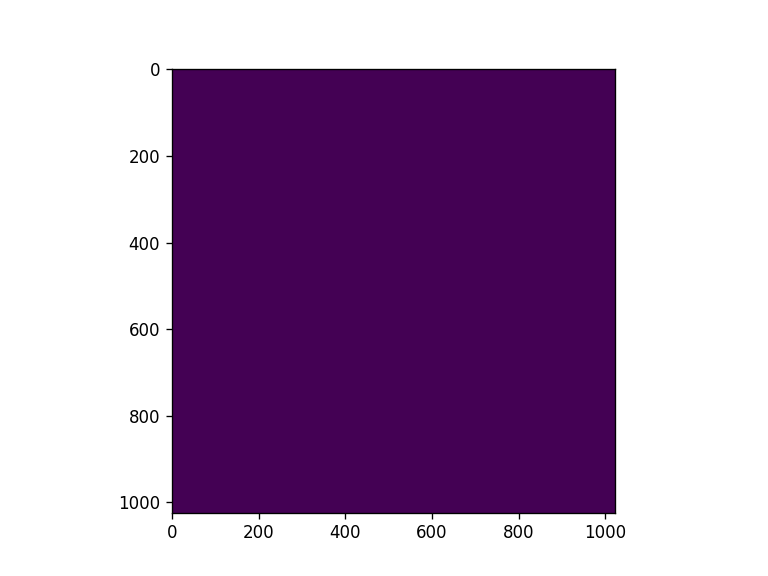

In [11]:
# generation of initial guesses, 

#random 
xrand = np.random.rand(x_pixel, y_pixel)

plt.figure() 
plt.imshow(xrand)

#constant 
xvalues = np.ones((x_pixel, y_pixel))

plt.figure()
plt.imshow(xvalues)
#plt.colorbar()

Elapsed: 0:00:02.275607
Elapsed: 0:00:01.108894
Elapsed: 0:00:00.731997
Elapsed: 0:00:00.751032
Elapsed: 0:00:00.577708
Elapsed: 0:00:00.851990
Elapsed: 0:00:00.587809
Elapsed: 0:00:00.732004
Elapsed: 0:00:00.543481
Elapsed: 0:00:00.675855
Elapsed: 0:00:00.550962
Elapsed: 0:00:00.660844
Elapsed: 0:00:00.593029
Elapsed: 0:00:00.721015
Elapsed: 0:00:00.577883
Elapsed: 0:00:00.684347
Elapsed: 0:00:00.535528
Elapsed: 0:00:00.687480
Elapsed: 0:00:00.539138
Elapsed: 0:00:00.676001
Elapsed: 0:00:00.549290
Elapsed: 0:00:00.665863
Elapsed: 0:00:00.523527
Elapsed: 0:00:00.644136
Elapsed: 0:00:00.552729
Elapsed: 0:00:00.995975
Elapsed: 0:00:01.337788
Elapsed: 0:00:00.813992
Elapsed: 0:00:00.551305
Elapsed: 0:00:00.649619
Elapsed: 0:00:00.560705
Elapsed: 0:00:00.725051
Elapsed: 0:00:00.593318
Elapsed: 0:00:00.754470
Elapsed: 0:00:00.576454
Elapsed: 0:00:00.604533
Elapsed: 0:00:00.682359
Elapsed: 0:00:00.566652
Elapsed: 0:00:00.680351
Elapsed: 0:00:00.574909
Elapsed: 0:00:00.778016
Elapsed: 0:00:00

Elapsed: 0:00:00.660955
Elapsed: 0:00:00.711943
Elapsed: 0:00:00.673307
Elapsed: 0:00:00.754452
Elapsed: 0:00:00.705039
Elapsed: 0:00:00.697357
Elapsed: 0:00:00.729326
Elapsed: 0:00:00.660528
Elapsed: 0:00:00.616994
Elapsed: 0:00:00.778995
Elapsed: 0:00:00.562462
Elapsed: 0:00:00.580427
Elapsed: 0:00:00.573766
Elapsed: 0:00:00.588332
Elapsed: 0:00:00.589024
Elapsed: 0:00:00.574164
Elapsed: 0:00:00.728429
Elapsed: 0:00:00.600798
Elapsed: 0:00:00.545783
Elapsed: 0:00:00.536287
Elapsed: 0:00:00.605427
Elapsed: 0:00:00.624192
Elapsed: 0:00:00.659290
Elapsed: 0:00:00.578432
Elapsed: 0:00:00.624345
Elapsed: 0:00:00.657816
Elapsed: 0:00:00.612576
Elapsed: 0:00:00.577006
Elapsed: 0:00:00.608344
Elapsed: 0:00:00.612931
Elapsed: 0:00:00.592746
Elapsed: 0:00:00.614188
Elapsed: 0:00:00.574461
Elapsed: 0:00:00.544527
Elapsed: 0:00:00.533921
Elapsed: 0:00:00.535338
Elapsed: 0:00:00.536974
Elapsed: 0:00:00.510809
Elapsed: 0:00:00.532514
Elapsed: 0:00:00.532522
Elapsed: 0:00:00.556387
Elapsed: 0:00:00

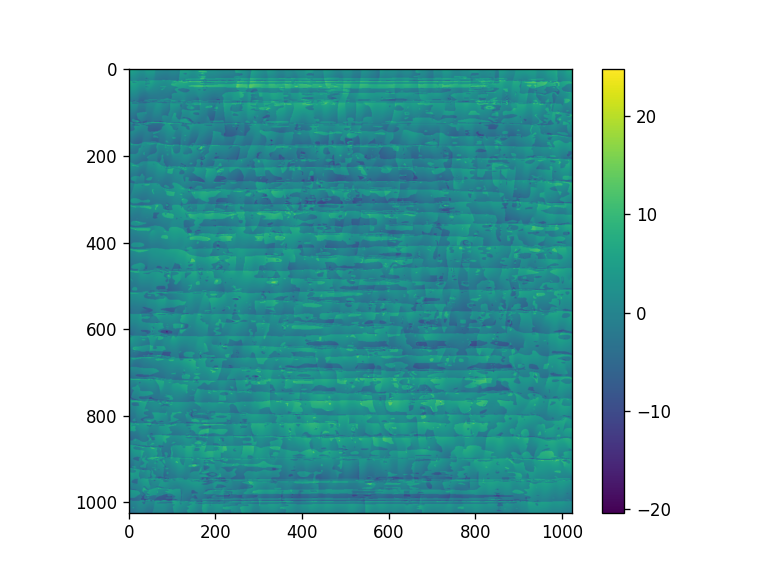

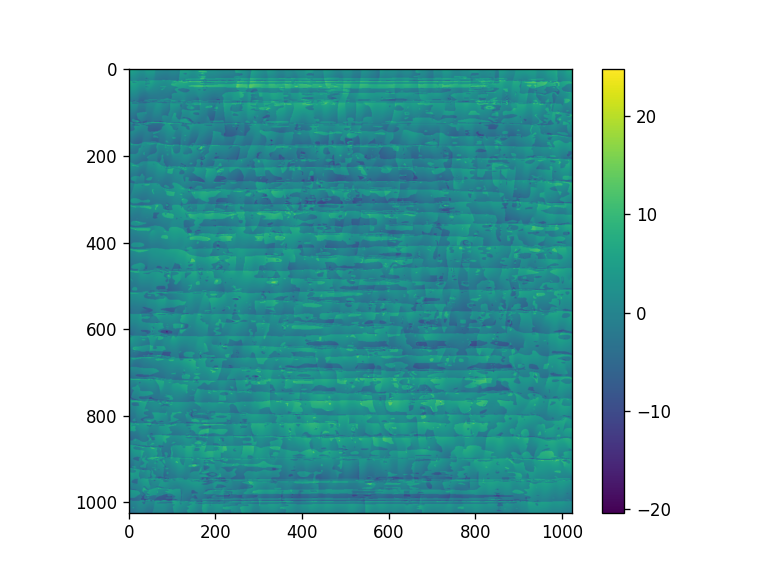

In [12]:
solution = moe.optimizer.optimize(FOM3, x0= xvalues.flatten(), args1=[mask2, screen, wavelength, matrix], verbose = 1, ftol=1e-14,xtol=None, optimizer_method='dogbox' )


x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.702005
Elapsed: 0:00:00.591871


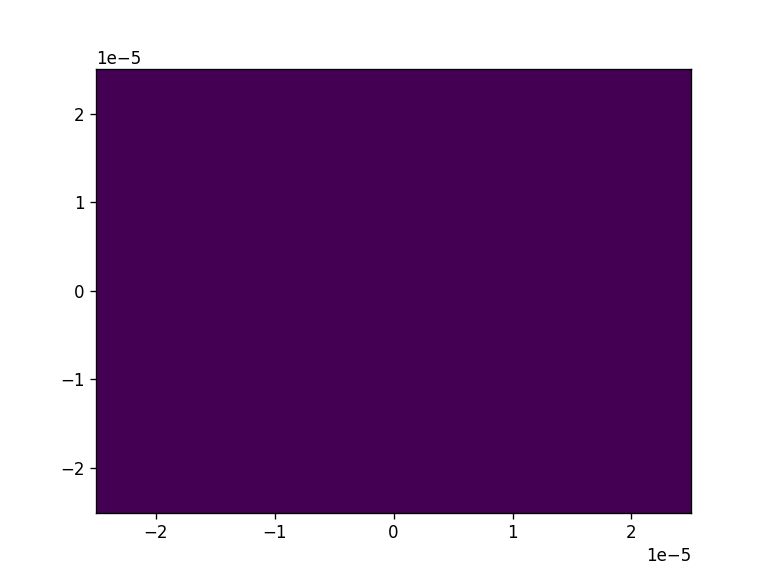

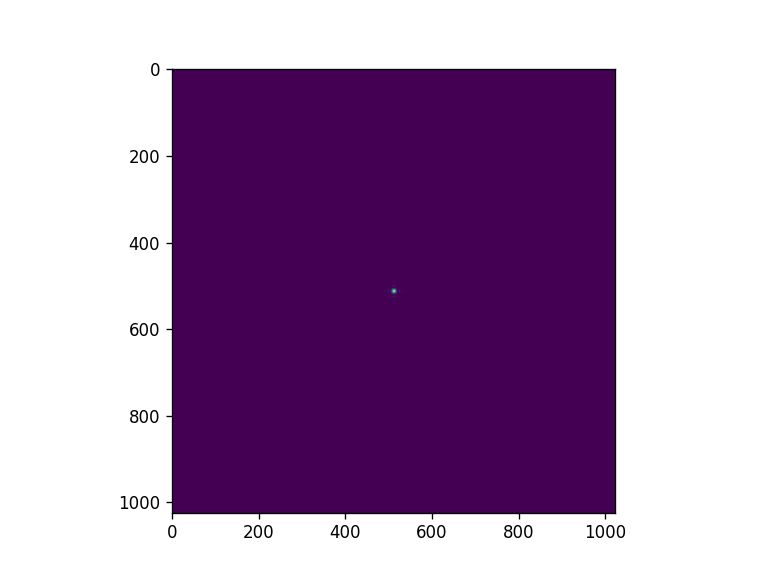

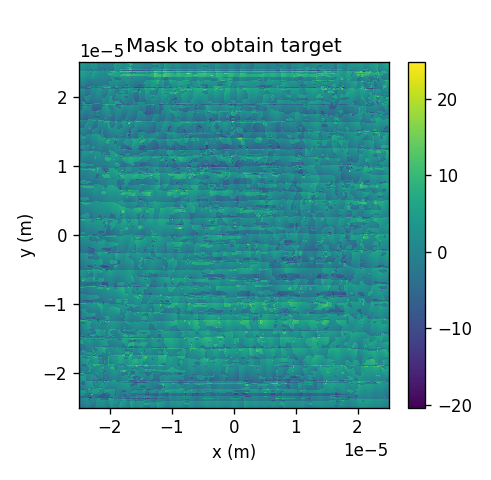

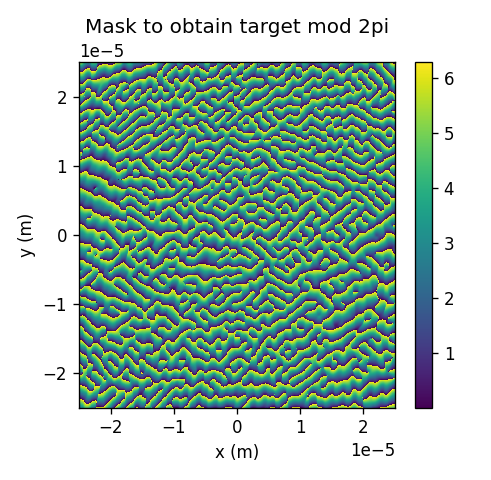

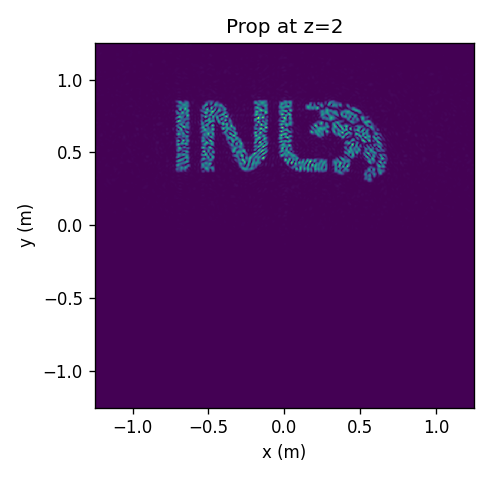

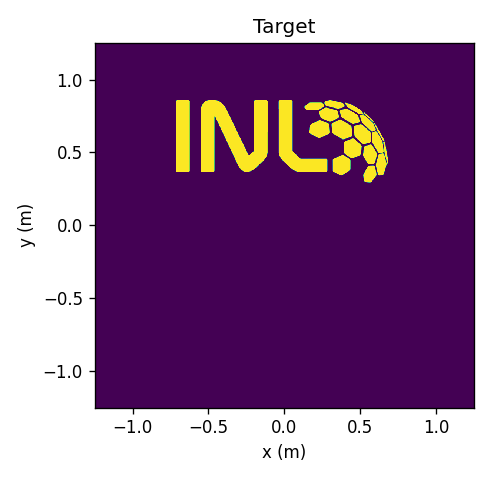

In [13]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
#plt.imshow(xar2) 
plt.pcolormesh(mask2.x, mask2.y, xar2)

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) )**2 )


fig = plt.figure(figsize=(4.1,4)) 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.pcolormesh(mask2.x, mask2.y, np.flip(np.flip(xar3), axis=1)) 
plt.title("Mask to obtain target")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.tight_layout()




fig = plt.figure(figsize=(4.1,4)) 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.pcolormesh(mask2.x, mask2.y, np.flip(np.flip(xar3)%(2*np.pi), axis=1)) 
plt.title("Mask to obtain target mod 2pi")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.tight_layout()



fig = plt.figure(figsize=(4.1,4)) 
plt.pcolormesh(screen.x, screen.y, np.flip(np.flip(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength) )**2 ) , axis=1))
plt.title("Prop at z="+str(screen.z[-1]))
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()

fig = plt.figure(figsize=(4.1,4)) 
plt.pcolormesh(screen.x,screen.y, np.flip(np.flip(np.reshape(matrix, (x_pixel, y_pixel)) ) ,axis =1))
plt.title("Target")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()

# Now we introduce several possible metrics 

In [155]:
# These metrics could be used to build specific loss functions 

In [156]:
#size of the rectangular mask 
aperture_width  = 50e-6 #m
aperture_height = 50e-6

pixsize = 1e-6 #m

wavelength = 500e-9 #m
focal_length = 200e-6

zmin = wavelength
zmax = 1.2* focal_length
nzs = 500

radius = aperture_width/2 

# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask1 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

#moe.plotting.plot_aperture(mask1)


##############
###Fresnel mask with a truncated circular aperture 

# Create empty mask
aperture2 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)


# and truncate around radius
mask2 = moe.generate.fresnel_phase(aperture2, focal_length, wavelength, radius=radius)
#moe.plotting.plot_aperture(mask2)

# Discretize mask in number of levels
# Select exact position of contours  in phase
phase_vals = np.linspace(-np.pi, np.pi, 16)

mask2.discretize(np.array( phase_vals)[:] ) 
#moe.plotting.plot_aperture(mask2)

# Generate a uniform field
field = moe.field.create_empty_field_from_aperture(mask2)

field = moe.field.generate_uniform_field(field, E0=1)

# Modulates the field 
field = moe.field.modulate_field(field, amplitude_mask=None, phase_mask=mask2 )


# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask2 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

Elapsed: 0:00:01.205280


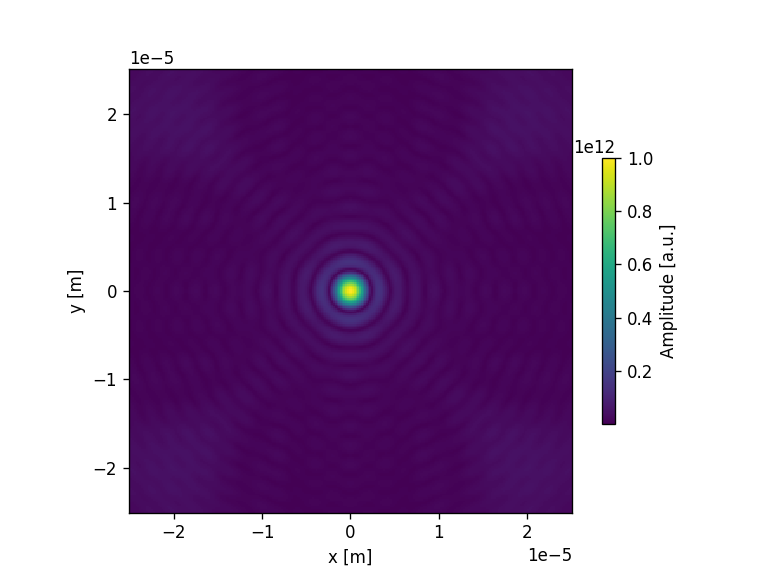

In [157]:
###Propagate field *10and calculate in plane YZ, using npix bins in Y
zmin = wavelength*10
zmax = 1.2* focal_length
nzs = 25

# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

x_pixel, y_pixel = 256, 256

x = np.linspace(xmin, xmax, x_pixel )
y = np.linspace(ymin, ymax, y_pixel )
z = np.linspace(zmin, zmax, nzs)


screen = moe.field.Screen(x,y,z)
sfreq = moe.metrics.spatial_freq_space(screen)
# Propagate the field 
EXYZ = moe.propagate.Bluestein(field, screen, wavelength)

Exy = moe.field.Screen(x,y,z)
Exy.screen = np.reshape(EXYZ.screen[:,:, int(focal_length/zmax*nzs)], (x_pixel,y_pixel,1))

moe.plotting.plot_screen_XY(Exy, which='amplitude')

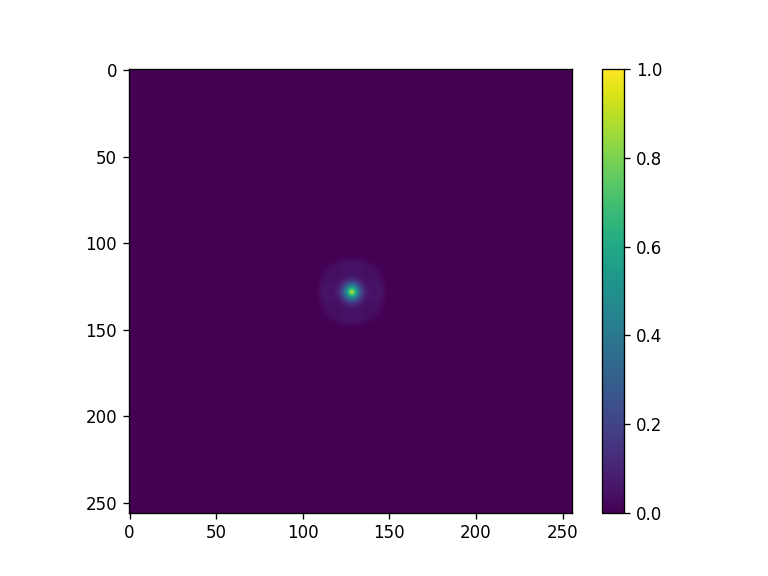

In [158]:
intensity = np.abs(screen.screen[:,:,-1])**2
#intensity = np.abs(Escreen)**2
norm_intensity = intensity/np.max(intensity)  # normalize intensity, not field

otf = sfft.fftshift(sfft.fft2(sfft.ifftshift(norm_intensity)))

center = (otf.shape[0] // 2, otf.shape[1] // 2)
otf_norm =  otf/np.abs(otf[center])


fig = plt.figure() 

plt.imshow( np.abs(otf_norm) )
plt.colorbar()

plt.show()

fig.savefig("OTF.png")



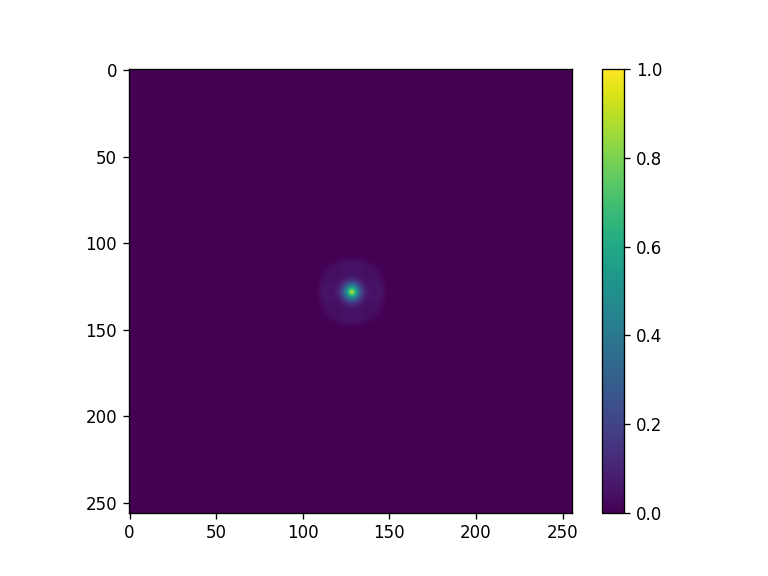

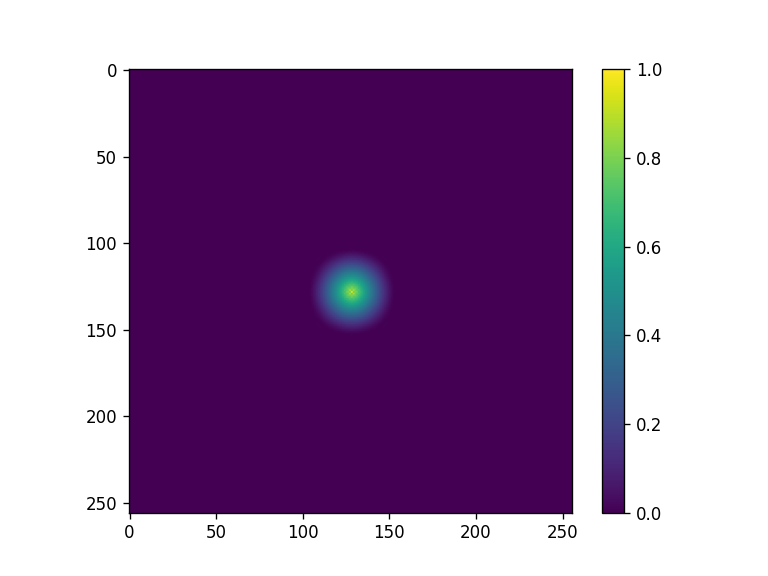

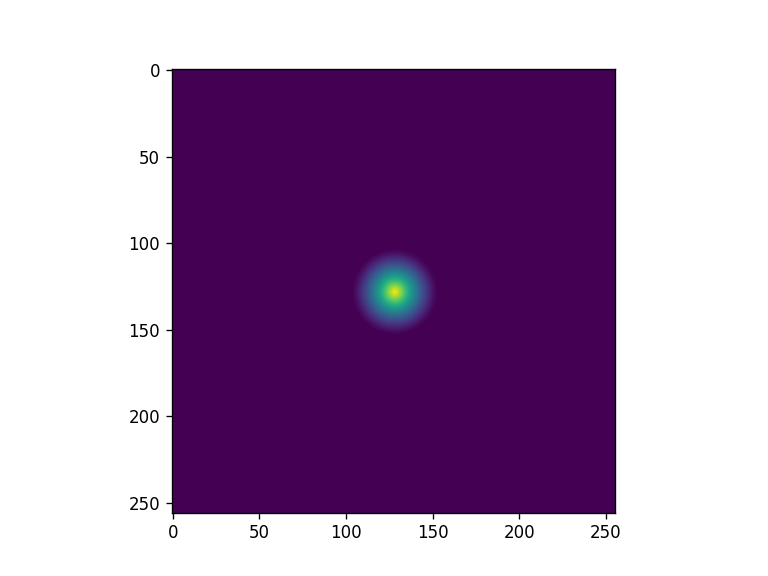

In [159]:
#Calculate the OTF out of focus and in focus 
import scipy.fftpack as sfft

o1 = moe.metrics.calculate_OTF(np.abs(screen.screen[:,:,-1])**2 , plot_OTF=True);
o2 = moe.metrics.calculate_OTF(np.abs(Exy.screen[:,:,-1])**2  , plot_OTF=True);

D = np.max(Exy.x)*2
OTF_ideal = moe.metrics.theoretical_ideal_OTF(Exy, D, wavelength, focal_length)

fig = plt.figure()
plt.imshow( OTF_ideal)

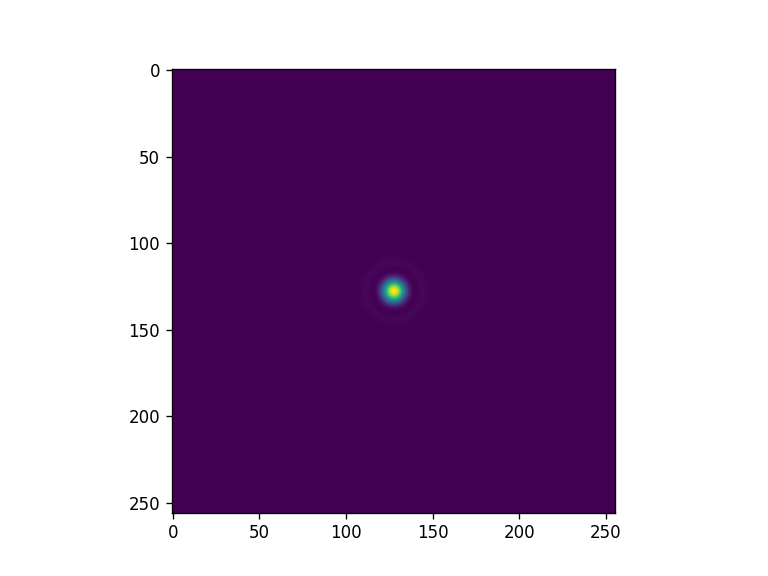

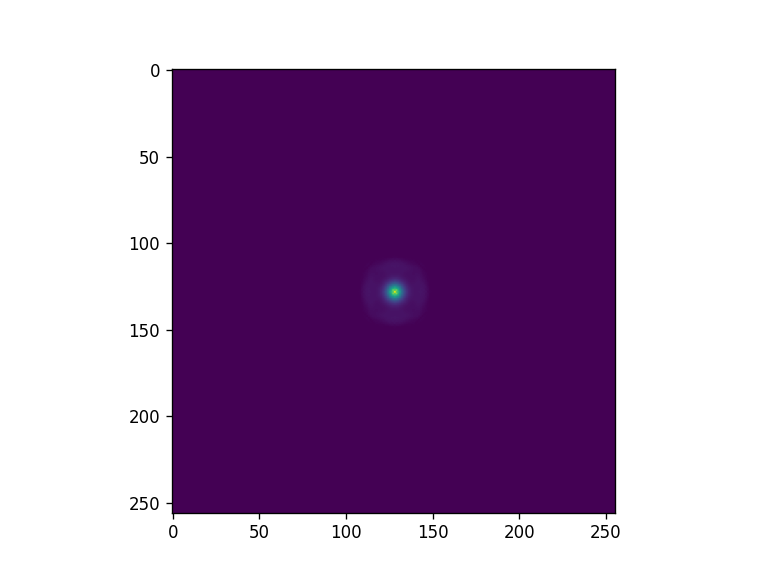

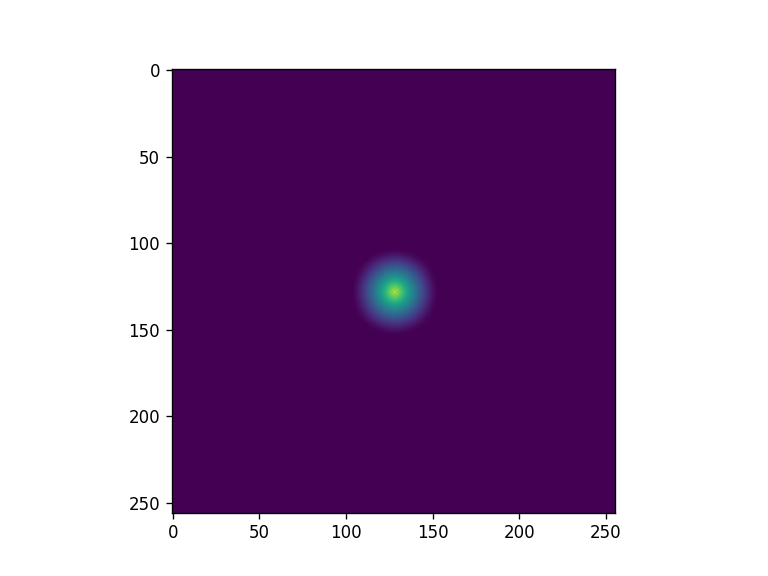

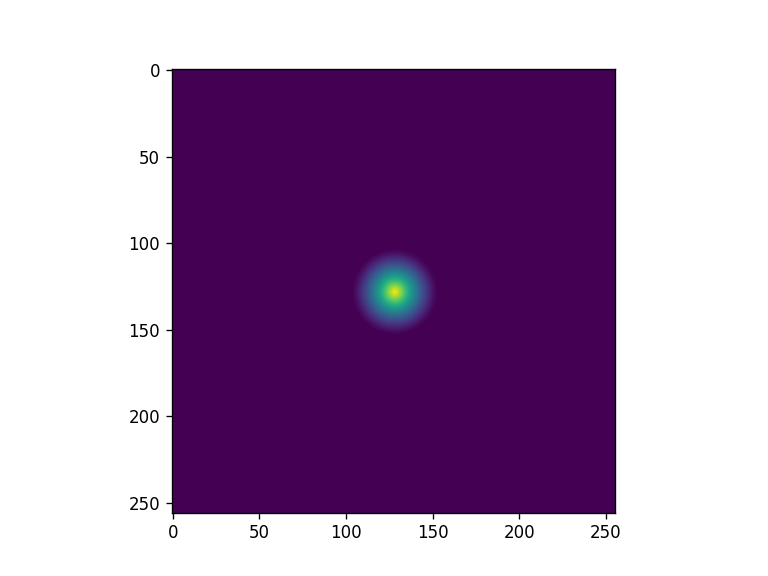

In [160]:
plt.figure() 

plt.imshow(np.abs(Exy.screen)**2) 

plt.figure()

plt.imshow(np.abs(o1) )

plt.figure()

plt.imshow(np.abs(o2) )

plt.figure()
plt.imshow(np.abs(OTF_ideal) )

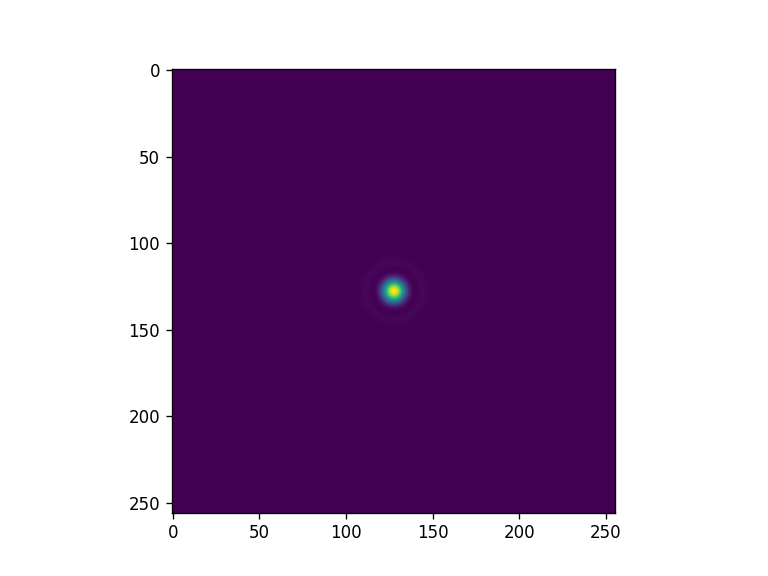

In [161]:
max([max(Exy.x), max(Exy.y)])
Exy.z[0]


fig = plt.figure() 
plt.imshow(np.abs(Exy.screen)**2)

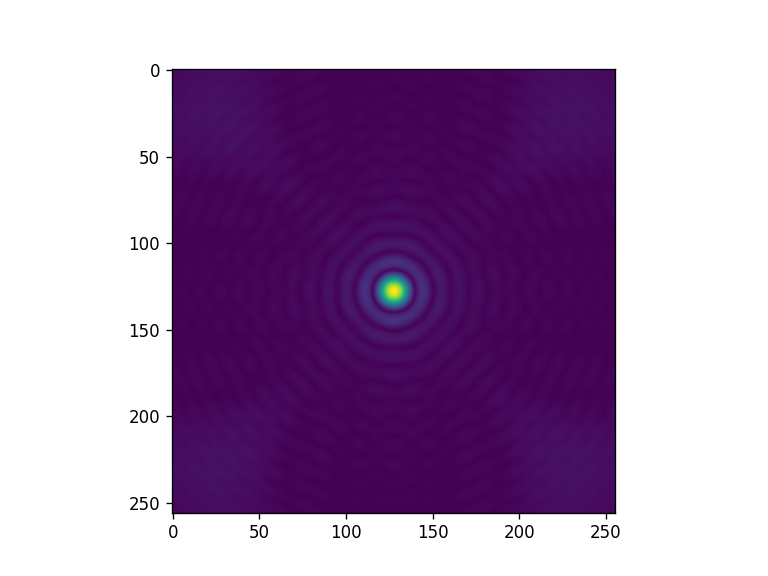

In [162]:
fig= plt.figure() 
plt.imshow(np.abs(Exy.screen) )

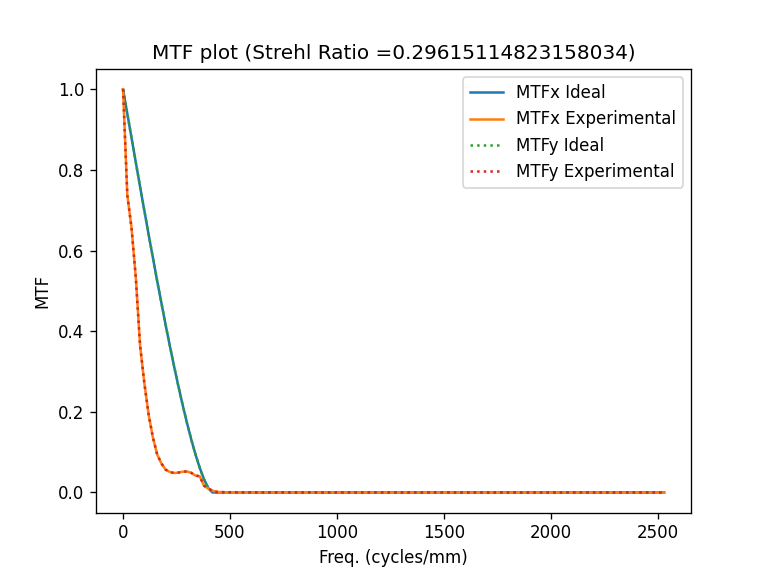

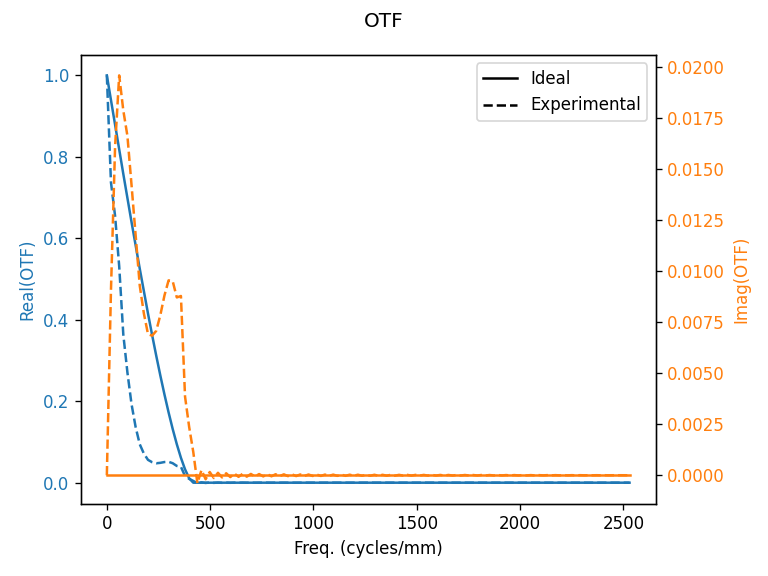

In [163]:
# MTF and OTF at DEFOCUSED PLANE 

strehlv1 = moe.metrics.strehl_ratio(np.abs(screen.screen[:,:,-1] )**2, screen, max([max(Exy.x), max(Exy.y)])*2, wavelength, screen.z[-1], strehl_from_mtf=True, plot_MTF=True, plot_OTF=True) 


(np.float64(0.29615114823158034), np.float64(0.9011953763298147))

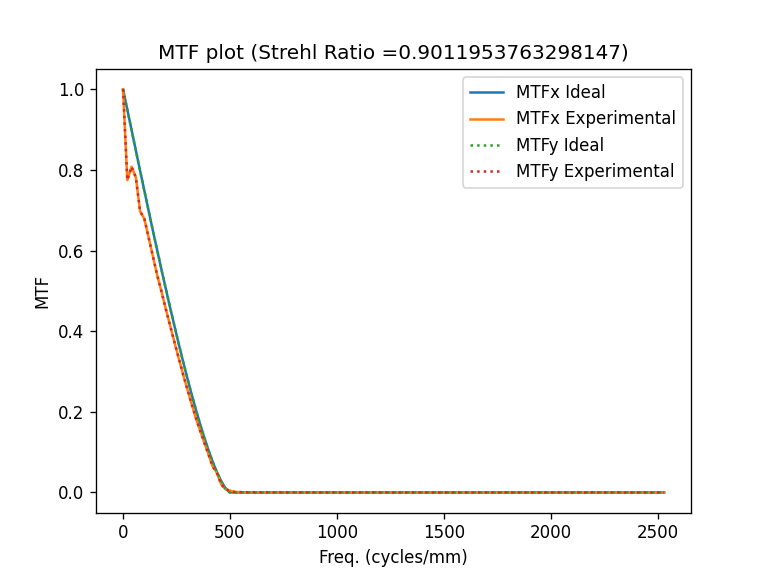

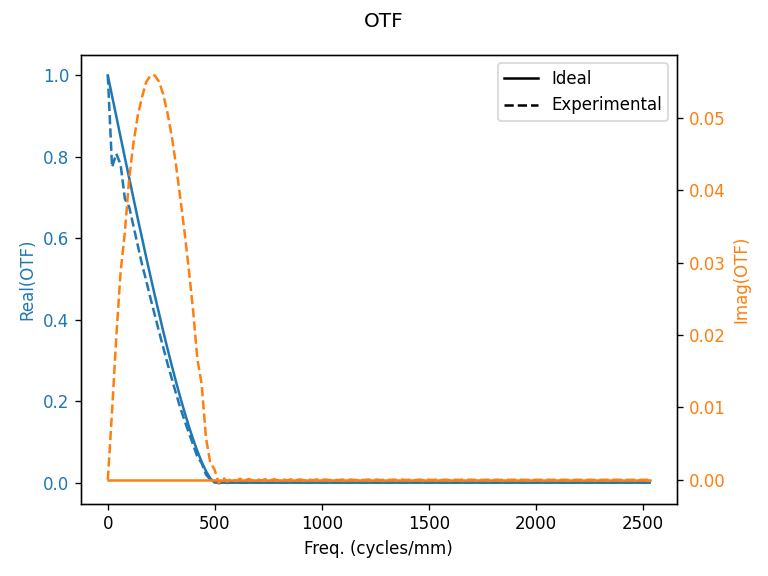

In [164]:
# MTF and OTF at FOCUSED PLANE

strehlv2 = moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,-1] )**2, Exy, max([max(Exy.x), max(Exy.y)])*2, wavelength, focal_length, strehl_from_mtf=True, plot_MTF=True, plot_OTF=True )

strehlv1, strehlv2

(np.float64(0.8879606630471453), np.float64(0.8879606630471453))

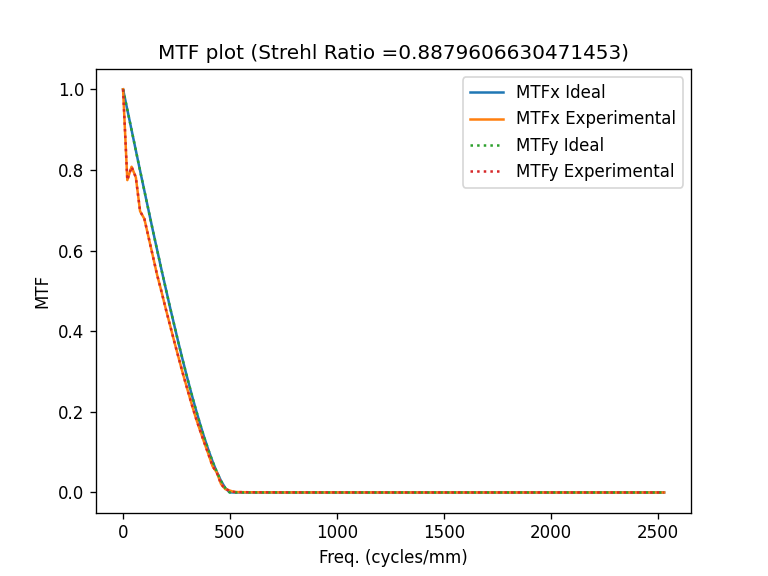

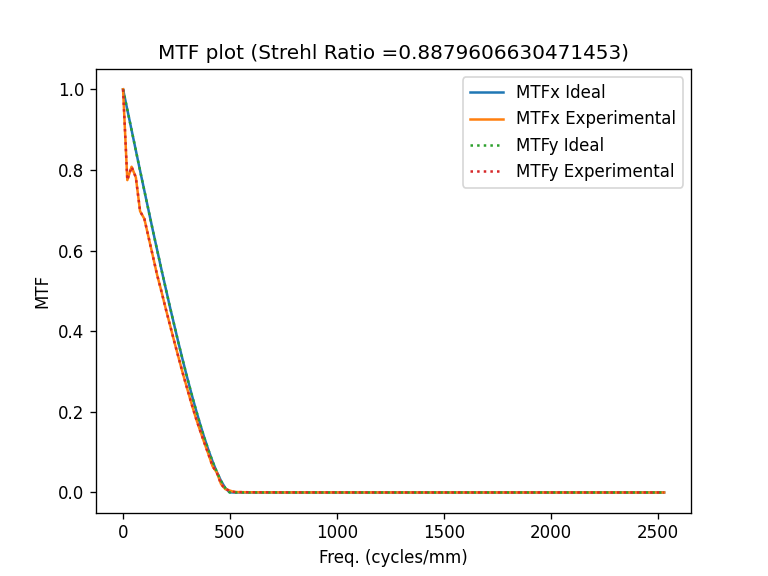

In [165]:
moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,-1])**2, screen, max([max(screen.x), max(screen.y)])*2, wavelength, focal_length, plot_MTF=True) ,\
moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,-1])**2, Exy, max([max(Exy.x), max(Exy.y)])*2, wavelength, focal_length, plot_MTF=True) 


Text(0.5, 1.0, 'Encircled energy')

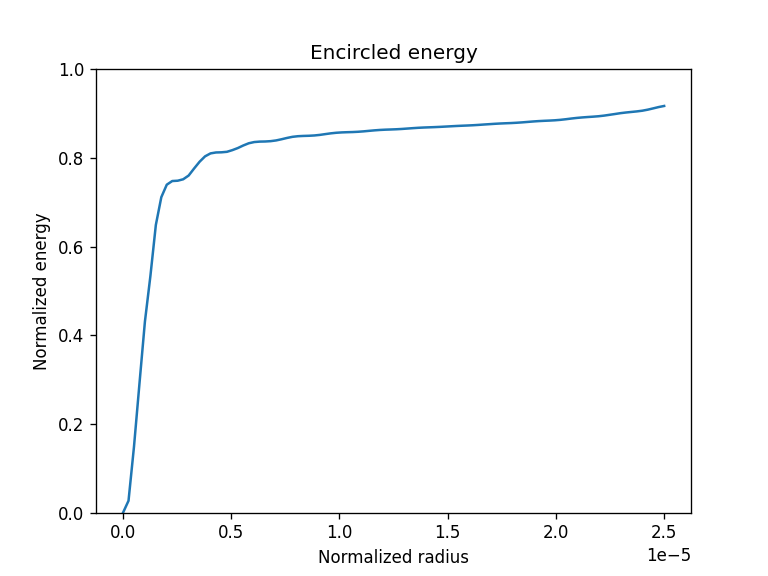

In [166]:
center=(0,0)

parray = np.linspace(0, aperture_width/2, 100)

enarray = [moe.metrics.encircled_energy(Exy, p) for p in parray]
enmax = moe.metrics.encircled_energy(Exy, 1.01)

fig = plt.figure() 

plt.plot(parray, enarray/enmax)
plt.ylim([0,1])
plt.xlabel("Normalized radius")
plt.ylabel("Normalized energy")
plt.title("Encircled energy")
#plt.yscale("log")

#This is not exactly one, because other energy is lost to the square parts of the sensor 


#The energy plateus at 0.5e-6, so makes sense to use that as p 

In [167]:
XY=np.abs(Exy.screen[:,:,-1])**2


largestpeak_height , largestpeak_width, position = moe.metrics.find_FWHM_2d(XY, prominence=0.5)

largestpeak_height , largestpeak_width, position

(np.float64(1.0007365335316455e+23),
 np.float64(17.734210609893083),
 array([127, 127]))

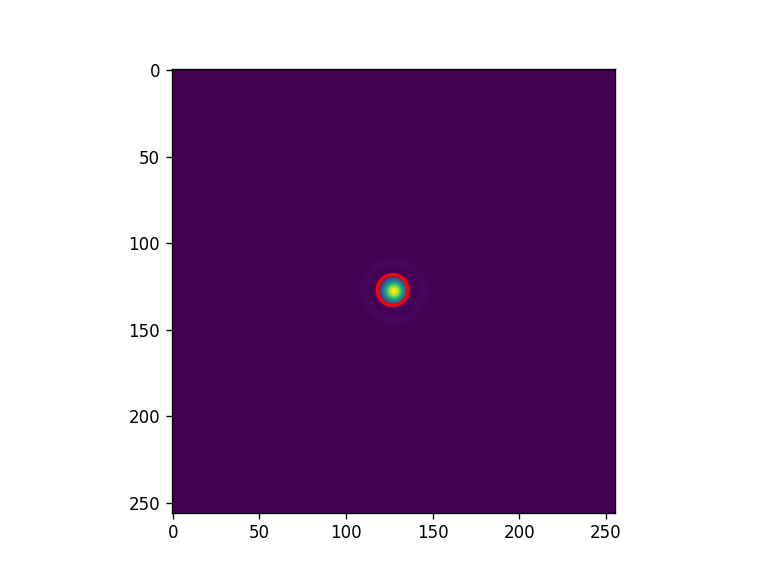

In [168]:
from matplotlib.patches import Circle 

fig = plt.figure() 

plt.imshow(np.abs(XY))

# Get image dimensions
height, width = XY.shape

# Add central circle
circle = Circle((position[0], position[1]), radius=largestpeak_width/2, color='red', fill=False, linewidth=2)
plt.gca().add_patch(circle)

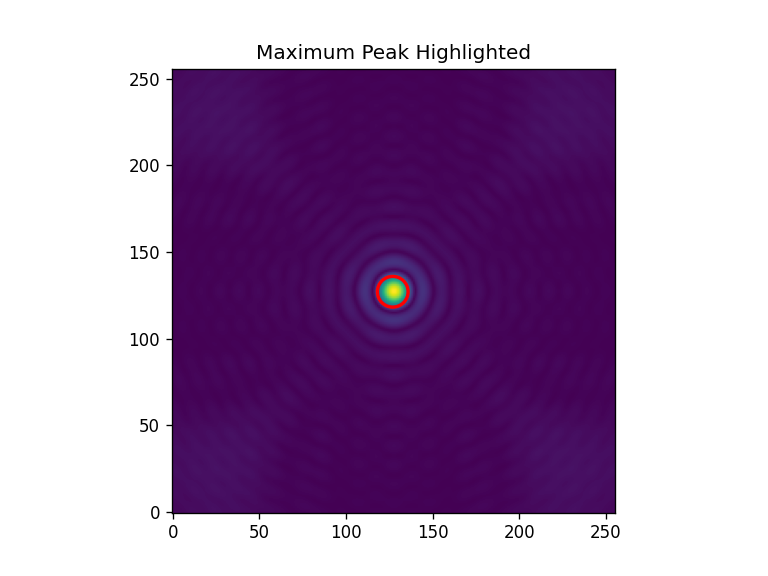

In [169]:
largestpeak_height , largestpeak_width, largestpeak_position = moe.metrics.find_FWHM_2d(np.abs(Exy.screen[:,:,-1])**2, prominence=0.5)


from matplotlib.patches import Circle

fig, ax = plt.subplots()
ax.imshow(np.abs(Exy.screen[:,:,-1]),  origin='lower')

# Draw the circle
circle = Circle((largestpeak_position[0], largestpeak_position[1]),  # x, y
                radius=largestpeak_width/2, color='red', fill=False, linewidth=2)
ax.add_patch(circle)

# Optional: mark the center
#ax.plot(largestpeak_position[0], largestpeak_position[1], 'ro')  # center dot

plt.title("Maximum Peak Highlighted")
plt.show()

In [170]:
##encircled energy at 1 FWHM 

one_fwhm = moe.metrics.encircled_energy(Exy, (width/2)*pixsize)/moe.metrics.encircled_energy(Exy, 1.01)

##encircled energy at 0.5 FWHM 

half_fwhm = moe.metrics.encircled_energy(Exy, (width/2)*pixsize*0.5)/moe.metrics.encircled_energy(Exy, 1.01)


(width/2)*pixsize, one_fwhm, half_fwhm 
#This is consistent with the plateauing that is seen in the encircled energy 

(0.000128, np.float64(1.0), np.float64(1.0))

Text(0.5, 1.0, 'Focusing Efficiency')

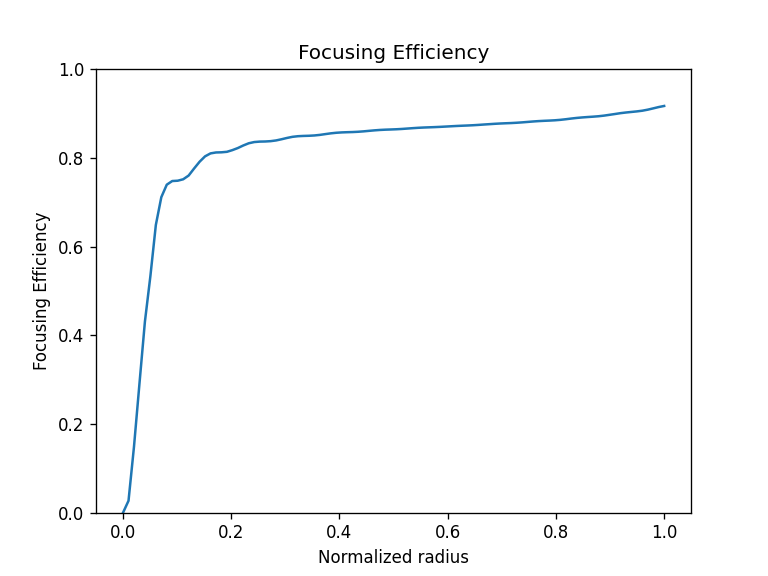

In [171]:
center=(0,0)

parray = np.linspace(0, aperture_width/2, 100)

#Should give the same as the enclircled energy 
farray1 = [moe.metrics.focus_efficiency(Exy, p,  encircled_energy(Exy, 1.01),center=(0,0),) for p in parray]

fig = plt.figure() 

plt.plot(parray/(aperture_width/2), farray1)
plt.ylim([0,1])
plt.xlabel("Normalized radius")
plt.ylabel("Focusing Efficiency")
plt.title("Focusing Efficiency")
#plt.yscale("log")


Text(0.5, 1.0, 'Engelberg OPM')

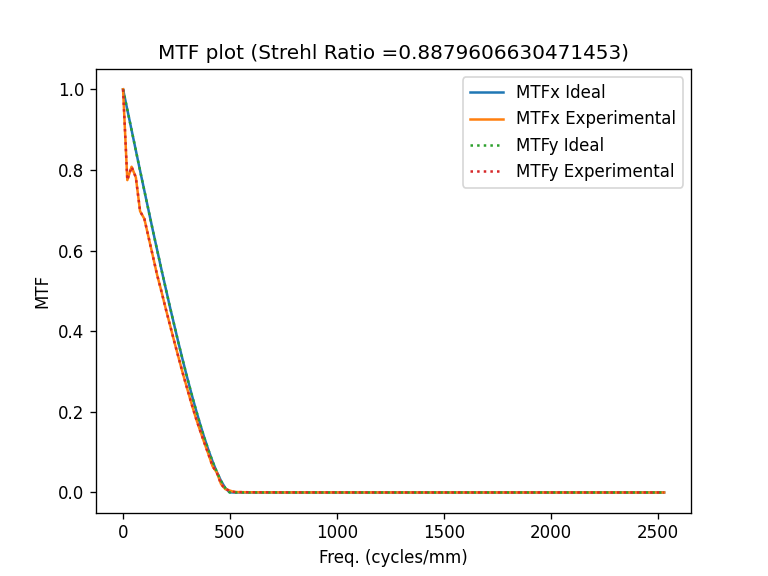

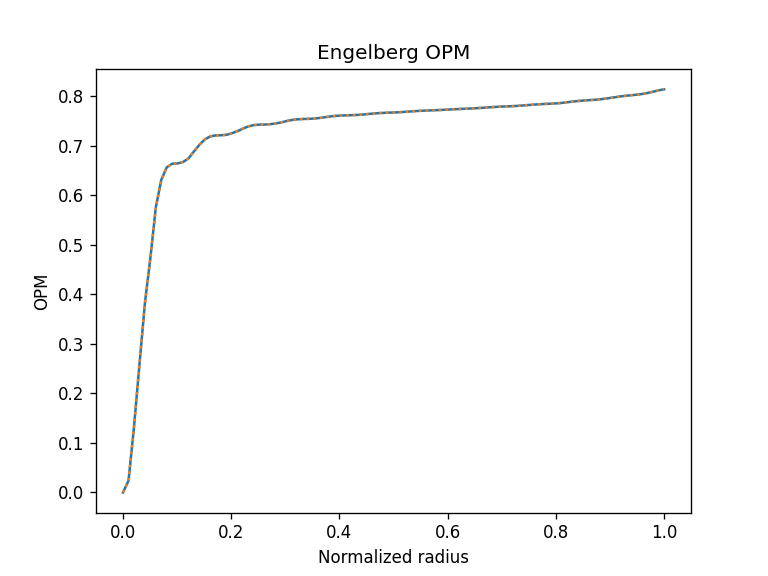

In [172]:
#Engelberg metric, check original paper for more detail 

center=(0,0)

parray = np.linspace(0, aperture_width/2, 100)

farray2 = [moe.metrics.Engelberg_OPM(Exy, p,  moe.metrics.encircled_energy(Exy, 1.01),1, wavelength, z = focal_length) for p in parray]
strehlr = moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,-1])**2, Exy, max([max(Exy.x), max(Exy.y)])*2, wavelength, focal_length, plot_MTF=True) 

fig = plt.figure() 

plt.plot(parray/(aperture_width/2), farray2)
plt.plot(parray/(aperture_width/2), strehlr*np.array(farray1), ':' )
#plt.ylim([0,1])
plt.xlabel("Normalized radius")
plt.ylabel("OPM")
plt.title("Engelberg OPM")



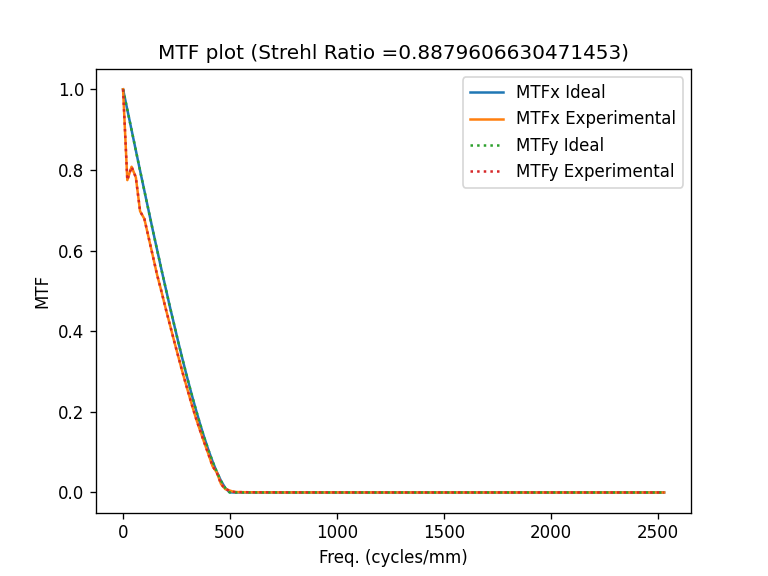

In [173]:
strehlr = moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,0])**2, screen, max([max(Exy.x), max(Exy.y)])*2, wavelength, focal_length, plot_MTF=True) 

Text(0.5, 1.0, 'Ensquared energy')

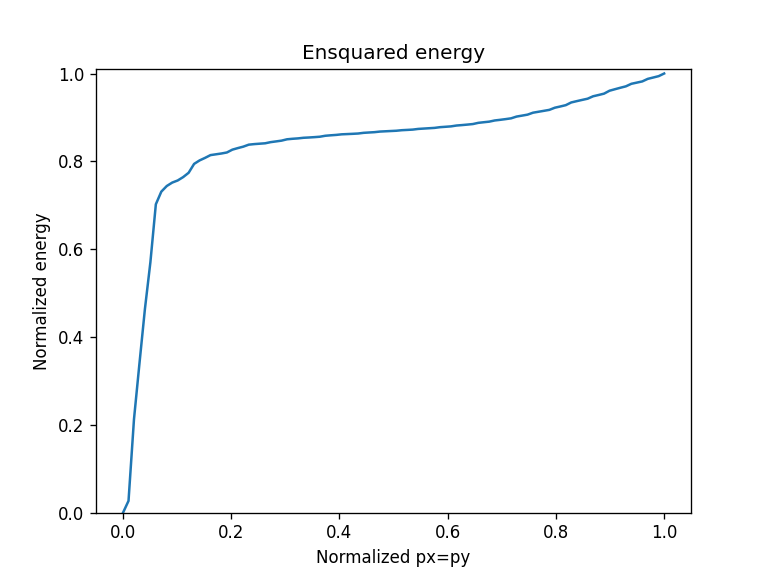

In [174]:
center=(0,0)

parray = np.linspace(0, aperture_width/2, 100)

enarray = [moe.metrics.ensquared_energy(Exy, p, p) for p in parray]
enmax = moe.metrics.ensquared_energy(Exy, 1,1)

fig = plt.figure() 

plt.plot(parray/(aperture_width/2), enarray/enmax)
plt.ylim([0,1.01])
plt.xlabel("Normalized px=py")
plt.ylabel("Normalized energy")
plt.title("Ensquared energy")

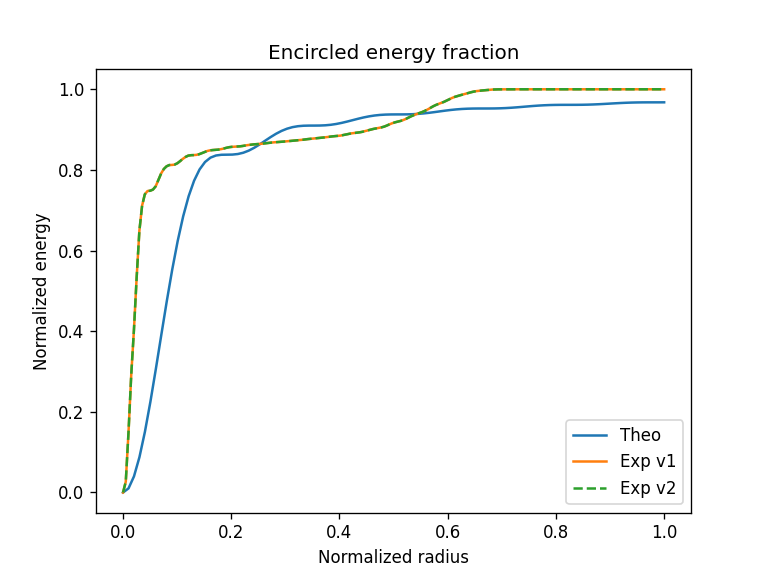

In [187]:
## RESULT TO BE CHECKED, MISMATCH MAYBE DUE TO DISTINCT DEFINITION OF RADIUS p ??

center=(0,0)

parray1 = np.linspace(0, aperture_width, 200)

enarray = [moe.metrics.encircled_energy(Exy, p) for p in parray1]
enmax = moe.metrics.encircled_energy(Exy, 1.01)


parray2 = np.linspace(0, aperture_width*10, 100)
enarray_theo = [moe.metrics.theoretical_encircled_energy(Exy, p) for p in parray2]
enmaxtheo = moe.metrics.theoretical_encircled_energy(Exy, 1.01)


enarray2 = [moe.metrics.encircled_energy(Exy, p) for p in parray1]
enmax2 = moe.metrics.encircled_energy(Exy, 1.01)


fig = plt.figure() 

plt.plot(parray2/parray2.max(), enarray_theo/enmaxtheo, label="Theo")
plt.plot(parray1/parray1.max(), enarray/enmax, label = "Exp v1")

plt.plot(parray1/parray1.max(), enarray2/enmax2 , '--', label ="Exp v2")

plt.xlabel("Normalized radius")
plt.ylabel("Normalized energy")
plt.title("Encircled energy fraction")

plt.legend()

#This is not exactly one, because other energy is lost to the square parts of the sensor 


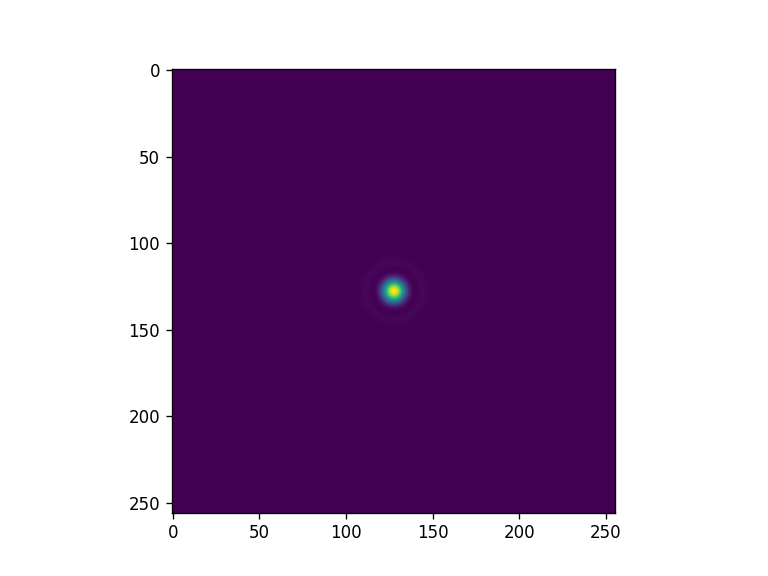

In [176]:
fig = plt.figure()
plt.imshow(np.abs(Exy.screen[:,:,-1])**2)

Picking up the last z propagated assumed to be the screen position


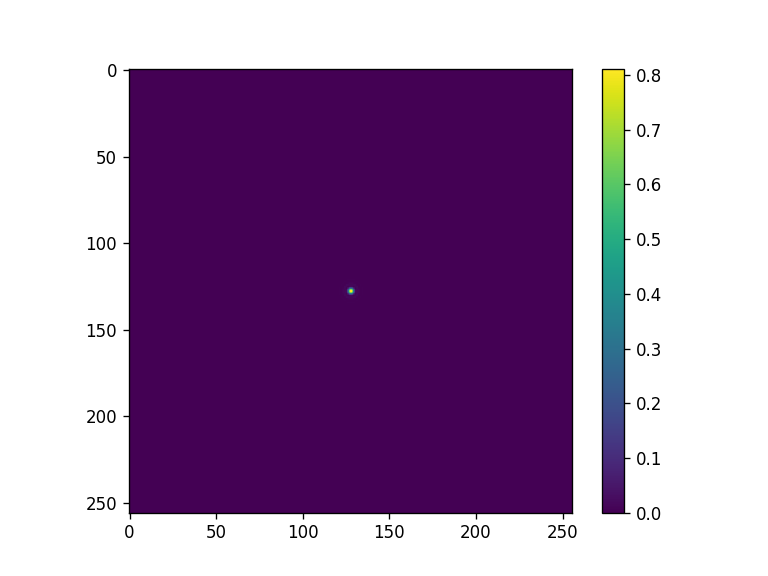

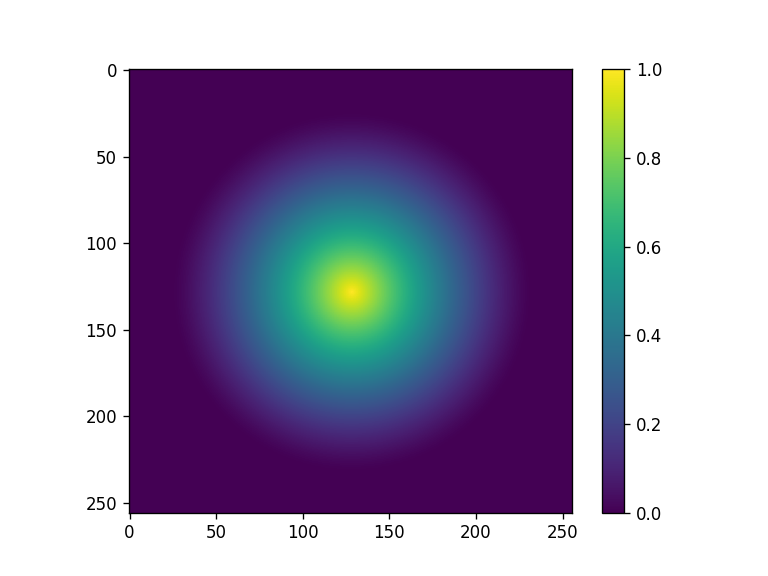

<Figure size 768x576 with 0 Axes>

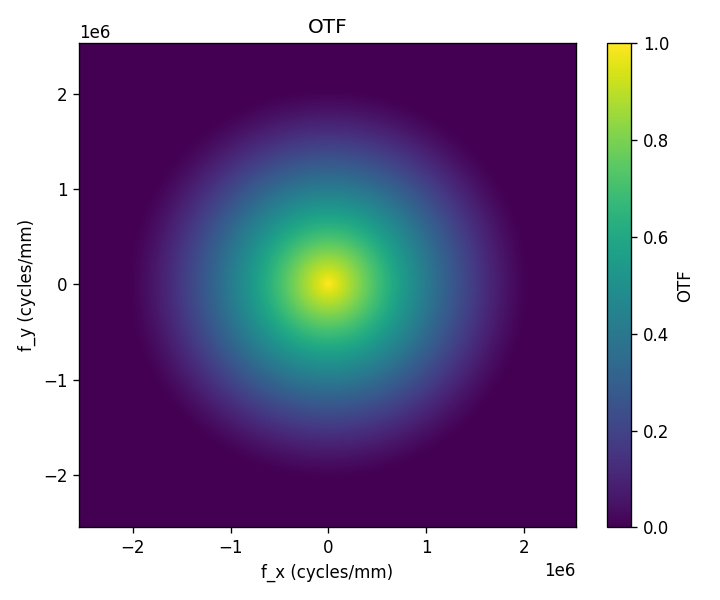

In [177]:
#Sanity check with theoretical Airy pattern MTF, 
# here the theoretical and calculated MTFs should give the same with unitary Strehl ratio

D = np.max(Exy.x)*2        

wavelength = 200e-9  # Wavelength in meters (e.g., 550 nm)

intensity_circular = intensity_theo_Airy(screen, D*2, wavelength, z=1)


fig = plt.figure() 
plt.imshow(intensity_circular  )
plt.colorbar()

OTF_circular = calculate_OTF(intensity_circular)


fig = plt.figure()
plt.imshow(np.abs(OTF_circular) )
plt.colorbar()

fig = plt.figure()

N = 512
dx = 10e-6  # pixel pitch in meters
dy = 10e-6


# Plot
plt.figure(figsize=(6, 5))
plt.imshow(np.abs(OTF_circular), extent=(np.min(Exy.fx), np.max(Exy.fx), np.min(Exy.fy), np.max(Exy.fy)),
           origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='OTF')
plt.xlabel('f_x (cycles/mm)')
plt.ylabel('f_y (cycles/mm)')
plt.title('OTF')
plt.tight_layout()
plt.show()

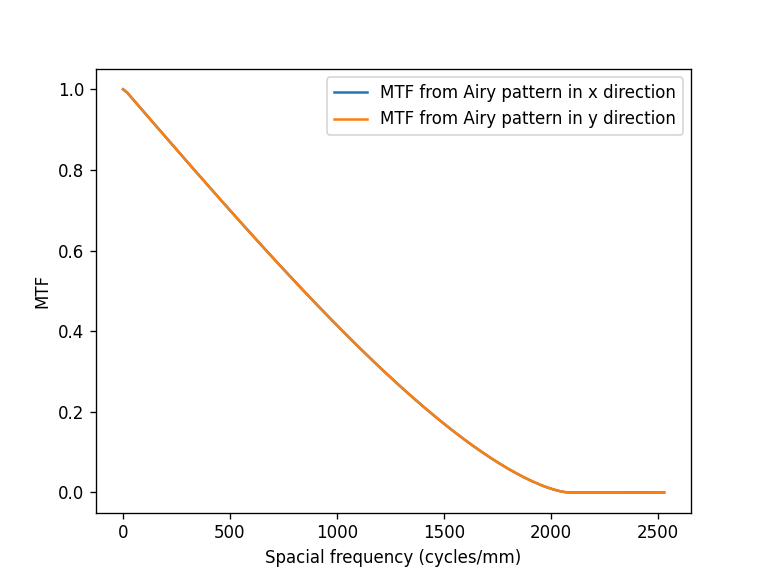

In [178]:
mtf, mtfx1, mtfy1 = moe.metrics.MTF_from_OTF(OTF_circular)


fx, fy = screen.fx*1e-3, screen.fy *1e-3

fig = plt.figure() 
plt.plot(fx[np.where(fx>=0)],  mtfx1, label="MTF from Airy pattern in x direction")
plt.plot(fy[np.where(fy>=0)],  mtfy1, label="MTF from Airy pattern in y direction")
plt.xlabel("Spacial frequency (cycles/mm)")
plt.ylabel("MTF")

plt.legend()


In [179]:


otf = moe.metrics.theoretical_ideal_OTF(screen, D*2, wavelength, screen.z[-1]) 

mtf, mtfx2, mtfy2 = moe.metrics.MTF_from_OTF(otf)

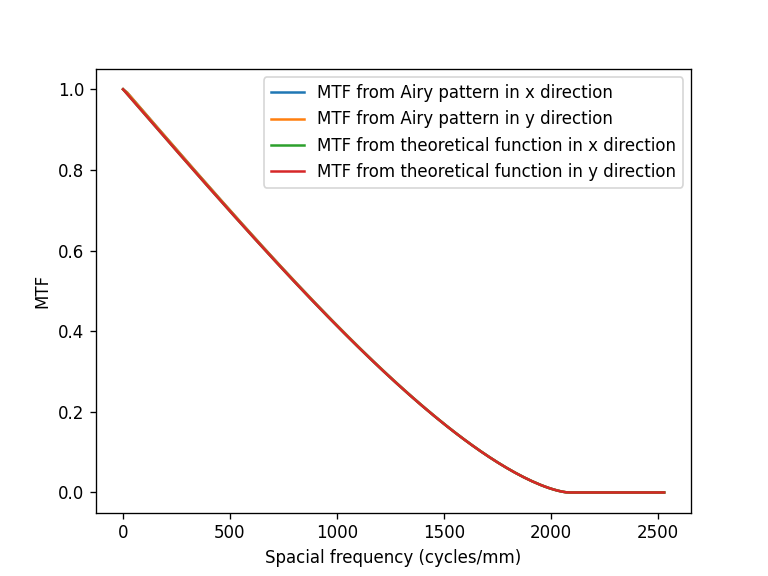

In [180]:
fx = screen.fx*1e-3
fy = screen.fy*1e-3

fig = plt.figure() 
plt.plot(fx[np.where(fx>=0)],  mtfx1, label="MTF from Airy pattern in x direction")
plt.plot(fy[np.where(fy>=0)],  mtfy1, label="MTF from Airy pattern in y direction")
plt.plot(fx[np.where(fx>=0)],  mtfx2, label="MTF from theoretical function in x direction")
plt.plot(fy[np.where(fy>=0)],  mtfy2, label="MTF from theoretical function in y direction")
plt.xlabel("Spacial frequency (cycles/mm)")
plt.ylabel("MTF")

plt.legend()

In [181]:
#This should give 1 

moe.metrics.strehl_ratio(intensity_circular, screen, D*2, wavelength, z = screen.z[-1])

np.float64(0.8138093632949268)